Saving smart_grid_dataset.csv to smart_grid_dataset (2).csv
Dataset Loaded Successfully
Dataset shape          : (50000, 16)
Number of observations : 50,000
Number of variables    : 16

Timestamp range:
Start : 2024-01-01 00:00:00
End   : 2025-06-04 19:45:00

Timestamp monotonic    : True
Duplicate timestamps   : 0
Duplicate rows         : 0

Missing-value audit:
Timestamp                      0
Voltage (V)                    0
Current (A)                    0
Power Consumption (kW)         0
Reactive Power (kVAR)          0
Power Factor                   0
Solar Power (kW)               0
Wind Power (kW)                0
Grid Supply (kW)               0
Predicted Load (kW)            0
Voltage Fluctuation (%)        0
Temperature (°C)               0
Humidity (%)                   0
Electricity Price (USD/kWh)    0
Transformer Fault              0
Overload Condition             0
dtype: int64

✓ No missing values detected.

Target distribution:
Normal    :  45,000 (90.00%)
Overload  :

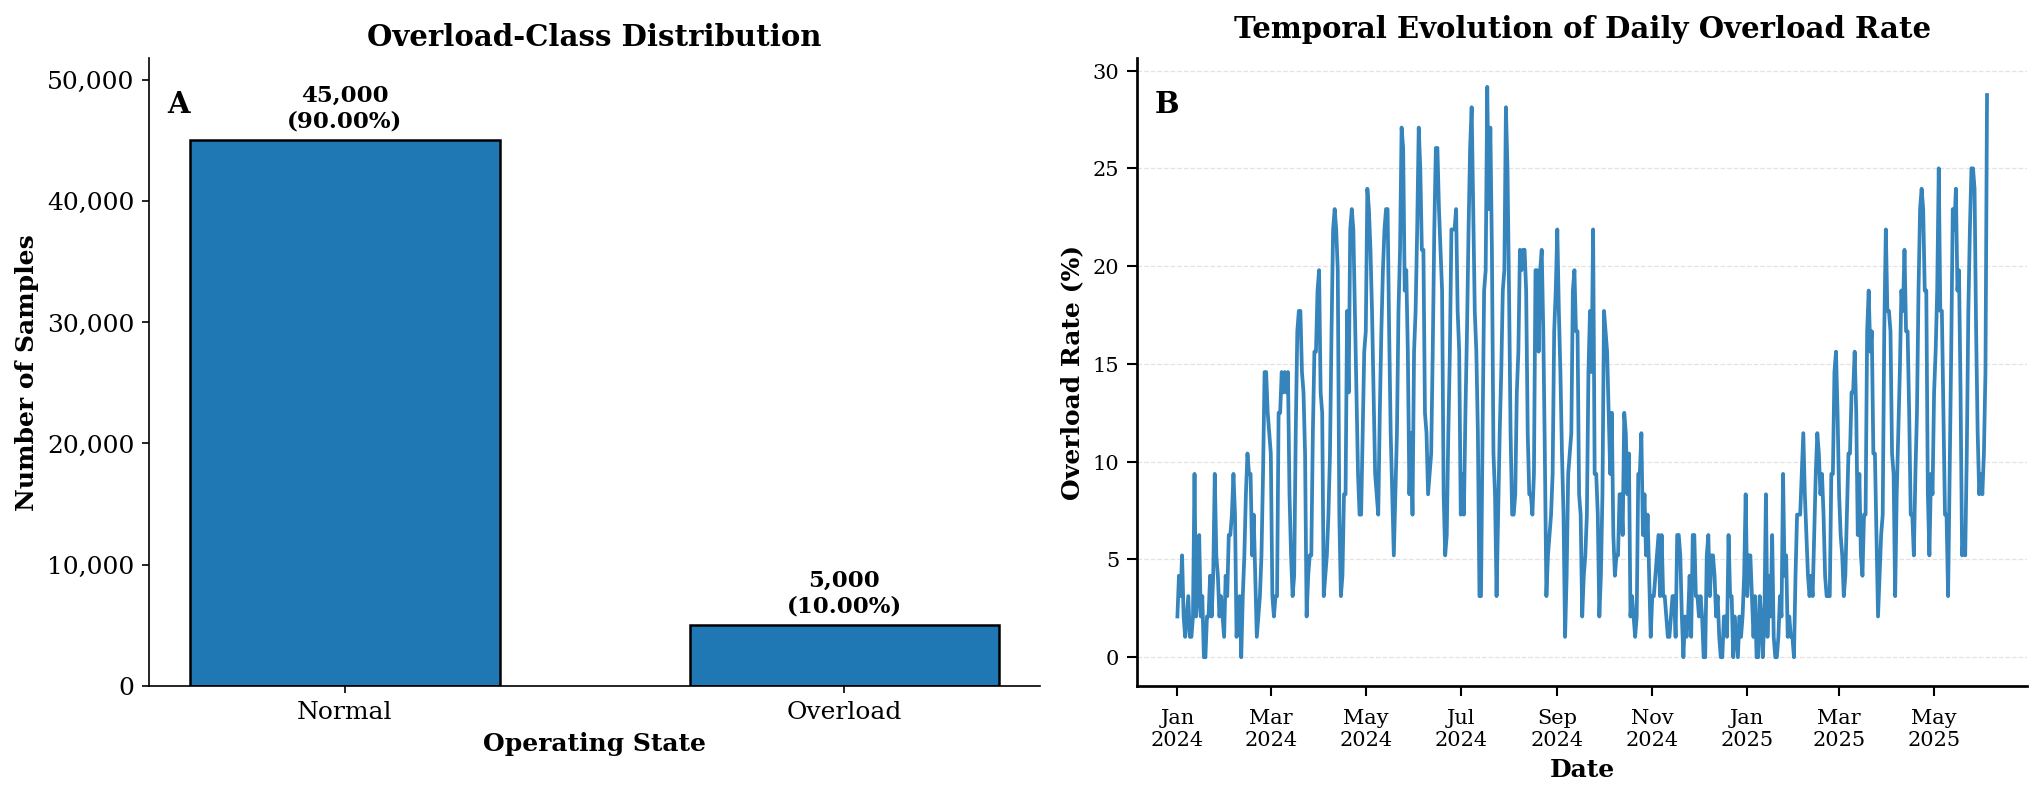


OUTPUT FILES
PNG : /content/smart_grid_outputs/Figure_1_Overload_Data_Profile.png
PDF : /content/smart_grid_outputs/Figure_1_Overload_Data_Profile.pdf


In [ ]:
# =============================================================================
# STEP 1: SMART GRID DATASET AUDIT + TARGET CHARACTERIZATION
# =============================================================================

from pathlib import Path
from typing import Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter


# =============================================================================
# CONFIGURATION
# =============================================================================

RANDOM_STATE = 42

DATA_PATH = Path("/content/smart_grid_dataset.csv")
OUTPUT_DIR = Path("/content/smart_grid_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# =============================================================================
# IEEE-STYLE FIGURE CONFIGURATION
# =============================================================================

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "axes.labelweight": "bold",
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 11,
    "legend.frameon": True,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


# =============================================================================
# LOAD DATA
# =============================================================================

from google.colab import files

uploaded = files.upload()

filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

print("="*60)
print("Dataset Loaded Successfully")
print("="*60)

print(f"Dataset shape          : {df.shape}")
print(f"Number of observations : {len(df):,}")
print(f"Number of variables    : {df.shape[1]}")


# =============================================================================
# TIMESTAMP PROCESSING
# =============================================================================

df["Timestamp"] = pd.to_datetime(df["Timestamp"], errors="coerce")

print("\nTimestamp range:")
print(f"Start : {df['Timestamp'].min()}")
print(f"End   : {df['Timestamp'].max()}")

print(f"\nTimestamp monotonic    : {df['Timestamp'].is_monotonic_increasing}")
print(f"Duplicate timestamps   : {df['Timestamp'].duplicated().sum()}")
print(f"Duplicate rows         : {df.duplicated().sum()}")


# =============================================================================
# MISSING-VALUE AUDIT
# =============================================================================

missing_values = df.isna().sum()

print("\nMissing-value audit:")
print(missing_values)

if missing_values.sum() == 0:
    print("\n✓ No missing values detected.")
else:
    print("\n⚠ Missing values detected.")


# =============================================================================
# TARGET ANALYSIS
# =============================================================================

TARGET = "Overload Condition"

class_counts = df[TARGET].value_counts().sort_index()
class_percent = (
    df[TARGET]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

print("\nTarget distribution:")
for cls in class_counts.index:
    label = "Normal" if cls == 0 else "Overload"
    print(
        f"{label:10s}: "
        f"{class_counts.loc[cls]:>7,} "
        f"({class_percent.loc[cls]:.2f}%)"
    )


# =============================================================================
# BASIC STATISTICS
# =============================================================================

numeric_columns = df.select_dtypes(
    include=[np.number]
).columns.tolist()

print("\nNumerical variables:")
for column in numeric_columns:
    print(f"  - {column}")


# =============================================================================
# HIGH-CORRELATION FEATURE PAIRS
# =============================================================================

feature_columns = [
    column
    for column in numeric_columns
    if column != TARGET
]

corr_matrix = df[feature_columns].corr()

high_corr_pairs = []

for i in range(len(feature_columns)):
    for j in range(i + 1, len(feature_columns)):
        correlation = corr_matrix.iloc[i, j]

        if abs(correlation) >= 0.90:
            high_corr_pairs.append(
                (
                    feature_columns[i],
                    feature_columns[j],
                    correlation,
                )
            )

high_corr_pairs = sorted(
    high_corr_pairs,
    key=lambda item: abs(item[2]),
    reverse=True,
)

print("\nHighly correlated feature pairs |r| >= 0.90:")
for feature_a, feature_b, correlation in high_corr_pairs:
    print(
        f"{feature_a}  <-->  {feature_b} : "
        f"{correlation:.4f}"
    )


# =============================================================================
# TEMPORAL OVERLOAD PROFILE
# =============================================================================

df["Date"] = df["Timestamp"].dt.date

daily_overload = (
    df.groupby("Date")[TARGET]
    .mean()
    .mul(100)
)

daily_overload.index = pd.to_datetime(daily_overload.index)


# =============================================================================
# PUBLICATION-QUALITY FIGURE
# =============================================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13.5, 5.2),
    constrained_layout=True,
)

# -----------------------------------------------------------------------------
# PANEL (a): CLASS DISTRIBUTION
# -----------------------------------------------------------------------------

labels = ["Normal", "Overload"]

bars = axes[0].bar(
    labels,
    class_counts.values,
    width=0.62,
    edgecolor="black",
    linewidth=1.2,
)

axes[0].set_title("Overload-Class Distribution")
axes[0].text(
    0.02,
    0.95,
    "A",
    transform=axes[0].transAxes,
    fontsize=14,
    fontweight="bold",
    va="top",
    ha="left",
)
axes[0].set_ylabel("Number of Samples")
axes[0].set_xlabel("Operating State")

axes[0].yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"{int(x):,}")
)

for bar, count, percentage in zip(
    bars,
    class_counts.values,
    class_percent.values,
):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(class_counts.values) * 0.015,
        f"{count:,}\n({percentage:.2f}%)",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
    )

axes[0].set_ylim(
    0,
    max(class_counts.values) * 1.15,
)

# -----------------------------------------------------------------------------
# PANEL (b): TEMPORAL PROFILE
# -----------------------------------------------------------------------------

import matplotlib.dates as mdates

axes[1].plot(
    daily_overload.index,
    daily_overload.values,
    linewidth=1.8,
    alpha=0.90,
)

axes[1].set_title(
    "Temporal Evolution of Daily Overload Rate",
    fontsize=14,
    fontweight="bold",
    pad=10,
)

axes[1].text(
    0.02,
    0.95,
    "B",
    transform=axes[1].transAxes,
    fontsize=14,
    fontweight="bold",
    va="top",
    ha="left",
)

axes[1].set_xlabel(
    "Date",
    fontsize=12,
    fontweight="bold",
)

axes[1].set_ylabel(
    "Overload Rate (%)",
    fontsize=12,
    fontweight="bold",
)

# -----------------------------------------------------------------------------
# Date Axis Formatting
# -----------------------------------------------------------------------------

locator = mdates.MonthLocator(interval=2)

formatter = mdates.DateFormatter("%b\n%Y")

axes[1].xaxis.set_major_locator(locator)
axes[1].xaxis.set_major_formatter(formatter)

# Prevent date labels from overlapping
axes[1].tick_params(
    axis="x",
    which="major",
    labelsize=10,
    rotation=0,
    pad=6,
)

# -----------------------------------------------------------------------------
# Y-axis Formatting
# -----------------------------------------------------------------------------

axes[1].tick_params(
    axis="y",
    which="major",
    labelsize=10,
)

# -----------------------------------------------------------------------------
# Grid
# -----------------------------------------------------------------------------

axes[1].grid(
    axis="y",
    linestyle="--",
    linewidth=0.6,
    alpha=0.35,
)

# -----------------------------------------------------------------------------
# Axis Spines
# -----------------------------------------------------------------------------

for spine in axes[1].spines.values():
    spine.set_linewidth(1.3)

# -----------------------------------------------------------------------------
# Panel Letter / Tick Formatting
# -----------------------------------------------------------------------------

axes[1].tick_params(
    axis="both",
    which="major",
    direction="out",
    length=5,
    width=1.0,
)

figure_path_png = OUTPUT_DIR / "Figure_1_Overload_Data_Profile.png"
figure_path_pdf = OUTPUT_DIR / "Figure_1_Overload_Data_Profile.pdf"

fig.savefig(
    figure_path_png,
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    figure_path_pdf,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("\n" + "=" * 78)
print("OUTPUT FILES")
print("=" * 78)
print(f"PNG : {figure_path_png}")
print(f"PDF : {figure_path_pdf}")

STEP 2 — EXPLORATORY DATA ANALYSIS
Dataset shape: (50000, 16)

Numerical predictors:
  • Voltage (V)
  • Current (A)
  • Power Consumption (kW)
  • Reactive Power (kVAR)
  • Power Factor
  • Solar Power (kW)
  • Wind Power (kW)
  • Grid Supply (kW)
  • Predicted Load (kW)
  • Voltage Fluctuation (%)
  • Temperature (°C)
  • Humidity (%)
  • Electricity Price (USD/kWh)
  • Transformer Fault

CLASS-WISE FEATURE STATISTICS
                   Voltage (V)                       Current (A)             \
                          mean      median       std        mean     median   
Overload Condition                                                            
0                   222.721869  222.776210  1.285207   38.916516  38.524745   
1                   221.013259  221.027904  1.038319   53.882239  53.788853   

                             Power Consumption (kW)                       \
                         std                   mean     median       std   
Overload Condition          

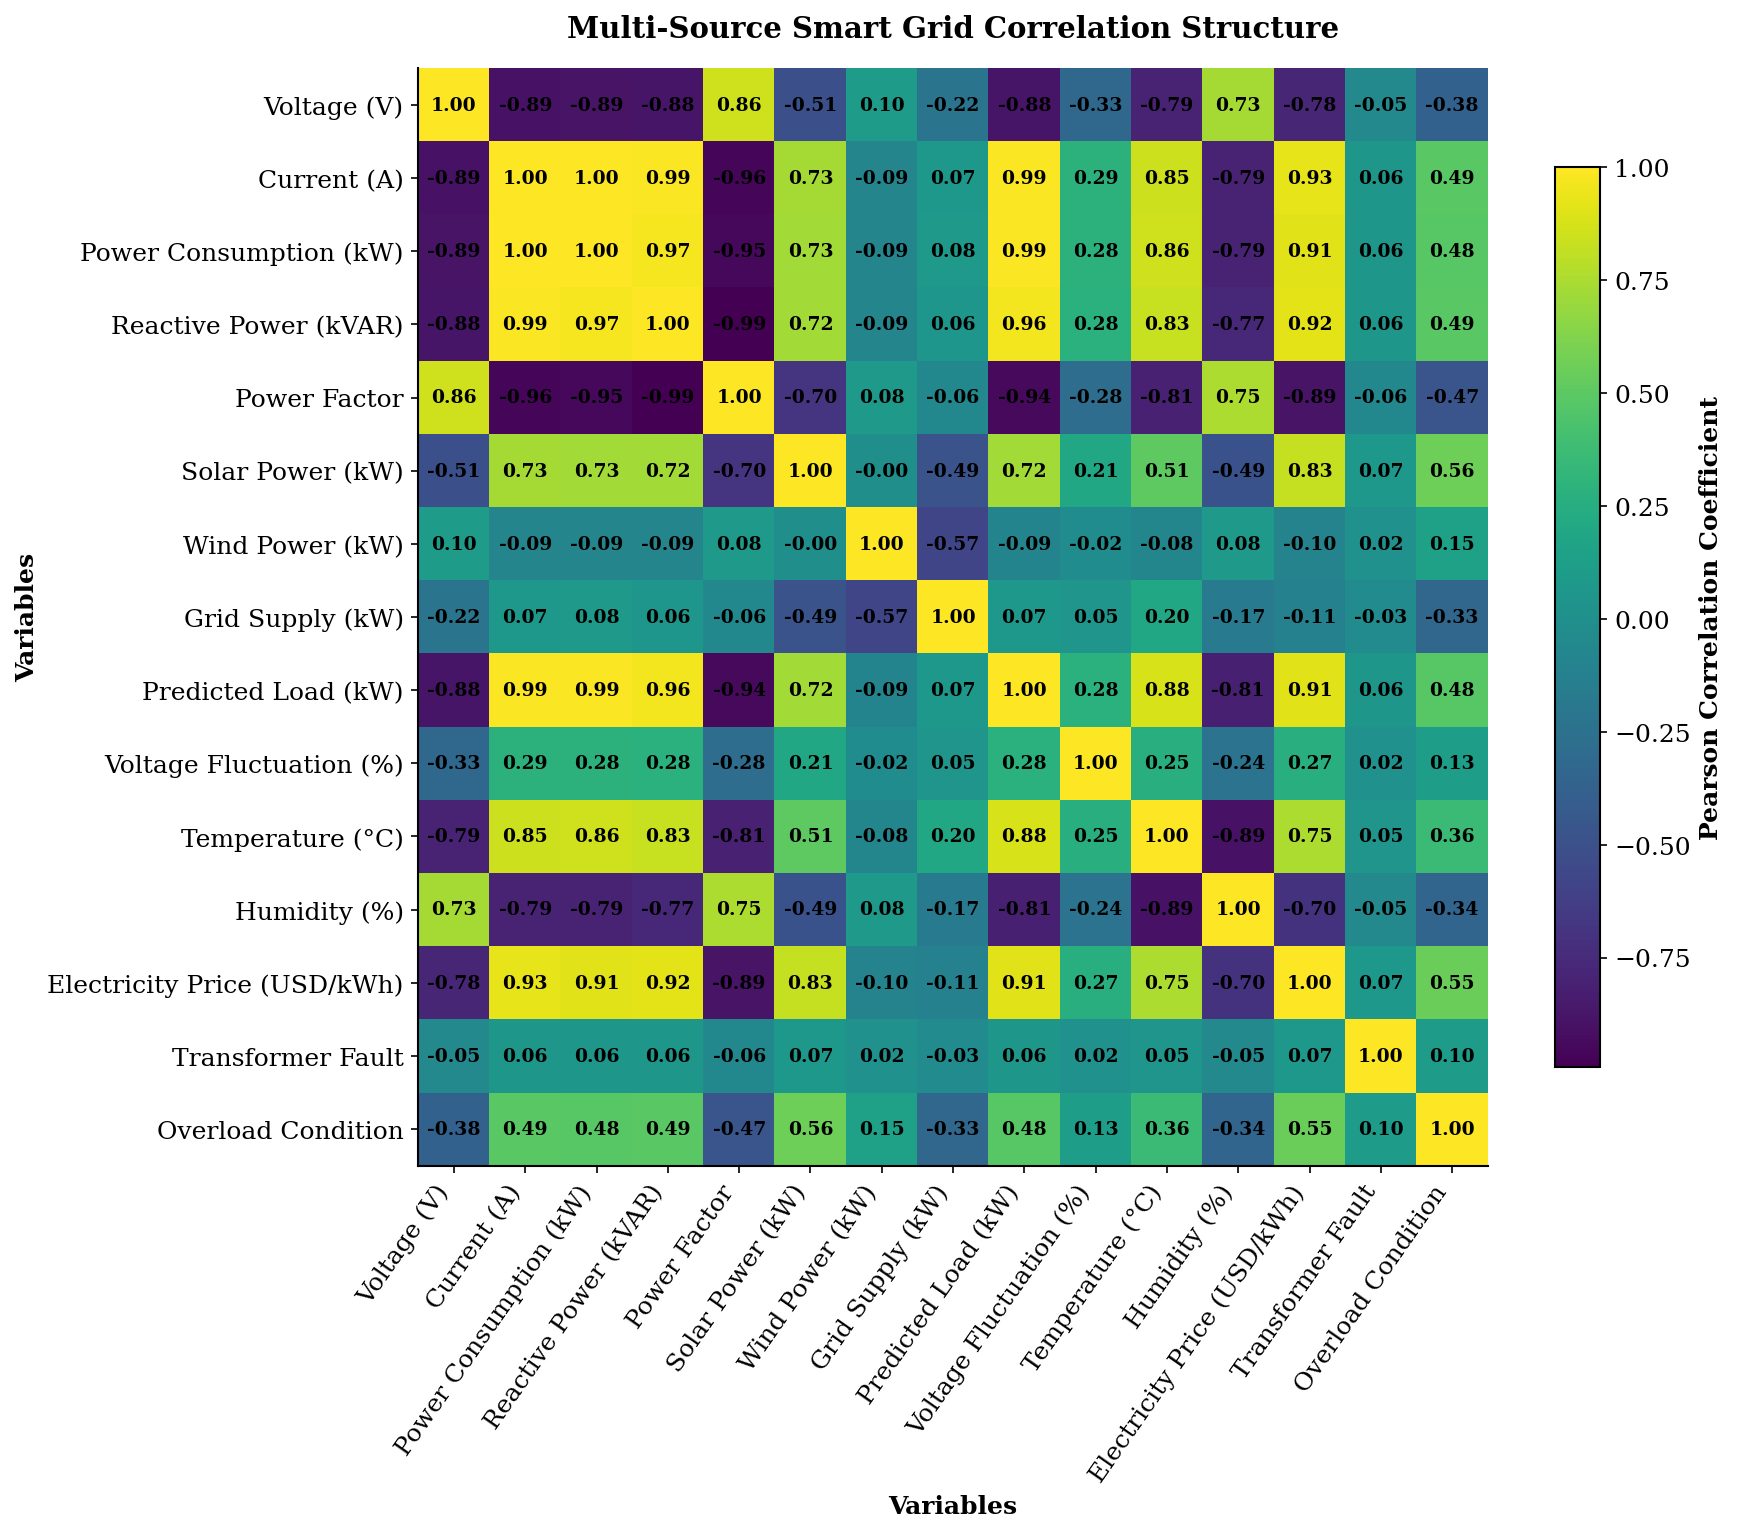


PHYSICS-INFORMED FEATURE ENGINEERING

New engineered features:
  • Power_Factor_Stress

Invalid-value audit:
Empty DataFrame
Columns: [Missing, Infinite]
Index: []

Feature-target Pearson correlation:
Solar Power (kW)               0.561371
Electricity Price (USD/kWh)    0.552062
Current (A)                    0.492989
Reactive Power (kVAR)          0.492067
Power Consumption (kW)         0.481761
Predicted Load (kW)            0.479468
Power_Factor_Stress            0.469983
Power Factor                  -0.469983
Voltage (V)                   -0.376139
Temperature (°C)               0.363052
Humidity (%)                  -0.344256
Grid Supply (kW)              -0.331440
Wind Power (kW)                0.147470
Voltage Fluctuation (%)        0.127390
Transformer Fault              0.104127


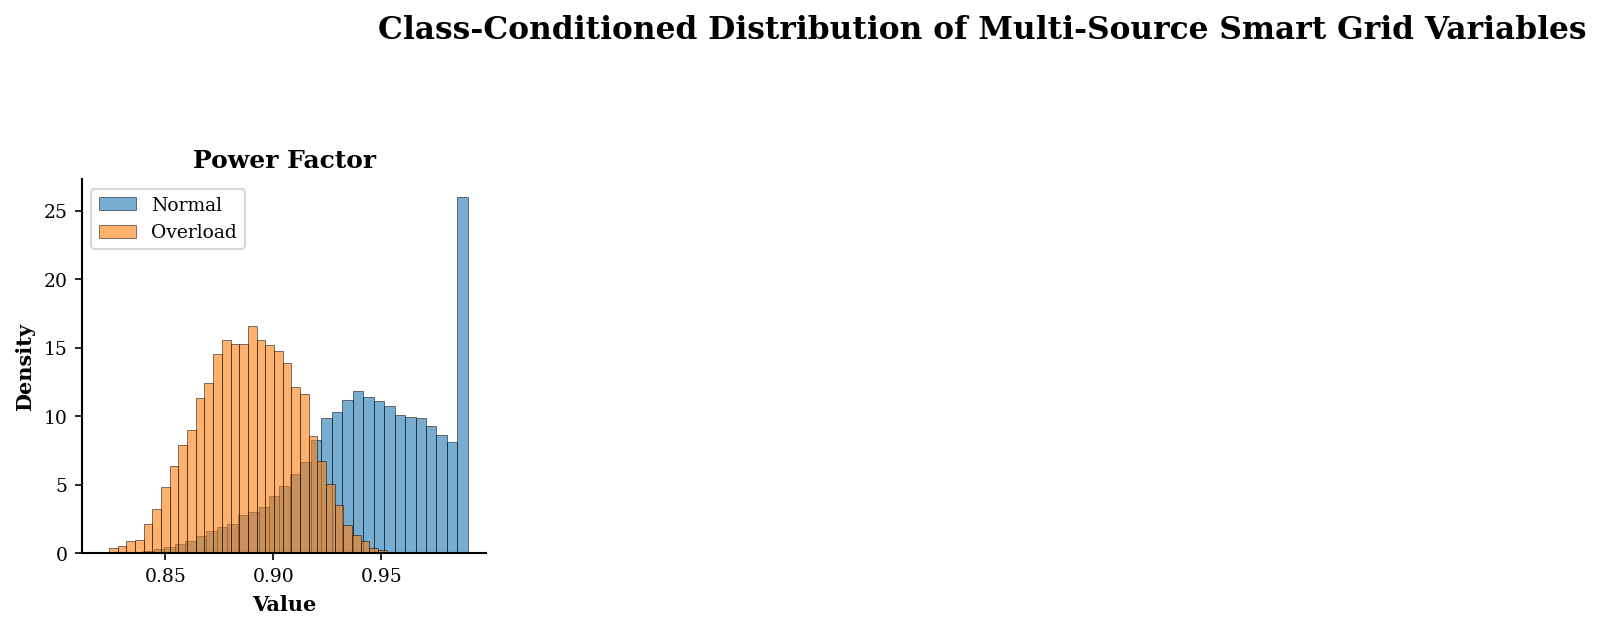

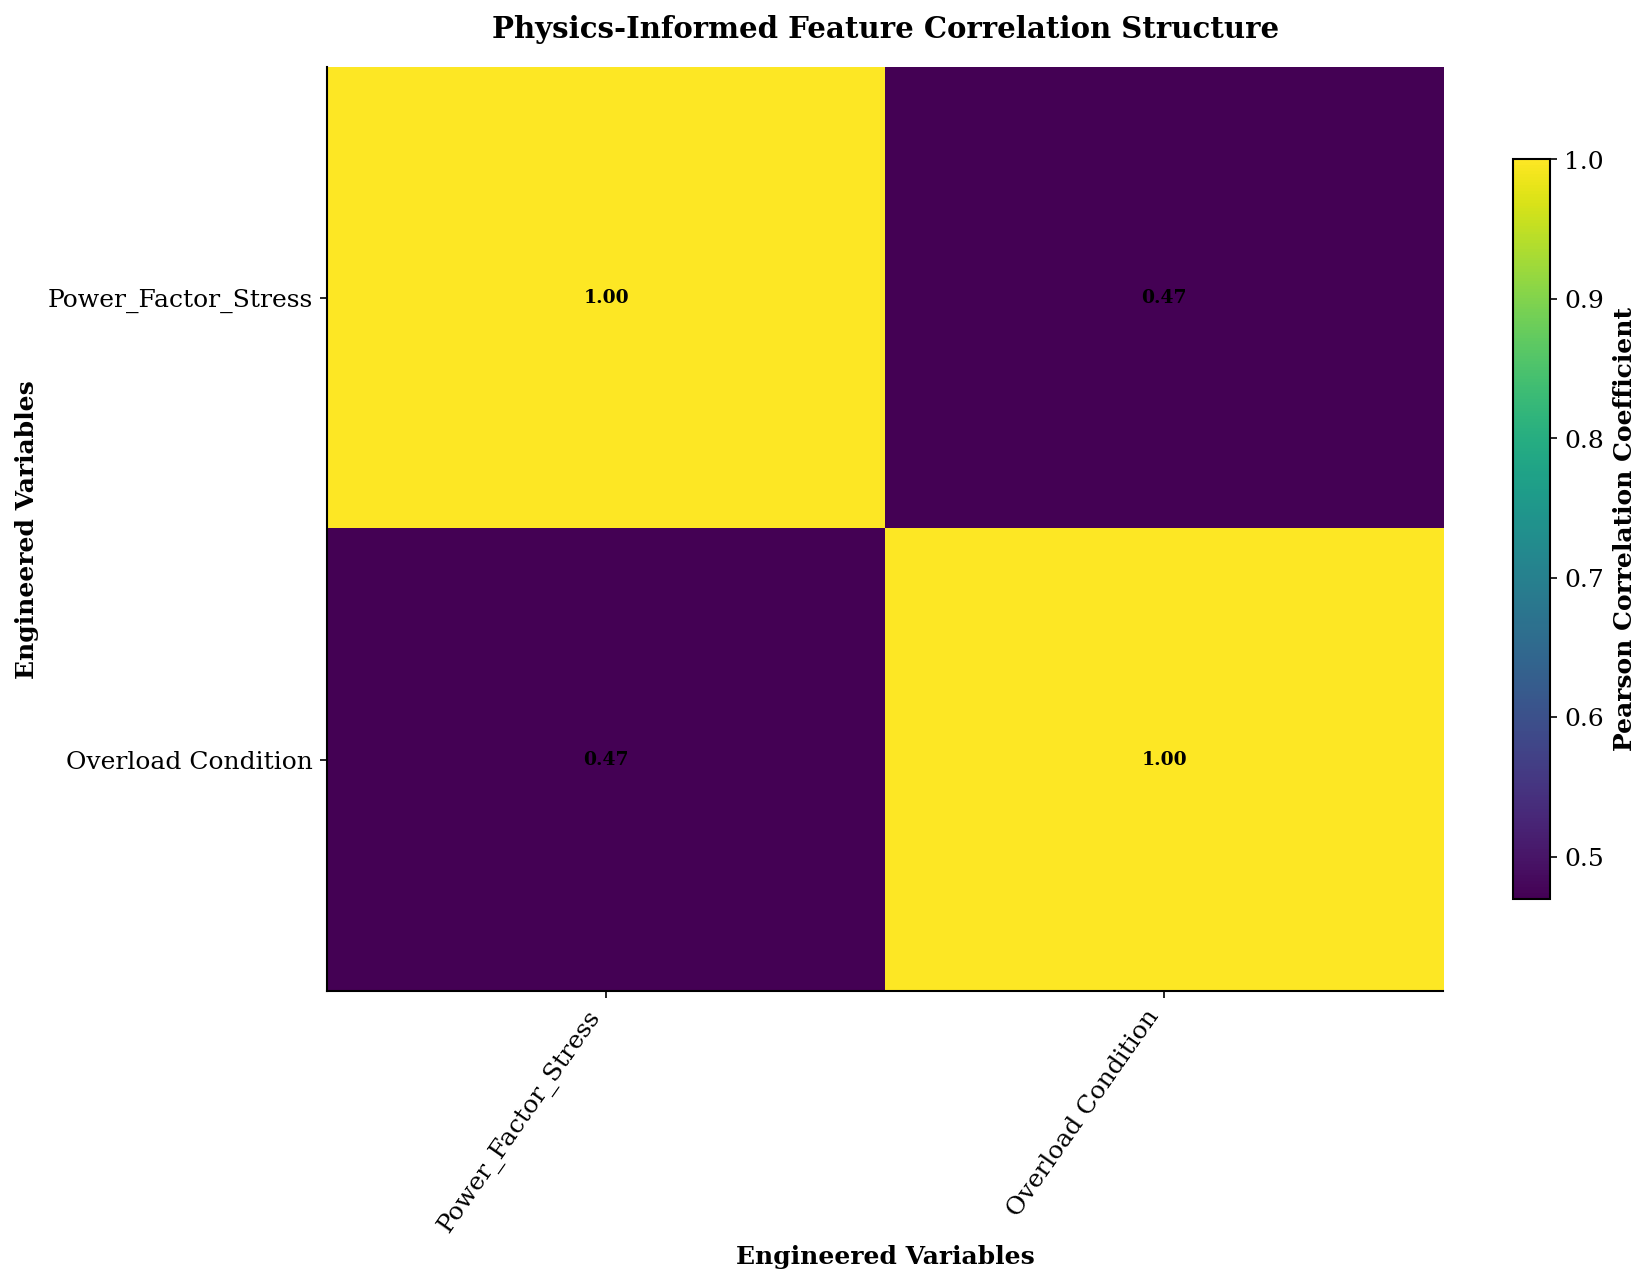


STEP 2 COMPLETED
Original dataset shape : (50000, 16)
Engineered shape       : (50000, 17)
New features           : 1

Saved files:
✓ /content/smart_grid_outputs/Figure_2_Multi_Source_Correlation_Structure.png
✓ /content/smart_grid_outputs/Figure_2_Multi_Source_Correlation_Structure.pdf
✓ /content/smart_grid_outputs/Figure_3_Class_Conditioned_Feature_Distributions.png
✓ /content/smart_grid_outputs/Figure_3_Class_Conditioned_Feature_Distributions.pdf
✓ /content/smart_grid_outputs/Figure_4_Physics_Informed_Correlation.png
✓ /content/smart_grid_outputs/Figure_4_Physics_Informed_Correlation.pdf
✓ /content/smart_grid_outputs/smart_grid_engineered_dataset.csv


In [ ]:
# =============================================================================
# STEP 2: EXPLORATORY DATA ANALYSIS + PHYSICS-INFORMED FEATURE ENGINEERING
# =============================================================================

from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter


# =============================================================================
# CONFIGURATION
# =============================================================================

RANDOM_STATE = 42
TARGET = "Overload Condition"

DATA_PATH = Path("/content/smart_grid_dataset.csv")
OUTPUT_DIR = Path("/content/smart_grid_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RNG = np.random.default_rng(RANDOM_STATE)


# =============================================================================
#  FIGURE CONFIGURATION
# =============================================================================

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "axes.labelweight": "bold",
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 11,
    "axes.linewidth": 1.0,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


# =============================================================================
# LOAD DATA
# =============================================================================

df = pd.read_csv(DATA_PATH)

df["Timestamp"] = pd.to_datetime(
    df["Timestamp"],
    errors="coerce",
)

df = df.sort_values("Timestamp").reset_index(drop=True)

print("=" * 80)
print("STEP 2 — EXPLORATORY DATA ANALYSIS")
print("=" * 80)

print(f"Dataset shape: {df.shape}")


# =============================================================================
# IDENTIFY COLUMN TYPES
# =============================================================================

numeric_columns = df.select_dtypes(
    include=[np.number]
).columns.tolist()

feature_columns = [
    column
    for column in numeric_columns
    if column != TARGET
]

print("\nNumerical predictors:")
for column in feature_columns:
    print(f"  • {column}")


# =============================================================================
# CLASS-WISE STATISTICAL SUMMARY
# =============================================================================

print("\n" + "=" * 80)
print("CLASS-WISE FEATURE STATISTICS")
print("=" * 80)

class_summary = (
    df.groupby(TARGET)[feature_columns]
    .agg(["mean", "median", "std"])
)

print(class_summary)


# =============================================================================
# CALCULATE EFFECT-SIZE-LIKE STANDARDIZED DIFFERENCE
# =============================================================================

normal_df = df[df[TARGET] == 0]
overload_df = df[df[TARGET] == 1]

comparison_rows = []

for feature in feature_columns:

    normal_mean = normal_df[feature].mean()
    overload_mean = overload_df[feature].mean()

    pooled_std = np.sqrt(
        (
            normal_df[feature].var()
            +
            overload_df[feature].var()
        ) / 2
    )

    if pooled_std == 0:
        standardized_difference = 0.0
    else:
        standardized_difference = (
            overload_mean - normal_mean
        ) / pooled_std

    comparison_rows.append(
        {
            "Feature": feature,
            "Normal_Mean": normal_mean,
            "Overload_Mean": overload_mean,
            "Mean_Difference": overload_mean - normal_mean,
            "Standardized_Difference": standardized_difference,
        }
    )

class_difference_df = pd.DataFrame(comparison_rows)

class_difference_df["Abs_Standardized_Difference"] = (
    class_difference_df["Standardized_Difference"]
    .abs()
)

class_difference_df = class_difference_df.sort_values(
    "Abs_Standardized_Difference",
    ascending=False,
)

print("\nStrongest class-wise differences:")
print(
    class_difference_df[
        [
            "Feature",
            "Normal_Mean",
            "Overload_Mean",
            "Standardized_Difference",
        ]
    ].to_string(index=False)
)


# =============================================================================
# FEATURE CORRELATION MATRIX
# =============================================================================

correlation_matrix = df[
    feature_columns + [TARGET]
].corr()


# =============================================================================
# FIGURE 2 — MULTI-SOURCE CORRELATION STRUCTURE
# =============================================================================

fig, ax = plt.subplots(
    figsize=(11.5, 9.5)
)

image = ax.imshow(
    correlation_matrix.values,
    aspect="auto",
    interpolation="nearest",
)

ax.set_title(
    "Multi-Source Smart Grid Correlation Structure",
    pad=15,
)

ax.set_xticks(
    np.arange(len(correlation_matrix.columns))
)

ax.set_yticks(
    np.arange(len(correlation_matrix.index))
)

ax.set_xticklabels(
    correlation_matrix.columns,
    rotation=55,
    ha="right",
)

ax.set_yticklabels(
    correlation_matrix.index
)

# Numerical annotations
for i in range(correlation_matrix.shape[0]):
    for j in range(correlation_matrix.shape[1]):

        value = correlation_matrix.iloc[i, j]

        ax.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=9,
            fontweight="bold",
        )

colorbar = fig.colorbar(
    image,
    ax=ax,
    shrink=0.82,
)

colorbar.set_label(
    "Pearson Correlation Coefficient",
    fontweight="bold",
)

ax.set_xlabel("Variables")
ax.set_ylabel("Variables")

figure_2_png = (
    OUTPUT_DIR /
    "Figure_2_Multi_Source_Correlation_Structure.png"
)

figure_2_pdf = (
    OUTPUT_DIR /
    "Figure_2_Multi_Source_Correlation_Structure.pdf"
)

fig.savefig(
    figure_2_png,
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    figure_2_pdf,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# =============================================================================
# PHYSICS-INFORMED FEATURE ENGINEERING
# =============================================================================

print("\n" + "=" * 80)
print("PHYSICS-INFORMED FEATURE ENGINEERING")
print("=" * 80)

df_model = df.copy()


# -----------------------------------------------------------------------------
# 1. APPARENT POWER
#
# S = sqrt(P^2 + Q^2)
# -----------------------------------------------------------------------------

if {
    "Power Consumption",
    "Reactive Power",
}.issubset(df_model.columns):

    df_model["Apparent_Power"] = np.sqrt(
        np.square(df_model["Power Consumption"])
        +
        np.square(df_model["Reactive Power"])
    )


# -----------------------------------------------------------------------------
# 2. REACTIVE-TO-ACTIVE POWER RATIO
#
# Indicates the relative reactive loading of the system.
# -----------------------------------------------------------------------------

if {
    "Reactive Power",
    "Power Consumption",
}.issubset(df_model.columns):

    denominator = (
        df_model["Power Consumption"].abs()
        + 1e-6
    )

    df_model["Reactive_Active_Power_Ratio"] = (
        df_model["Reactive Power"].abs()
        / denominator
    )


# -----------------------------------------------------------------------------
# 3. RENEWABLE GENERATION
#
# Solar + Wind
# -----------------------------------------------------------------------------

if {
    "Solar Power",
    "Wind Power",
}.issubset(df_model.columns):

    df_model["Total_Renewable_Power"] = (
        df_model["Solar Power"]
        +
        df_model["Wind Power"]
    )


# -----------------------------------------------------------------------------
# 4. RENEWABLE SHARE
#
# Renewable contribution relative to total renewable + grid supply.
# -----------------------------------------------------------------------------

if {
    "Solar Power",
    "Wind Power",
    "Grid Supply",
}.issubset(df_model.columns):

    total_available_supply = (
        df_model["Solar Power"]
        +
        df_model["Wind Power"]
        +
        df_model["Grid Supply"]
    )

    denominator = (
        total_available_supply.abs()
        + 1e-6
    )

    df_model["Renewable_Share"] = (
        (
            df_model["Solar Power"]
            +
            df_model["Wind Power"]
        ).clip(lower=0)
        /
        denominator
    )


# -----------------------------------------------------------------------------
# 5. GRID DEPENDENCY RATIO
# -----------------------------------------------------------------------------

if {
    "Grid Supply",
    "Power Consumption",
}.issubset(df_model.columns):

    denominator = (
        df_model["Power Consumption"].abs()
        + 1e-6
    )

    df_model["Grid_Dependence_Ratio"] = (
        df_model["Grid Supply"].abs()
        /
        denominator
    )


# -----------------------------------------------------------------------------
# 6. LOAD-SUPPLY GAP
#
# Positive values indicate comparatively stronger demand pressure.
# -----------------------------------------------------------------------------

if {
    "Predicted Load",
    "Grid Supply",
}.issubset(df_model.columns):

    df_model["Load_Supply_Gap"] = (
        df_model["Predicted Load"]
        -
        df_model["Grid Supply"]
    )


# -----------------------------------------------------------------------------
# 7. LOAD / POWER RATIO
# -----------------------------------------------------------------------------

if {
    "Predicted Load",
    "Power Consumption",
}.issubset(df_model.columns):

    denominator = (
        df_model["Power Consumption"].abs()
        + 1e-6
    )

    df_model["PredictedLoad_Power_Ratio"] = (
        df_model["Predicted Load"].abs()
        /
        denominator
    )


# -----------------------------------------------------------------------------
# 8. VOLTAGE STRESS INDICATOR
#
# Relative voltage deviation.
# If nominal voltage is unknown, we use the dataset median as a reference.
# This avoids assuming an arbitrary nominal voltage.
# -----------------------------------------------------------------------------

if "Voltage" in df_model.columns:

    nominal_voltage = df_model["Voltage"].median()

    df_model["Relative_Voltage_Deviation"] = (
        (
            df_model["Voltage"]
            -
            nominal_voltage
        ).abs()
        /
        (abs(nominal_voltage) + 1e-6)
    )


# -----------------------------------------------------------------------------
# 9. CURRENT-POWER PRODUCT
#
# Captures combined electrical loading intensity.
# -----------------------------------------------------------------------------

if {
    "Voltage",
    "Current",
}.issubset(df_model.columns):

    df_model["Voltage_Current_Product"] = (
        df_model["Voltage"]
        *
        df_model["Current"]
    )


# -----------------------------------------------------------------------------
# 10. POWER FACTOR STRESS
#
# Lower power factor can indicate poorer utilization of electrical capacity.
# -----------------------------------------------------------------------------

if "Power Factor" in df_model.columns:

    df_model["Power_Factor_Stress"] = (
        1 -
        df_model["Power Factor"].clip(
            lower=0,
            upper=1,
        )
    )


# =============================================================================
# VERIFY ENGINEERED FEATURES
# =============================================================================

engineered_features = [
    column
    for column in df_model.columns
    if column not in df.columns
]

print("\nNew engineered features:")

for feature in engineered_features:
    print(f"  • {feature}")


# =============================================================================
# CHECK FOR INVALID VALUES
# =============================================================================

invalid_summary = pd.DataFrame(
    {
        "Missing": df_model.isna().sum(),
        "Infinite": np.isinf(
            df_model.select_dtypes(
                include=[np.number]
            )
        ).sum(),
    }
)

print("\nInvalid-value audit:")
print(
    invalid_summary[
        (invalid_summary["Missing"] > 0)
        |
        (invalid_summary["Infinite"] > 0)
    ]
)


# =============================================================================
# REMOVE INF VALUES ONLY
# =============================================================================

df_model.replace(
    [np.inf, -np.inf],
    np.nan,
    inplace=True,
)


# =============================================================================
# FEATURE-TARGET ASSOCIATION
# =============================================================================

model_numeric_features = [
    column
    for column in df_model.select_dtypes(
        include=[np.number]
    ).columns
    if column != TARGET
]

feature_target_corr = (
    df_model[
        model_numeric_features + [TARGET]
    ]
    .corr()[TARGET]
    .drop(TARGET)
    .sort_values(
        key=lambda x: x.abs(),
        ascending=False,
    )
)

print("\nFeature-target Pearson correlation:")
print(feature_target_corr.to_string())


# =============================================================================
# FIGURE 3 — CLASS-CONDITIONED FEATURE PROFILE
# =============================================================================

selected_plot_features = [
    feature
    for feature in [
        "Voltage",
        "Current",
        "Power Consumption",
        "Reactive Power",
        "Power Factor",
        "Solar Power",
        "Wind Power",
        "Grid Supply",
        "Predicted Load",
        "Voltage Fluctuation",
        "Temperature",
        "Humidity",
    ]
    if feature in df_model.columns
]


# Limit to strongest interpretable variables if many are available
selected_plot_features = selected_plot_features[:12]

n_features = len(selected_plot_features)

fig, axes = plt.subplots(
    3,
    4,
    figsize=(16, 11),
)

axes = axes.flatten()

for index, feature in enumerate(selected_plot_features):

    ax = axes[index]

    normal_values = (
        df_model.loc[
            df_model[TARGET] == 0,
            feature,
        ]
        .dropna()
    )

    overload_values = (
        df_model.loc[
            df_model[TARGET] == 1,
            feature,
        ]
        .dropna()
    )

    # Histograms
    ax.hist(
        normal_values,
        bins=35,
        alpha=0.60,
        density=True,
        label="Normal",
        edgecolor="black",
        linewidth=0.4,
    )

    ax.hist(
        overload_values,
        bins=35,
        alpha=0.60,
        density=True,
        label="Overload",
        edgecolor="black",
        linewidth=0.4,
    )

    ax.set_title(
        feature,
        fontsize=12,
        fontweight="bold",
    )

    ax.set_xlabel(
        "Value",
        fontsize=10,
        fontweight="bold",
    )

    ax.set_ylabel(
        "Density",
        fontsize=10,
        fontweight="bold",
    )

    ax.tick_params(
        labelsize=9
    )

    if index == 0:
        ax.legend(
            loc="best",
            fontsize=9,
        )


# Remove unused axes
for index in range(n_features, len(axes)):
    fig.delaxes(axes[index])


fig.suptitle(
    "Class-Conditioned Distribution of Multi-Source Smart Grid Variables",
    fontsize=15,
    fontweight="bold",
)

figure_3_png = (
    OUTPUT_DIR /
    "Figure_3_Class_Conditioned_Feature_Distributions.png"
)

figure_3_pdf = (
    OUTPUT_DIR /
    "Figure_3_Class_Conditioned_Feature_Distributions.pdf"
)

fig.savefig(
    figure_3_png,
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    figure_3_pdf,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# =============================================================================
# FIGURE 4 — PHYSICS-INFORMED FEATURE CORRELATION
# =============================================================================

physics_features = [
    feature
    for feature in engineered_features
    if feature in df_model.columns
]

if physics_features:

    physics_corr = df_model[
        physics_features + [TARGET]
    ].corr()

    fig, ax = plt.subplots(
        figsize=(12, 8)
    )

    image = ax.imshow(
        physics_corr.values,
        aspect="auto",
        interpolation="nearest",
    )

    ax.set_title(
        "Physics-Informed Feature Correlation Structure",
        pad=14,
    )

    ax.set_xticks(
        np.arange(len(physics_corr.columns))
    )

    ax.set_yticks(
        np.arange(len(physics_corr.index))
    )

    ax.set_xticklabels(
        physics_corr.columns,
        rotation=55,
        ha="right",
    )

    ax.set_yticklabels(
        physics_corr.index
    )

    for i in range(physics_corr.shape[0]):
        for j in range(physics_corr.shape[1]):

            value = physics_corr.iloc[i, j]

            ax.text(
                j,
                i,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=9,
                fontweight="bold",
            )

    colorbar = fig.colorbar(
        image,
        ax=ax,
        shrink=0.80,
    )

    colorbar.set_label(
        "Pearson Correlation Coefficient",
        fontweight="bold",
    )

    ax.set_xlabel(
        "Engineered Variables",
        fontweight="bold",
    )

    ax.set_ylabel(
        "Engineered Variables",
        fontweight="bold",
    )

    figure_4_png = (
        OUTPUT_DIR /
        "Figure_4_Physics_Informed_Correlation.png"
    )

    figure_4_pdf = (
        OUTPUT_DIR /
        "Figure_4_Physics_Informed_Correlation.pdf"
    )

    fig.savefig(
        figure_4_png,
        dpi=300,
        bbox_inches="tight",
    )

    fig.savefig(
        figure_4_pdf,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()


# =============================================================================
# SAVE ENGINEERED DATASET
# =============================================================================

ENGINEERED_PATH = (
    OUTPUT_DIR /
    "smart_grid_engineered_dataset.csv"
)

df_model.to_csv(
    ENGINEERED_PATH,
    index=False,
)

print("\n" + "=" * 80)
print("STEP 2 COMPLETED")
print("=" * 80)

print(f"Original dataset shape : {df.shape}")
print(f"Engineered shape       : {df_model.shape}")
print(f"New features           : {len(engineered_features)}")

print("\nSaved files:")

print(f"✓ {figure_2_png}")
print(f"✓ {figure_2_pdf}")
print(f"✓ {figure_3_png}")
print(f"✓ {figure_3_pdf}")

if physics_features:
    print(f"✓ {figure_4_png}")
    print(f"✓ {figure_4_pdf}")

print(f"✓ {ENGINEERED_PATH}")

STEP 3 — CHRONOLOGICAL DATA SPLITTING
Total observations: 50,000
Start timestamp   : 2024-01-01 00:00:00
End timestamp     : 2025-06-04 19:45:00

Primary modeling features:
01. Voltage (V)
02. Current (A)
03. Power Consumption (kW)
04. Reactive Power (kVAR)
05. Power Factor
06. Solar Power (kW)
07. Wind Power (kW)
08. Grid Supply (kW)
09. Predicted Load (kW)
10. Voltage Fluctuation (%)
11. Temperature (°C)
12. Humidity (%)
13. Electricity Price (USD/kWh)
14. Power_Factor_Stress

✓ No obvious target-leakage feature detected.
✓ No missing model variables detected.

TEMPORAL SPLIT SUMMARY
     Split  Samples  Percentage               Start                 End
  Training    35000        70.0 2024-01-01 00:00:00 2024-12-30 13:45:00
Validation     7500        15.0 2024-12-30 14:00:00 2025-03-18 16:45:00
      Test     7500        15.0 2025-03-18 17:00:00 2025-06-04 19:45:00

TARGET DISTRIBUTION BY TEMPORAL SPLIT
            Normal_Count  Overload_Count  Normal_%  Overload_%
Training        3

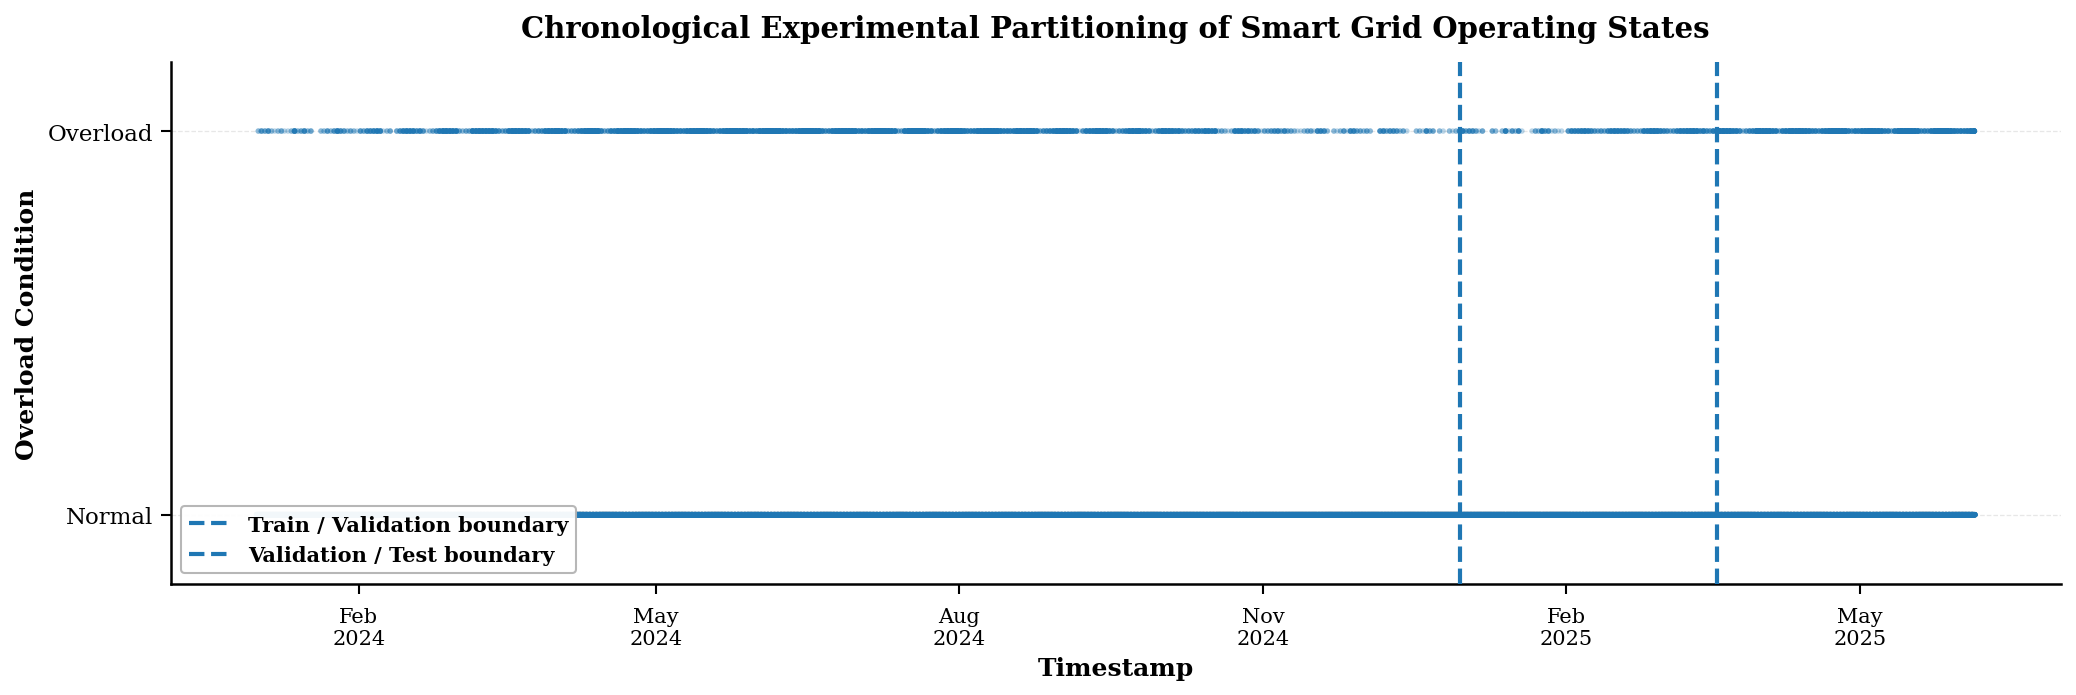


STEP 3 COMPLETED
Training samples   : 35,000
Validation samples : 7,500
Test samples       : 7,500
Number of features : 14

Training period: 2024-01-01 00:00:00 → 2024-12-30 13:45:00
Validation period: 2024-12-30 14:00:00 → 2025-03-18 16:45:00
Test period: 2025-03-18 17:00:00 → 2025-06-04 19:45:00

✓ Scaler fitted only on training data.
✓ Validation and test data transformed without refitting.
✓ Class weights calculated from training data only.
✓ Primary experiment is leakage-safe.


In [ ]:
# =============================================================================
# STEP 3
# LEAKAGE-SAFE CHRONOLOGICAL SPLITTING + PREPROCESSING
# =============================================================================

from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight


# =============================================================================
# CONFIGURATION
# =============================================================================

RANDOM_STATE = 42

OUTPUT_DIR = Path("/content/smart_grid_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ENGINEERED_PATH = (
    OUTPUT_DIR / "smart_grid_engineered_dataset.csv"
)

TARGET = "Overload Condition"

TRAIN_RATIO = 0.70
VALIDATION_RATIO = 0.15
TEST_RATIO = 0.15


# =============================================================================
# LOAD ENGINEERED DATASET
# =============================================================================

df = pd.read_csv(ENGINEERED_PATH)

df["Timestamp"] = pd.to_datetime(
    df["Timestamp"],
    errors="coerce",
)

# Strict chronological ordering
df = (
    df.sort_values("Timestamp")
    .reset_index(drop=True)
)

print("=" * 80)
print("STEP 3 — CHRONOLOGICAL DATA SPLITTING")
print("=" * 80)

print(f"Total observations: {len(df):,}")
print(f"Start timestamp   : {df['Timestamp'].min()}")
print(f"End timestamp     : {df['Timestamp'].max()}")


# =============================================================================
# DEFINE PRIMARY MODEL FEATURES
# =============================================================================

# Transformer Fault is deliberately excluded from the primary experiment.
#
# Timestamp-derived variables are also excluded initially because they could
# introduce temporal shortcuts rather than representing physical predictors.
#
# The target is strictly excluded.

EXCLUDED_COLUMNS = {
    "Timestamp",
    "Date",
    TARGET,
    "Transformer Fault",
}

feature_columns = [
    column
    for column in df.columns
    if column not in EXCLUDED_COLUMNS
    and pd.api.types.is_numeric_dtype(df[column])
]

print("\nPrimary modeling features:")
for index, feature in enumerate(feature_columns, start=1):
    print(f"{index:02d}. {feature}")


# =============================================================================
# VERIFY NO TARGET LEAKAGE IN FEATURE NAMES
# =============================================================================

leakage_keywords = [
    "overload",
    "target",
    "label",
    "class",
]

potential_leakage_features = [
    feature
    for feature in feature_columns
    if any(
        keyword in feature.lower()
        for keyword in leakage_keywords
    )
]

if potential_leakage_features:
    raise ValueError(
        "Potential target-leakage features detected: "
        f"{potential_leakage_features}"
    )

print("\n✓ No obvious target-leakage feature detected.")


# =============================================================================
# HANDLE INF VALUES
# =============================================================================

df[feature_columns] = (
    df[feature_columns]
    .replace([np.inf, -np.inf], np.nan)
)


# =============================================================================
# CHECK MISSING VALUES
# =============================================================================

missing_feature_counts = (
    df[feature_columns]
    .isna()
    .sum()
)

if missing_feature_counts.sum() > 0:

    print("\nMissing values detected:")
    print(
        missing_feature_counts[
            missing_feature_counts > 0
        ]
    )

    # Interpolation is NOT performed because it can blur temporal boundaries.
    # Instead, rows with missing modeling variables are removed.
    before_rows = len(df)

    df = df.dropna(
        subset=feature_columns + [TARGET]
    ).reset_index(drop=True)

    after_rows = len(df)

    print(
        f"Removed {before_rows - after_rows:,} rows "
        "containing missing model variables."
    )

else:
    print("✓ No missing model variables detected.")


# =============================================================================
# CHRONOLOGICAL TRAIN / VALIDATION / TEST SPLIT
# =============================================================================

n_samples = len(df)

train_end = int(
    n_samples * TRAIN_RATIO
)

validation_end = int(
    n_samples *
    (TRAIN_RATIO + VALIDATION_RATIO)
)

train_df = df.iloc[
    :train_end
].copy()

validation_df = df.iloc[
    train_end:validation_end
].copy()

test_df = df.iloc[
    validation_end:
].copy()


# =============================================================================
# PRINT SPLIT INFORMATION
# =============================================================================

print("\n" + "=" * 80)
print("TEMPORAL SPLIT SUMMARY")
print("=" * 80)

split_information = pd.DataFrame(
    {
        "Split": [
            "Training",
            "Validation",
            "Test",
        ],
        "Samples": [
            len(train_df),
            len(validation_df),
            len(test_df),
        ],
        "Percentage": [
            len(train_df) / len(df) * 100,
            len(validation_df) / len(df) * 100,
            len(test_df) / len(df) * 100,
        ],
        "Start": [
            train_df["Timestamp"].min(),
            validation_df["Timestamp"].min(),
            test_df["Timestamp"].min(),
        ],
        "End": [
            train_df["Timestamp"].max(),
            validation_df["Timestamp"].max(),
            test_df["Timestamp"].max(),
        ],
    }
)

print(
    split_information.to_string(
        index=False
    )
)


# =============================================================================
# TARGET DISTRIBUTION BY SPLIT
# =============================================================================

print("\n" + "=" * 80)
print("TARGET DISTRIBUTION BY TEMPORAL SPLIT")
print("=" * 80)


def get_class_distribution(
    data: pd.DataFrame,
) -> Dict[str, float]:
    """
    Return normal/overload sample counts and percentages.
    """

    counts = (
        data[TARGET]
        .value_counts()
        .reindex([0, 1], fill_value=0)
    )

    total = counts.sum()

    return {
        "Normal_Count": counts.loc[0],
        "Overload_Count": counts.loc[1],
        "Normal_%": counts.loc[0] / total * 100,
        "Overload_%": counts.loc[1] / total * 100,
    }


distribution_table = pd.DataFrame(
    {
        "Training": get_class_distribution(
            train_df
        ),
        "Validation": get_class_distribution(
            validation_df
        ),
        "Test": get_class_distribution(
            test_df
        ),
    }
).T

print(
    distribution_table.to_string(
        float_format=lambda x: f"{x:.2f}"
    )
)


# =============================================================================
# CREATE X / y MATRICES
# =============================================================================

X_train = train_df[
    feature_columns
].copy()

y_train = train_df[
    TARGET
].astype(int).copy()

X_validation = validation_df[
    feature_columns
].copy()

y_validation = validation_df[
    TARGET
].astype(int).copy()

X_test = test_df[
    feature_columns
].copy()

y_test = test_df[
    TARGET
].astype(int).copy()


# =============================================================================
# VERIFY TEMPORAL ORDER
# =============================================================================

assert (
    train_df["Timestamp"].max()
    <
    validation_df["Timestamp"].min()
)

assert (
    validation_df["Timestamp"].max()
    <
    test_df["Timestamp"].min()
)

print("\n✓ Chronological ordering verified.")


# =============================================================================
# STANDARDIZATION
#
# IMPORTANT:
# The scaler is fitted exclusively on X_train.
# =============================================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_validation_scaled = scaler.transform(
    X_validation
)

X_test_scaled = scaler.transform(
    X_test
)


# =============================================================================
# CONVERT BACK TO DATAFRAMES
# =============================================================================

X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=feature_columns,
    index=X_train.index,
)

X_validation_scaled = pd.DataFrame(
    X_validation_scaled,
    columns=feature_columns,
    index=X_validation.index,
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=feature_columns,
    index=X_test.index,
)


# =============================================================================
# VERIFY STANDARDIZATION
# =============================================================================

print("\n" + "=" * 80)
print("TRAINING-SCALE VERIFICATION")
print("=" * 80)

verification = pd.DataFrame(
    {
        "Train_Mean": X_train_scaled.mean(),
        "Train_Std": X_train_scaled.std(),
        "Validation_Mean": X_validation_scaled.mean(),
        "Test_Mean": X_test_scaled.mean(),
    }
)

print(
    verification.round(4).to_string()
)


# =============================================================================
# CLASS WEIGHTS
# =============================================================================

classes = np.array([0, 1])

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train,
)

class_weights = {
    int(cls): float(weight)
    for cls, weight in zip(
        classes,
        weights,
    )
}

print("\n" + "=" * 80)
print("CLASS WEIGHTS")
print("=" * 80)

print(
    f"Normal   (0): {class_weights[0]:.4f}"
)

print(
    f"Overload (1): {class_weights[1]:.4f}"
)


# =============================================================================
# FIGURE 5 — TEMPORAL EXPERIMENTAL SPLIT
# IEEE Publication Quality
# =============================================================================

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# =============================================================================
# IEEE Style
# =============================================================================

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": [
        "Times New Roman",
        "DejaVu Serif",
    ],
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "axes.labelweight": "bold",
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
})

# =============================================================================
# Create Figure
# =============================================================================

fig, ax = plt.subplots(
    figsize=(14, 4.8)
)

# =============================================================================
# Temporal State Representation
# =============================================================================

plot_state = df[TARGET].to_numpy()

ax.scatter(
    df["Timestamp"],
    plot_state,
    s=7,
    alpha=0.30,
    edgecolors="none",
    zorder=2,
)

# =============================================================================
# Temporal Split Boundaries
# =============================================================================

validation_start = validation_df["Timestamp"].min()
test_start = test_df["Timestamp"].min()

ax.axvline(
    validation_start,
    linestyle="--",
    linewidth=2.0,
    label="Train / Validation boundary",
    zorder=4,
)

ax.axvline(
    test_start,
    linestyle="--",
    linewidth=2.0,
    label="Validation / Test boundary",
    zorder=4,
)

# =============================================================================
# Labels
# =============================================================================

ax.set_title(
    "Chronological Experimental Partitioning of Smart Grid Operating States",
    fontsize=14,
    fontweight="bold",
    pad=12,
)

ax.set_xlabel(
    "Timestamp",
    fontsize=12,
    fontweight="bold",
)

ax.set_ylabel(
    "Overload Condition",
    fontsize=12,
    fontweight="bold",
)

# =============================================================================
# Operating-State Axis
# =============================================================================

ax.set_yticks([0, 1])

ax.set_yticklabels(
    ["Normal", "Overload"],
    fontsize=11,
)

# Add vertical breathing room around binary states
ax.set_ylim(-0.18, 1.18)

# =============================================================================
# Date Formatting
# =============================================================================

ax.xaxis.set_major_locator(
    mdates.MonthLocator(interval=3)
)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%b\n%Y")
)

ax.tick_params(
    axis="x",
    labelsize=10,
    rotation=0,
    pad=6,
)

# =============================================================================
# Grid
# =============================================================================

ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.6,
    alpha=0.30,
    zorder=1,
)

# =============================================================================
# Axis Styling
# =============================================================================

ax.tick_params(
    axis="both",
    which="major",
    direction="out",
    length=5,
    width=1.0,
)

for spine in ax.spines.values():
    spine.set_linewidth(1.2)

# Remove unnecessary upper and right borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# =============================================================================
# Legend
# =============================================================================

legend = ax.legend(
    loc="lower left",
    frameon=True,
    framealpha=0.95,
    edgecolor="0.70",
    fontsize=10,
)

# Bold legend text
for text in legend.get_texts():
    text.set_fontweight("bold")

# =============================================================================
# Layout
# =============================================================================

fig.tight_layout()

# =============================================================================
# Save Figure
# =============================================================================

figure_5_png = (
    OUTPUT_DIR /
    "Figure_5_Chronological_Data_Split.png"
)

figure_5_pdf = (
    OUTPUT_DIR /
    "Figure_5_Chronological_Data_Split.pdf"
)

fig.savefig(
    figure_5_png,
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    figure_5_pdf,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# =============================================================================
# SAVE PREPROCESSED ARRAYS
# =============================================================================

np.save(
    OUTPUT_DIR / "X_train_scaled.npy",
    X_train_scaled.to_numpy(),
)

np.save(
    OUTPUT_DIR / "X_validation_scaled.npy",
    X_validation_scaled.to_numpy(),
)

np.save(
    OUTPUT_DIR / "X_test_scaled.npy",
    X_test_scaled.to_numpy(),
)

np.save(
    OUTPUT_DIR / "y_train.npy",
    y_train.to_numpy(),
)

np.save(
    OUTPUT_DIR / "y_validation.npy",
    y_validation.to_numpy(),
)

np.save(
    OUTPUT_DIR / "y_test.npy",
    y_test.to_numpy(),
)


# =============================================================================
# SAVE FEATURE INFORMATION
# =============================================================================

feature_info = pd.DataFrame(
    {
        "Feature": feature_columns,
        "Training_Mean": X_train.mean().values,
        "Training_Std": X_train.std().values,
        "Scaled_Training_Mean": (
            X_train_scaled.mean().values
        ),
        "Scaled_Training_Std": (
            X_train_scaled.std().values
        ),
    }
)

feature_info.to_csv(
    OUTPUT_DIR / "model_feature_information.csv",
    index=False,
)


# =============================================================================
# SAVE SPLIT METADATA
# =============================================================================

split_metadata = pd.DataFrame(
    {
        "Split": [
            "Training",
            "Validation",
            "Test",
        ],
        "Samples": [
            len(train_df),
            len(validation_df),
            len(test_df),
        ],
        "Start": [
            train_df["Timestamp"].min(),
            validation_df["Timestamp"].min(),
            test_df["Timestamp"].min(),
        ],
        "End": [
            train_df["Timestamp"].max(),
            validation_df["Timestamp"].max(),
            test_df["Timestamp"].max(),
        ],
    }
)

split_metadata.to_csv(
    OUTPUT_DIR / "temporal_split_metadata.csv",
    index=False,
)


# =============================================================================
# SAVE FEATURE LIST
# =============================================================================

pd.DataFrame(
    {
        "Feature": feature_columns
    }
).to_csv(
    OUTPUT_DIR / "primary_model_features.csv",
    index=False,
)


# =============================================================================
# FINAL SUMMARY
# =============================================================================

print("\n" + "=" * 80)
print("STEP 3 COMPLETED")
print("=" * 80)

print(
    f"Training samples   : {len(X_train):,}"
)

print(
    f"Validation samples : {len(X_validation):,}"
)

print(
    f"Test samples       : {len(X_test):,}"
)

print(
    f"Number of features : {len(feature_columns)}"
)

print(
    f"\nTraining period:"
    f" {train_df['Timestamp'].min()} → "
    f"{train_df['Timestamp'].max()}"
)

print(
    f"Validation period:"
    f" {validation_df['Timestamp'].min()} → "
    f"{validation_df['Timestamp'].max()}"
)

print(
    f"Test period:"
    f" {test_df['Timestamp'].min()} → "
    f"{test_df['Timestamp'].max()}"
)

print("\n✓ Scaler fitted only on training data.")
print("✓ Validation and test data transformed without refitting.")
print("✓ Class weights calculated from training data only.")
print("✓ Primary experiment is leakage-safe.")

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.3 MB/s eta 0:00:00


STEP 4 — MACHINE LEARNING MODEL DEVELOPMENT
Training samples   : 35,000
Validation samples : 7,500
Test samples       : 7,500
Number of features : 14

Class weights:
Normal   : 0.5558
Overload : 4.9801

TRAINING MODELS

[Logistic Regression]
Validation F1      : 0.6787
Validation ROC-AUC : 0.9892
Validation MCC     : 0.6861

[SVM]
Validation F1      : 0.6635
Validation ROC-AUC : 0.9886
Validation MCC     : 0.6747

[Random Forest]
Validation F1      : 0.7091
Validation ROC-AUC : 0.9858
Validation MCC     : 0.7008

[XGBoost]
Validation F1      : 0.7497
Validation ROC-AUC : 0.9873
Validation MCC     : 0.7385

[LightGBM]
Validation F1      : 0.7351
Validation ROC-AUC : 0.9867
Validation MCC     : 0.7213

[CatBoost]
Validation F1      : 0.6913
Validation ROC-AUC : 0.9885
Validation MCC     : 0.6958

VALIDATION PERFORMANCE
              Model  Accuracy  Precision  Recall     F1  ROC_AUC  PR_AUC    MCC  Cohen_Kappa  Training_Time_s  Prediction_Time_s
            XGBoost    0.9668     0.6685  

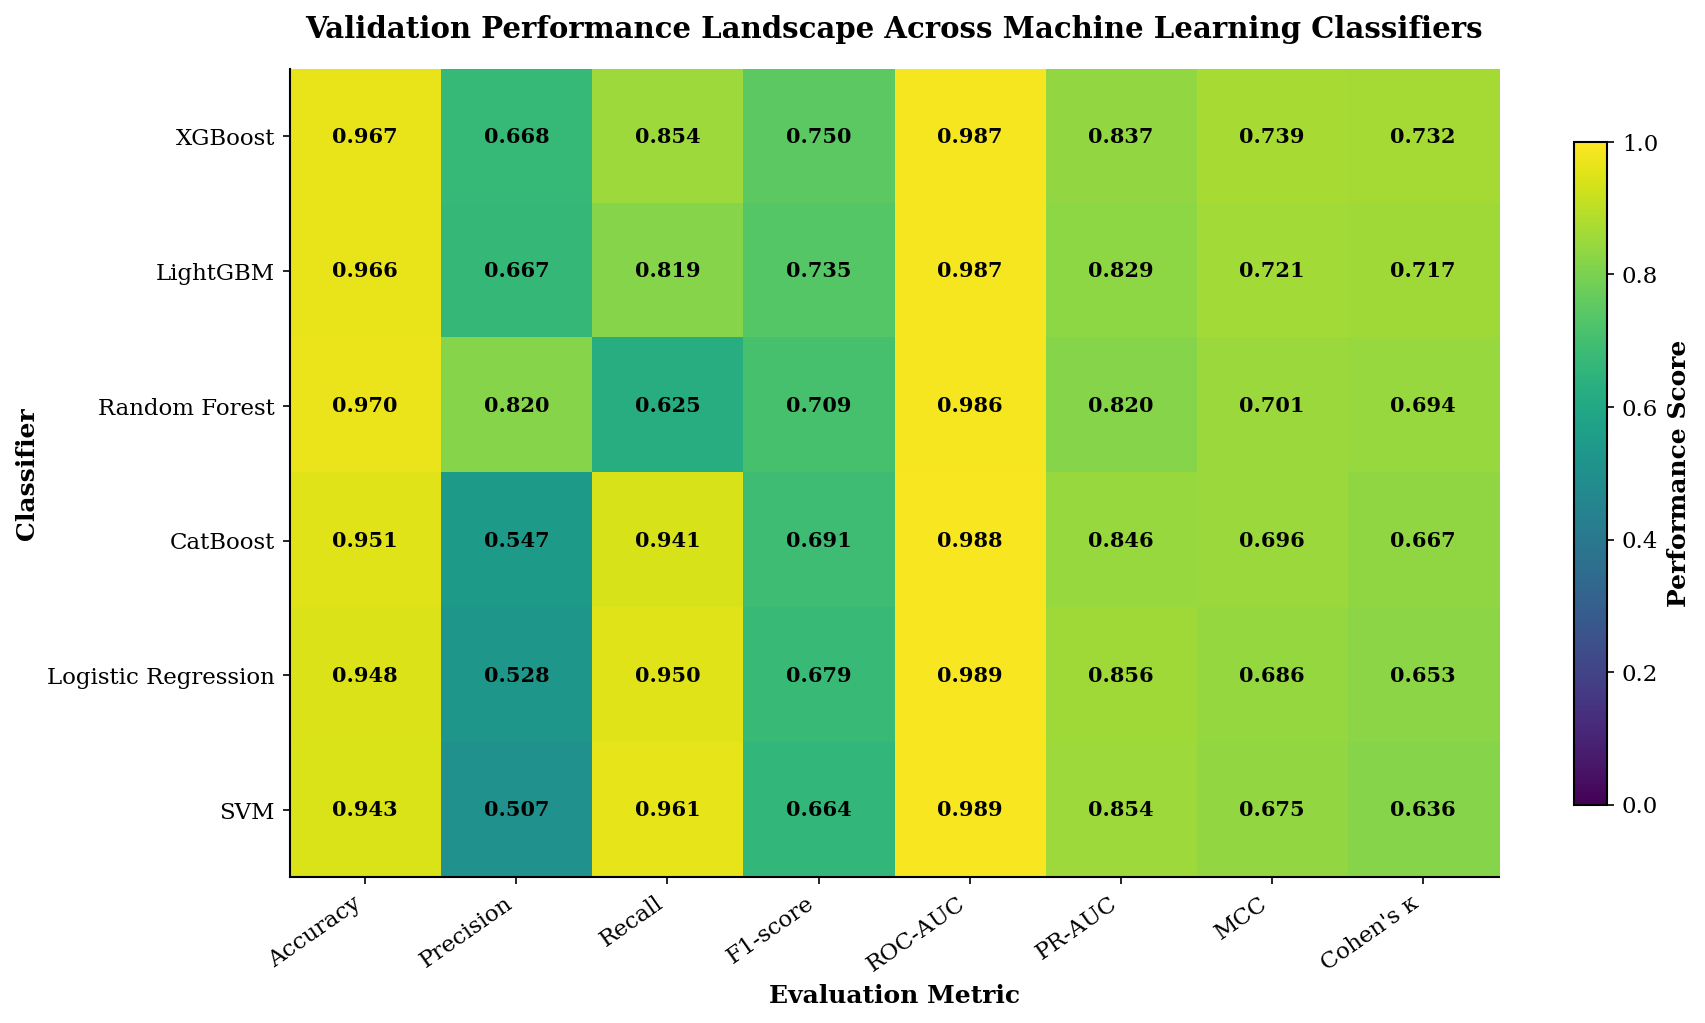

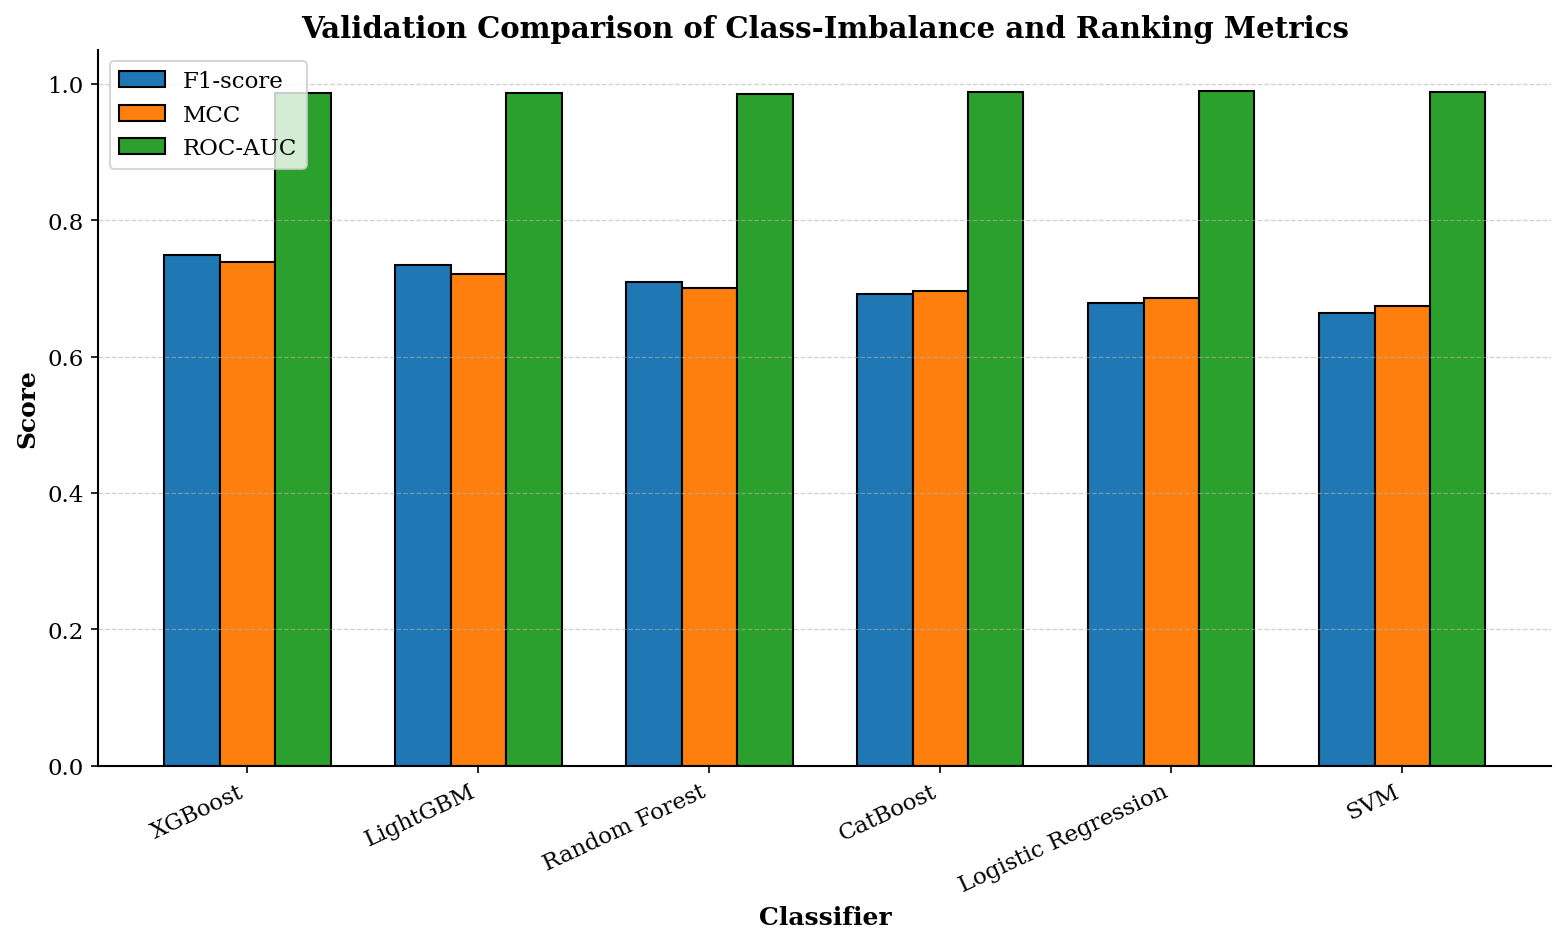


PIPELINE VERIFICATION
X_train shape       : (35000, 14)
X_validation shape  : (7500, 14)
X_test shape        : (7500, 14)
y_train shape       : (35000,)
y_validation shape  : (7500,)
y_test shape        : (7500,)

✓ All six classifiers successfully trained.
✓ Validation metrics calculated.
✓ Best model selected using validation F1-score.
✓ Selected model: XGBoost


In [ ]:
# =============================================================================
# STEP 4
# MACHINE LEARNING MODEL DEVELOPMENT AND VALIDATION
# =============================================================================

from pathlib import Path
from time import perf_counter
from typing import Dict, List, Tuple, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    cohen_kappa_score,
    confusion_matrix,
)

# Gradient boosting libraries
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier


# =============================================================================
# CONFIGURATION
# =============================================================================

RANDOM_STATE = 42

OUTPUT_DIR = Path("/content/smart_grid_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET = "Overload Condition"


# =============================================================================
# LOAD PREPROCESSED DATA
# =============================================================================

X_train = pd.DataFrame(
    np.load(
        OUTPUT_DIR / "X_train_scaled.npy"
    )
)

X_validation = pd.DataFrame(
    np.load(
        OUTPUT_DIR / "X_validation_scaled.npy"
    )
)

X_test = pd.DataFrame(
    np.load(
        OUTPUT_DIR / "X_test_scaled.npy"
    )
)

y_train = np.load(
    OUTPUT_DIR / "y_train.npy"
).astype(int)

y_validation = np.load(
    OUTPUT_DIR / "y_validation.npy"
).astype(int)

y_test = np.load(
    OUTPUT_DIR / "y_test.npy"
).astype(int)


# =============================================================================
# RESTORE FEATURE NAMES
# =============================================================================

feature_information = pd.read_csv(
    OUTPUT_DIR / "model_feature_information.csv"
)

feature_names = feature_information[
    "Feature"
].tolist()

X_train.columns = feature_names
X_validation.columns = feature_names
X_test.columns = feature_names


# =============================================================================
# LOAD CLASS WEIGHTS
# =============================================================================

normal_count = np.sum(y_train == 0)
overload_count = np.sum(y_train == 1)

n_train = len(y_train)

weight_normal = (
    n_train /
    (2.0 * normal_count)
)

weight_overload = (
    n_train /
    (2.0 * overload_count)
)

class_weights = {
    0: weight_normal,
    1: weight_overload,
}

scale_pos_weight = (
    overload_count and
    normal_count / overload_count
)


print("=" * 80)
print("STEP 4 — MACHINE LEARNING MODEL DEVELOPMENT")
print("=" * 80)

print(f"Training samples   : {len(X_train):,}")
print(f"Validation samples : {len(X_validation):,}")
print(f"Test samples       : {len(X_test):,}")
print(f"Number of features : {len(feature_names)}")

print("\nClass weights:")
print(f"Normal   : {weight_normal:.4f}")
print(f"Overload : {weight_overload:.4f}")


# =============================================================================
# DEFINE MODELS
# =============================================================================

models: Dict[str, Any] = {

    # -------------------------------------------------------------------------
    # 1. LOGISTIC REGRESSION
    # -------------------------------------------------------------------------
    "Logistic Regression": LogisticRegression(
        class_weight="balanced",
        max_iter=3000,
        solver="lbfgs",
        random_state=RANDOM_STATE,
    ),

    # -------------------------------------------------------------------------
    # 2. SUPPORT VECTOR MACHINE
    # -------------------------------------------------------------------------
    "SVM": SVC(
        C=1.0,
        kernel="rbf",
        gamma="scale",
        class_weight="balanced",
        probability=True,
        random_state=RANDOM_STATE,
    ),

    # -------------------------------------------------------------------------
    # 3. RANDOM FOREST
    # -------------------------------------------------------------------------
    "Random Forest": RandomForestClassifier(
        n_estimators=400,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features="sqrt",
        class_weight="balanced",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),

    # -------------------------------------------------------------------------
    # 4. XGBOOST
    # -------------------------------------------------------------------------
    "XGBoost": XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        min_child_weight=1,
        subsample=0.85,
        colsample_bytree=0.85,
        objective="binary:logistic",
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        tree_method="hist",
    ),

    # -------------------------------------------------------------------------
    # 5. LIGHTGBM
    # -------------------------------------------------------------------------
    "LightGBM": LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=-1,
        subsample=0.85,
        colsample_bytree=0.85,
        class_weight="balanced",
        objective="binary",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=-1,
    ),

    # -------------------------------------------------------------------------
    # 6. CATBOOST
    # -------------------------------------------------------------------------
    "CatBoost": CatBoostClassifier(
        iterations=500,
        learning_rate=0.05,
        depth=6,
        loss_function="Logloss",
        eval_metric="Logloss",
        auto_class_weights="Balanced",
        random_seed=RANDOM_STATE,
        verbose=False,
        thread_count=-1,
    ),
}


# =============================================================================
# METRIC FUNCTION
# =============================================================================

def calculate_metrics(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    y_probability: np.ndarray,
) -> Dict[str, float]:
    """
    Calculate comprehensive binary-classification metrics.

    Parameters
    ----------
    y_true:
        True binary labels.

    y_pred:
        Predicted binary labels.

    y_probability:
        Predicted probability for the positive class.

    Returns
    -------
    Dict[str, float]
        Classification metrics.
    """

    return {
        "Accuracy": accuracy_score(
            y_true,
            y_pred,
        ),

        "Precision": precision_score(
            y_true,
            y_pred,
            zero_division=0,
        ),

        "Recall": recall_score(
            y_true,
            y_pred,
            zero_division=0,
        ),

        "F1": f1_score(
            y_true,
            y_pred,
            zero_division=0,
        ),

        "ROC_AUC": roc_auc_score(
            y_true,
            y_probability,
        ),

        "PR_AUC": average_precision_score(
            y_true,
            y_probability,
        ),

        "MCC": matthews_corrcoef(
            y_true,
            y_pred,
        ),

        "Cohen_Kappa": cohen_kappa_score(
            y_true,
            y_pred,
        ),
    }


# =============================================================================
# MODEL TRAINING
# =============================================================================

validation_results: List[Dict[str, float]] = []
validation_predictions: Dict[str, np.ndarray] = {}
validation_probabilities: Dict[str, np.ndarray] = {}

trained_models: Dict[str, Any] = {}

print("\n" + "=" * 80)
print("TRAINING MODELS")
print("=" * 80)

for model_name, model in models.items():

    print(f"\n[{model_name}]")

    start_time = perf_counter()

    # -------------------------------------------------------------------------
    # Special handling for CatBoost so validation data can be supplied
    # -------------------------------------------------------------------------

    if model_name == "CatBoost":

        model.fit(
            X_train,
            y_train,
            eval_set=(
                X_validation,
                y_validation,
            ),
            use_best_model=True,
            verbose=False,
        )

    else:

        model.fit(
            X_train,
            y_train,
        )

    training_time = perf_counter() - start_time

    # -------------------------------------------------------------------------
    # VALIDATION PREDICTIONS
    # -------------------------------------------------------------------------

    start_prediction = perf_counter()

    y_val_pred = model.predict(
        X_validation
    )

    y_val_probability = model.predict_proba(
        X_validation
    )[:, 1]

    prediction_time = (
        perf_counter() -
        start_prediction
    )

    metrics = calculate_metrics(
        y_validation,
        y_val_pred,
        y_val_probability,
    )

    metrics["Training_Time_s"] = training_time
    metrics["Prediction_Time_s"] = prediction_time

    metrics["Model"] = model_name

    validation_results.append(
        metrics
    )

    validation_predictions[
        model_name
    ] = y_val_pred

    validation_probabilities[
        model_name
    ] = y_val_probability

    trained_models[
        model_name
    ] = model

    print(
        f"Validation F1      : {metrics['F1']:.4f}"
    )

    print(
        f"Validation ROC-AUC : {metrics['ROC_AUC']:.4f}"
    )

    print(
        f"Validation MCC     : {metrics['MCC']:.4f}"
    )


# =============================================================================
# VALIDATION RESULTS TABLE
# =============================================================================

validation_results_df = pd.DataFrame(
    validation_results
)

validation_results_df = validation_results_df[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC_AUC",
        "PR_AUC",
        "MCC",
        "Cohen_Kappa",
        "Training_Time_s",
        "Prediction_Time_s",
    ]
]

validation_results_df = (
    validation_results_df
    .sort_values(
        by="F1",
        ascending=False,
    )
    .reset_index(drop=True)
)


# =============================================================================
# DISPLAY VALIDATION RESULTS
# =============================================================================

print("\n" + "=" * 80)
print("VALIDATION PERFORMANCE")
print("=" * 80)

print(
    validation_results_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}",
    )
)


# =============================================================================
# MODEL SELECTION
#
# Primary selection criterion:
# F1-score on validation set.
#
# Secondary tie-breaker:
# MCC.
#
# This is appropriate because overload is the minority class.
# =============================================================================

best_model_name = (
    validation_results_df.iloc[0]["Model"]
)

print("\n" + "=" * 80)
print("SELECTED MODEL")
print("=" * 80)

print(
    f"Best validation model: {best_model_name}"
)


# =============================================================================
# SAVE VALIDATION RESULTS
# =============================================================================

validation_results_df.to_csv(
    OUTPUT_DIR /
    "validation_model_comparison.csv",
    index=False,
)


# =============================================================================
# FIGURE 6 — MODEL PERFORMANCE LANDSCAPE
# =============================================================================

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC_AUC",
    "PR_AUC",
    "MCC",
    "Cohen_Kappa",
]

plot_df = validation_results_df.copy()

# Normalize MCC and Cohen's kappa are already in [-1, 1].
# Convert all metrics to comparable [0, 1] display scale where necessary.
plot_df["MCC_display"] = (
    plot_df["MCC"] + 1
) / 2

plot_df["Kappa_display"] = (
    plot_df["Cohen_Kappa"] + 1
) / 2

display_metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC_AUC",
    "PR_AUC",
    "MCC_display",
    "Kappa_display",
]

display_metric_labels = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score",
    "ROC-AUC",
    "PR-AUC",
    "MCC",
    "Cohen's κ",
]

performance_matrix = (
    plot_df[
        display_metric_columns
    ]
    .to_numpy()
)


fig, ax = plt.subplots(
    figsize=(13, 7)
)

image = ax.imshow(
    performance_matrix,
    aspect="auto",
    interpolation="nearest",
    vmin=0,
    vmax=1,
)

ax.set_title(
    "Validation Performance Landscape Across Machine Learning Classifiers",
    pad=15,
)

ax.set_xticks(
    np.arange(
        len(display_metric_labels)
    )
)

ax.set_xticklabels(
    display_metric_labels,
    rotation=35,
    ha="right",
)

ax.set_yticks(
    np.arange(
        len(plot_df)
    )
)

ax.set_yticklabels(
    plot_df["Model"]
)

# Annotate every cell
for i in range(
    performance_matrix.shape[0]
):
    for j in range(
        performance_matrix.shape[1]
    ):

        actual_value = performance_matrix[i, j]

        # Convert display-transformed metrics back
        # only for visual annotation.
        if display_metric_columns[j] in {
            "MCC_display",
            "Kappa_display",
        }:
            true_value = (
                actual_value * 2
            ) - 1
        else:
            true_value = actual_value

        ax.text(
            j,
            i,
            f"{true_value:.3f}",
            ha="center",
            va="center",
            fontsize=10,
            fontweight="bold",
        )


colorbar = fig.colorbar(
    image,
    ax=ax,
    shrink=0.82,
)

colorbar.set_label(
    "Performance Score",
    fontweight="bold",
)

ax.set_xlabel(
    "Evaluation Metric",
    fontweight="bold",
)

ax.set_ylabel(
    "Classifier",
    fontweight="bold",
)

figure_6_png = (
    OUTPUT_DIR /
    "Figure_6_Validation_Performance_Landscape.png"
)

figure_6_pdf = (
    OUTPUT_DIR /
    "Figure_6_Validation_Performance_Landscape.pdf"
)

fig.savefig(
    figure_6_png,
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    figure_6_pdf,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# =============================================================================
# FIGURE 7 — F1 / MCC / ROC-AUC MODEL COMPARISON
# =============================================================================

fig, ax = plt.subplots(
    figsize=(12.5, 6.2)
)

x = np.arange(
    len(validation_results_df)
)

width = 0.24

ax.bar(
    x - width,
    validation_results_df["F1"],
    width,
    label="F1-score",
    edgecolor="black",
    linewidth=1.0,
)

ax.bar(
    x,
    validation_results_df["MCC"],
    width,
    label="MCC",
    edgecolor="black",
    linewidth=1.0,
)

ax.bar(
    x + width,
    validation_results_df["ROC_AUC"],
    width,
    label="ROC-AUC",
    edgecolor="black",
    linewidth=1.0,
)

ax.set_title(
    "Validation Comparison of Class-Imbalance and Ranking Metrics"
)

ax.set_xlabel(
    "Classifier"
)

ax.set_ylabel(
    "Score"
)

ax.set_xticks(
    x
)

ax.set_xticklabels(
    validation_results_df["Model"],
    rotation=25,
    ha="right",
)

ax.set_ylim(
    0,
    1.05
)

ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.6,
    alpha=0.6,
)

ax.legend(
    loc="upper left"
)

figure_7_png = (
    OUTPUT_DIR /
    "Figure_7_Validation_F1_MCC_ROCAUC.png"
)

figure_7_pdf = (
    OUTPUT_DIR /
    "Figure_7_Validation_F1_MCC_ROCAUC.pdf"
)

fig.savefig(
    figure_7_png,
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    figure_7_pdf,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# =============================================================================
# MEMORY / SHAPE VERIFICATION
# =============================================================================

print("\n" + "=" * 80)
print("PIPELINE VERIFICATION")
print("=" * 80)

print(
    f"X_train shape       : {X_train.shape}"
)

print(
    f"X_validation shape  : {X_validation.shape}"
)

print(
    f"X_test shape        : {X_test.shape}"
)

print(
    f"y_train shape       : {y_train.shape}"
)

print(
    f"y_validation shape  : {y_validation.shape}"
)

print(
    f"y_test shape        : {y_test.shape}"
)

print(
    "\n✓ All six classifiers successfully trained."
)

print(
    "✓ Validation metrics calculated."
)

print(
    "✓ Best model selected using validation F1-score."
)

print(
    f"✓ Selected model: {best_model_name}"
)

STEP 5 — HYPERPARAMETER OPTIMIZATION
Training observations : 35,000
Validation observations : 7,500
Test observations : 7,500
Number of features : 14
Scale-pos-weight : 8.9602

Temporal cross-validation:
Number of folds: 5

STARTING TEMPORAL HYPERPARAMETER SEARCH

--------------------------------------------------------------------------------
Optimizing XGBoost
--------------------------------------------------------------------------------
Fitting 5 folds for each of 25 candidates, totalling 125 fits

Best CV F1: 0.78363
Optimization time: 118.63 s

Best parameters:
  subsample: 0.8
  n_estimators: 200
  min_child_weight: 2
  max_depth: 8
  learning_rate: 0.08
  gamma: 0.1
  colsample_bytree: 0.7

--------------------------------------------------------------------------------
Optimizing LightGBM
--------------------------------------------------------------------------------
Fitting 5 folds for each of 25 candidates, totalling 125 fits

Best CV F1: 0.78052
Optimization time: 419.71 

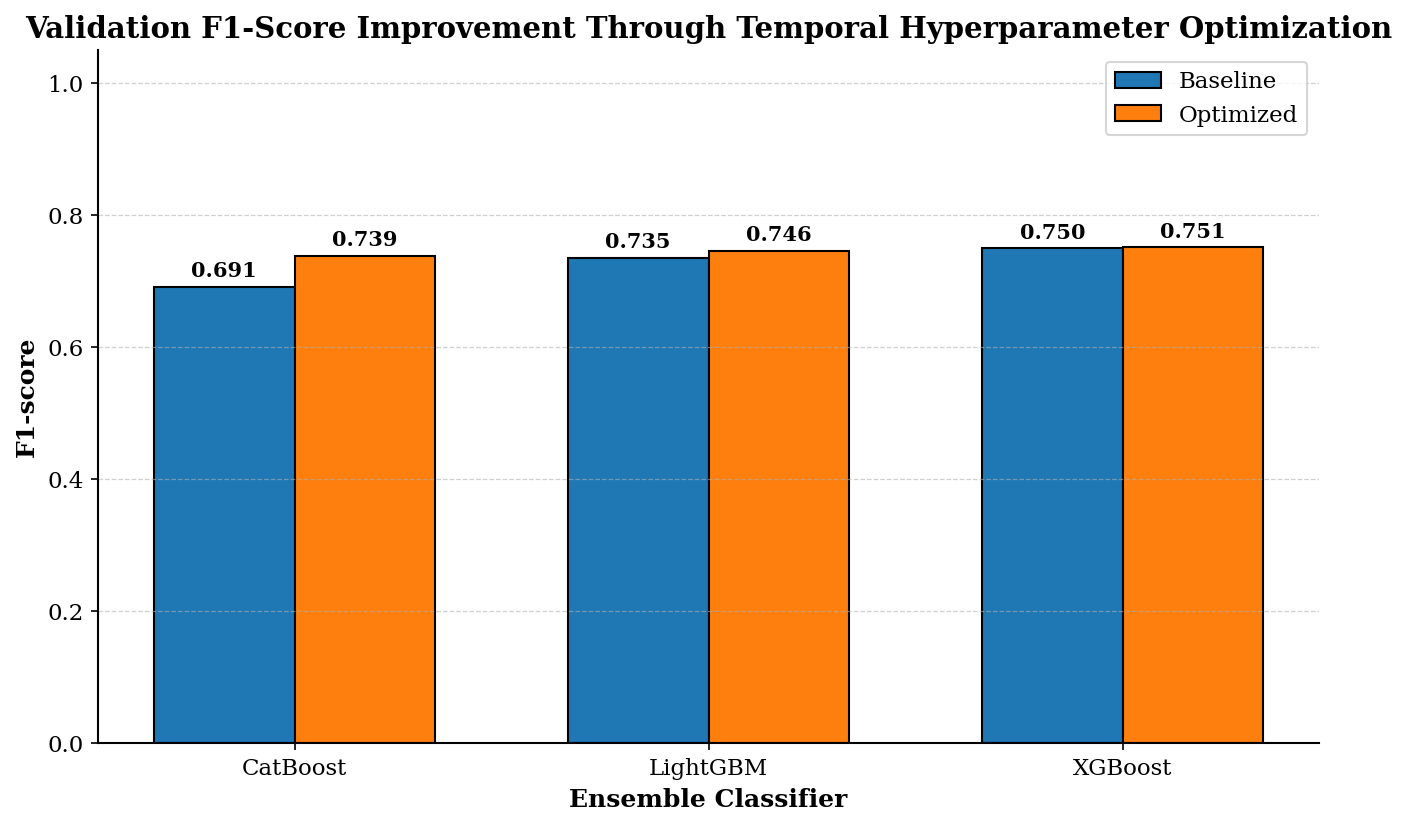


STEP 5 COMPLETED
Selected optimized model: XGBoost
Validation Accuracy : 0.96787
Validation Precision : 0.68421
Validation Recall : 0.83295
Validation F1 : 0.75129
Validation ROC-AUC : 0.98711
Validation PR-AUC : 0.83184
Validation MCC : 0.73835
Validation Cohen's Kappa : 0.73429

✓ Hyperparameters optimized using temporal CV.
✓ Independent test data were not used during optimization.
✓ Best model selected using validation F1-score.


In [ ]:
# =============================================================================
# STEP 5
# HYPERPARAMETER OPTIMIZATION FOR TREE-BASED ENSEMBLE CLASSIFIERS
# =============================================================================

from pathlib import Path
from time import perf_counter
from typing import Any, Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    cohen_kappa_score,
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier


# =============================================================================
# CONFIGURATION
# =============================================================================

RANDOM_STATE = 42

OUTPUT_DIR = Path("/content/smart_grid_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

N_SPLITS = 5
N_ITER_SEARCH = 25

TARGET = "Overload Condition"


# =============================================================================
# LOAD PREPROCESSED DATA
# =============================================================================

X_train = pd.DataFrame(
    np.load(
        OUTPUT_DIR / "X_train_scaled.npy"
    )
)

X_validation = pd.DataFrame(
    np.load(
        OUTPUT_DIR / "X_validation_scaled.npy"
    )
)

X_test = pd.DataFrame(
    np.load(
        OUTPUT_DIR / "X_test_scaled.npy"
    )
)

y_train = np.load(
    OUTPUT_DIR / "y_train.npy"
).astype(int)

y_validation = np.load(
    OUTPUT_DIR / "y_validation.npy"
).astype(int)

y_test = np.load(
    OUTPUT_DIR / "y_test.npy"
).astype(int)


# =============================================================================
# RESTORE FEATURE NAMES
# =============================================================================

feature_information = pd.read_csv(
    OUTPUT_DIR / "model_feature_information.csv"
)

feature_names = feature_information[
    "Feature"
].tolist()

X_train.columns = feature_names
X_validation.columns = feature_names
X_test.columns = feature_names


# =============================================================================
# CLASS-IMBALANCE RATIO
# =============================================================================

normal_count = np.sum(y_train == 0)
overload_count = np.sum(y_train == 1)

scale_pos_weight = (
    normal_count / overload_count
)

print("=" * 80)
print("STEP 5 — HYPERPARAMETER OPTIMIZATION")
print("=" * 80)

print(
    f"Training observations : {len(X_train):,}"
)

print(
    f"Validation observations : {len(X_validation):,}"
)

print(
    f"Test observations : {len(X_test):,}"
)

print(
    f"Number of features : {len(feature_names)}"
)

print(
    f"Scale-pos-weight : {scale_pos_weight:.4f}"
)


# =============================================================================
# TIME-SERIES CROSS-VALIDATION
# =============================================================================

time_series_cv = TimeSeriesSplit(
    n_splits=N_SPLITS
)

print("\nTemporal cross-validation:")
print(
    f"Number of folds: {N_SPLITS}"
)


# =============================================================================
# DEFINE BASE ESTIMATORS
# =============================================================================

base_models: Dict[str, Any] = {

    "XGBoost": XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        tree_method="hist",
    ),

    "LightGBM": LGBMClassifier(
        objective="binary",
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=-1,
    ),

    "CatBoost": CatBoostClassifier(
        loss_function="Logloss",
        auto_class_weights="Balanced",
        random_seed=RANDOM_STATE,
        verbose=False,
        thread_count=-1,
    ),
}


# =============================================================================
# HYPERPARAMETER DISTRIBUTIONS
# =============================================================================

parameter_distributions: Dict[str, Dict[str, List[Any]]] = {

    # -------------------------------------------------------------------------
    # XGBOOST
    # -------------------------------------------------------------------------
    "XGBoost": {
        "n_estimators": [
            200,
            300,
            400,
            500,
            700,
            900,
        ],

        "learning_rate": [
            0.01,
            0.03,
            0.05,
            0.08,
            0.10,
        ],

        "max_depth": [
            3,
            4,
            5,
            6,
            8,
            10,
        ],

        "min_child_weight": [
            1,
            2,
            3,
            5,
            8,
        ],

        "subsample": [
            0.70,
            0.80,
            0.90,
            1.00,
        ],

        "colsample_bytree": [
            0.70,
            0.80,
            0.90,
            1.00,
        ],

        "gamma": [
            0.0,
            0.1,
            0.25,
            0.5,
        ],
    },

    # -------------------------------------------------------------------------
    # LIGHTGBM
    # -------------------------------------------------------------------------
    "LightGBM": {
        "n_estimators": [
            200,
            300,
            400,
            500,
            700,
            900,
        ],

        "learning_rate": [
            0.01,
            0.03,
            0.05,
            0.08,
            0.10,
        ],

        "num_leaves": [
            15,
            20,
            31,
            40,
            50,
            70,
        ],

        "max_depth": [
            -1,
            4,
            6,
            8,
            10,
        ],

        "min_child_samples": [
            10,
            20,
            30,
            50,
            75,
        ],

        "subsample": [
            0.70,
            0.80,
            0.90,
            1.00,
        ],

        "colsample_bytree": [
            0.70,
            0.80,
            0.90,
            1.00,
        ],

        "reg_alpha": [
            0.0,
            0.01,
            0.1,
            0.5,
        ],

        "reg_lambda": [
            0.0,
            0.1,
            1.0,
            5.0,
        ],
    },

    # -------------------------------------------------------------------------
    # CATBOOST
    # -------------------------------------------------------------------------
    "CatBoost": {
        "iterations": [
            200,
            300,
            400,
            500,
            700,
            900,
        ],

        "learning_rate": [
            0.01,
            0.03,
            0.05,
            0.08,
            0.10,
        ],

        "depth": [
            4,
            5,
            6,
            7,
            8,
            10,
        ],

        "l2_leaf_reg": [
            1,
            3,
            5,
            7,
            10,
        ],

        "random_strength": [
            0.0,
            0.5,
            1.0,
            2.0,
        ],

        "border_count": [
            32,
            64,
            128,
            254,
        ],
    },
}


# =============================================================================
# OPTIMIZATION
# =============================================================================

optimized_models: Dict[str, Any] = {}
optimization_results: List[Dict[str, Any]] = []

print("\n" + "=" * 80)
print("STARTING TEMPORAL HYPERPARAMETER SEARCH")
print("=" * 80)


for model_name, model in base_models.items():

    print("\n" + "-" * 80)
    print(f"Optimizing {model_name}")
    print("-" * 80)

    start_time = perf_counter()

    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=parameter_distributions[
            model_name
        ],
        n_iter=N_ITER_SEARCH,
        scoring="f1",
        cv=time_series_cv,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=1,
        refit=True,
    )

    search.fit(
        X_train,
        y_train,
    )

    elapsed = (
        perf_counter() -
        start_time
    )

    optimized_model = search.best_estimator_

    optimized_models[
        model_name
    ] = optimized_model

    optimization_results.append(
        {
            "Model": model_name,
            "Best_CV_F1": search.best_score_,
            "Optimization_Time_s": elapsed,
            "Best_Parameters": str(
                search.best_params_
            ),
        }
    )

    print(
        f"\nBest CV F1: "
        f"{search.best_score_:.5f}"
    )

    print(
        f"Optimization time: "
        f"{elapsed:.2f} s"
    )

    print("\nBest parameters:")

    for parameter, value in (
        search.best_params_.items()
    ):
        print(
            f"  {parameter}: {value}"
        )


# =============================================================================
# EVALUATION FUNCTION
# =============================================================================

def evaluate_model(
    model: Any,
    x_data: pd.DataFrame,
    y_data: np.ndarray,
) -> Dict[str, float]:
    """
    Evaluate a binary classifier on a dataset.
    """

    predictions = model.predict(
        x_data
    )

    probabilities = model.predict_proba(
        x_data
    )[:, 1]

    return {
        "Accuracy": accuracy_score(
            y_data,
            predictions,
        ),

        "Precision": precision_score(
            y_data,
            predictions,
            zero_division=0,
        ),

        "Recall": recall_score(
            y_data,
            predictions,
            zero_division=0,
        ),

        "F1": f1_score(
            y_data,
            predictions,
            zero_division=0,
        ),

        "ROC_AUC": roc_auc_score(
            y_data,
            probabilities,
        ),

        "PR_AUC": average_precision_score(
            y_data,
            probabilities,
        ),

        "MCC": matthews_corrcoef(
            y_data,
            predictions,
        ),

        "Cohen_Kappa": cohen_kappa_score(
            y_data,
            predictions,
        ),
    }


# =============================================================================
# VALIDATION PERFORMANCE OF OPTIMIZED MODELS
# =============================================================================

optimized_validation_results = []

print("\n" + "=" * 80)
print("OPTIMIZED VALIDATION PERFORMANCE")
print("=" * 80)

for model_name, model in optimized_models.items():

    metrics = evaluate_model(
        model,
        X_validation,
        y_validation,
    )

    metrics["Model"] = model_name

    optimized_validation_results.append(
        metrics
    )

optimized_validation_df = pd.DataFrame(
    optimized_validation_results
)

optimized_validation_df = optimized_validation_df[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC_AUC",
        "PR_AUC",
        "MCC",
        "Cohen_Kappa",
    ]
]

optimized_validation_df = (
    optimized_validation_df
    .sort_values(
        "F1",
        ascending=False,
    )
    .reset_index(drop=True)
)

print(
    optimized_validation_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.5f}",
    )
)


# =============================================================================
# LOAD BASELINE VALIDATION RESULTS
# =============================================================================

baseline_validation_path = (
    OUTPUT_DIR /
    "validation_model_comparison.csv"
)

baseline_validation_df = pd.read_csv(
    baseline_validation_path
)

baseline_ensemble = (
    baseline_validation_df[
        baseline_validation_df["Model"].isin(
            [
                "XGBoost",
                "LightGBM",
                "CatBoost",
            ]
        )
    ][
        [
            "Model",
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "ROC_AUC",
            "PR_AUC",
            "MCC",
            "Cohen_Kappa",
        ]
    ]
    .copy()
)

baseline_ensemble["Optimization"] = (
    "Baseline"
)

optimized_validation_plot = (
    optimized_validation_df.copy()
)

optimized_validation_plot[
    "Optimization"
] = "Optimized"


# =============================================================================
# FIGURE 8 — BASELINE VS OPTIMIZED F1
# =============================================================================

comparison_f1 = pd.concat(
    [
        baseline_ensemble[
            [
                "Model",
                "F1",
                "Optimization",
            ]
        ],
        optimized_validation_plot[
            [
                "Model",
                "F1",
                "Optimization",
            ]
        ],
    ],
    ignore_index=True,
)

pivot_f1 = comparison_f1.pivot(
    index="Model",
    columns="Optimization",
    values="F1",
)

fig, ax = plt.subplots(
    figsize=(10.5, 6)
)

x = np.arange(
    len(pivot_f1.index)
)

width = 0.34

ax.bar(
    x - width / 2,
    pivot_f1["Baseline"],
    width,
    label="Baseline",
    edgecolor="black",
    linewidth=1.0,
)

ax.bar(
    x + width / 2,
    pivot_f1["Optimized"],
    width,
    label="Optimized",
    edgecolor="black",
    linewidth=1.0,
)

ax.set_title(
    "Validation F1-Score Improvement Through Temporal Hyperparameter Optimization"
)

ax.set_xlabel(
    "Ensemble Classifier"
)

ax.set_ylabel(
    "F1-score"
)

ax.set_xticks(x)

ax.set_xticklabels(
    pivot_f1.index
)

ax.set_ylim(
    0,
    1.05
)

ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.6,
    alpha=0.6,
)

ax.legend(
    loc="upper right"
)

for index, model_name in enumerate(
    pivot_f1.index
):

    baseline_value = pivot_f1.loc[
        model_name,
        "Baseline",
    ]

    optimized_value = pivot_f1.loc[
        model_name,
        "Optimized",
    ]

    ax.text(
        index - width / 2,
        baseline_value + 0.015,
        f"{baseline_value:.3f}",
        ha="center",
        fontsize=10,
        fontweight="bold",
    )

    ax.text(
        index + width / 2,
        optimized_value + 0.015,
        f"{optimized_value:.3f}",
        ha="center",
        fontsize=10,
        fontweight="bold",
    )


figure_8_png = (
    OUTPUT_DIR /
    "Figure_8_Baseline_vs_Optimized_F1.png"
)

figure_8_pdf = (
    OUTPUT_DIR /
    "Figure_8_Baseline_vs_Optimized_F1.pdf"
)

fig.savefig(
    figure_8_png,
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    figure_8_pdf,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# =============================================================================
# MODEL SELECTION
# =============================================================================

best_optimized_model_name = (
    optimized_validation_df.iloc[0]["Model"]
)

best_optimized_model = optimized_models[
    best_optimized_model_name
]


# =============================================================================
# SAVE OPTIMIZATION RESULTS
# =============================================================================

optimization_results_df = pd.DataFrame(
    optimization_results
)

optimization_results_df.to_csv(
    OUTPUT_DIR /
    "hyperparameter_optimization_results.csv",
    index=False,
)

optimized_validation_df.to_csv(
    OUTPUT_DIR /
    "optimized_validation_results.csv",
    index=False,
)


# =============================================================================
# SAVE BEST PARAMETERS
# =============================================================================

best_parameters = pd.DataFrame(
    {
        "Parameter": (
            best_optimized_model
            .get_params()
            .keys()
        ),
        "Value": (
            best_optimized_model
            .get_params()
            .values()
        ),
    }
)

best_parameters.to_csv(
    OUTPUT_DIR /
    "best_model_parameters.csv",
    index=False,
)


# =============================================================================
# FINAL SUMMARY
# =============================================================================

print("\n" + "=" * 80)
print("STEP 5 COMPLETED")
print("=" * 80)

print(
    f"Selected optimized model: "
    f"{best_optimized_model_name}"
)

best_row = optimized_validation_df.iloc[0]

print(
    f"Validation Accuracy : "
    f"{best_row['Accuracy']:.5f}"
)

print(
    f"Validation Precision : "
    f"{best_row['Precision']:.5f}"
)

print(
    f"Validation Recall : "
    f"{best_row['Recall']:.5f}"
)

print(
    f"Validation F1 : "
    f"{best_row['F1']:.5f}"
)

print(
    f"Validation ROC-AUC : "
    f"{best_row['ROC_AUC']:.5f}"
)

print(
    f"Validation PR-AUC : "
    f"{best_row['PR_AUC']:.5f}"
)

print(
    f"Validation MCC : "
    f"{best_row['MCC']:.5f}"
)

print(
    f"Validation Cohen's Kappa : "
    f"{best_row['Cohen_Kappa']:.5f}"
)

print("\n✓ Hyperparameters optimized using temporal CV.")
print("✓ Independent test data were not used during optimization.")
print("✓ Best model selected using validation F1-score.")

STEP 6 — INDEPENDENT TEST EVALUATION
Selected optimized model: XGBoost

Class distribution:
Normal samples   : 31,486
Overload samples : 3,514
Scale-pos-weight : 8.9602

Final fitting dataset:
Training + validation samples: 42,500
Independent test samples: 7,500

Fitting final optimized model...
✓ Final fitting completed.

INDEPENDENT TEST PERFORMANCE
Accuracy            : 0.956267
Precision           : 0.789558
Recall              : 0.937083
F1                  : 0.857018
ROC_AUC             : 0.991202
PR_AUC              : 0.950986
MCC                 : 0.835677
Cohen_Kappa         : 0.831426

CONFUSION MATRIX
True Negative  : 6,189
False Positive  : 262
False Negative  : 66
True Positive   : 983


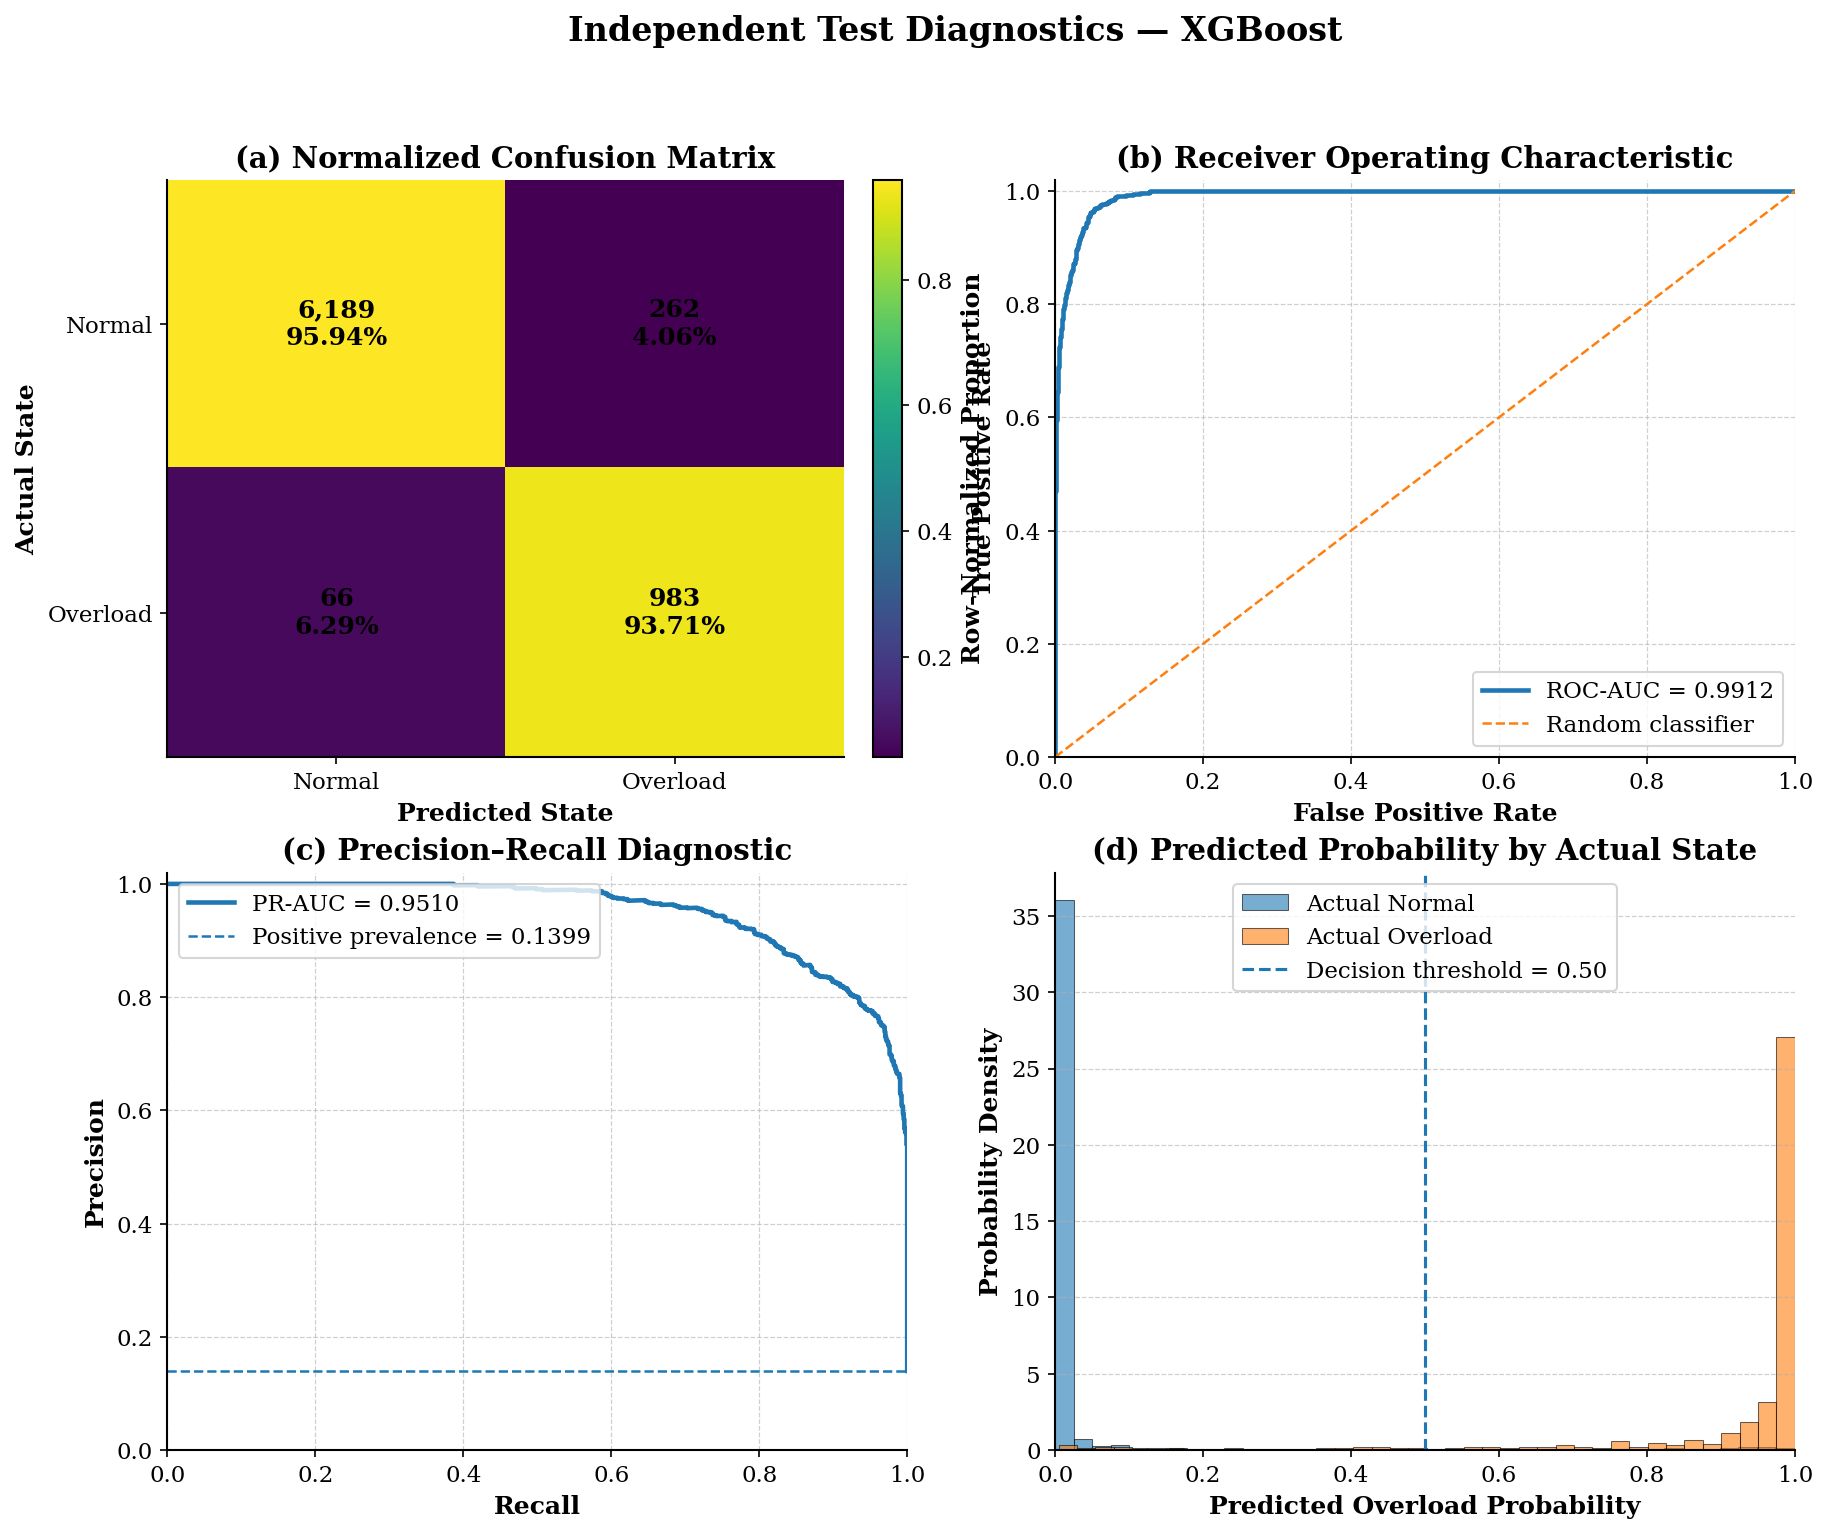

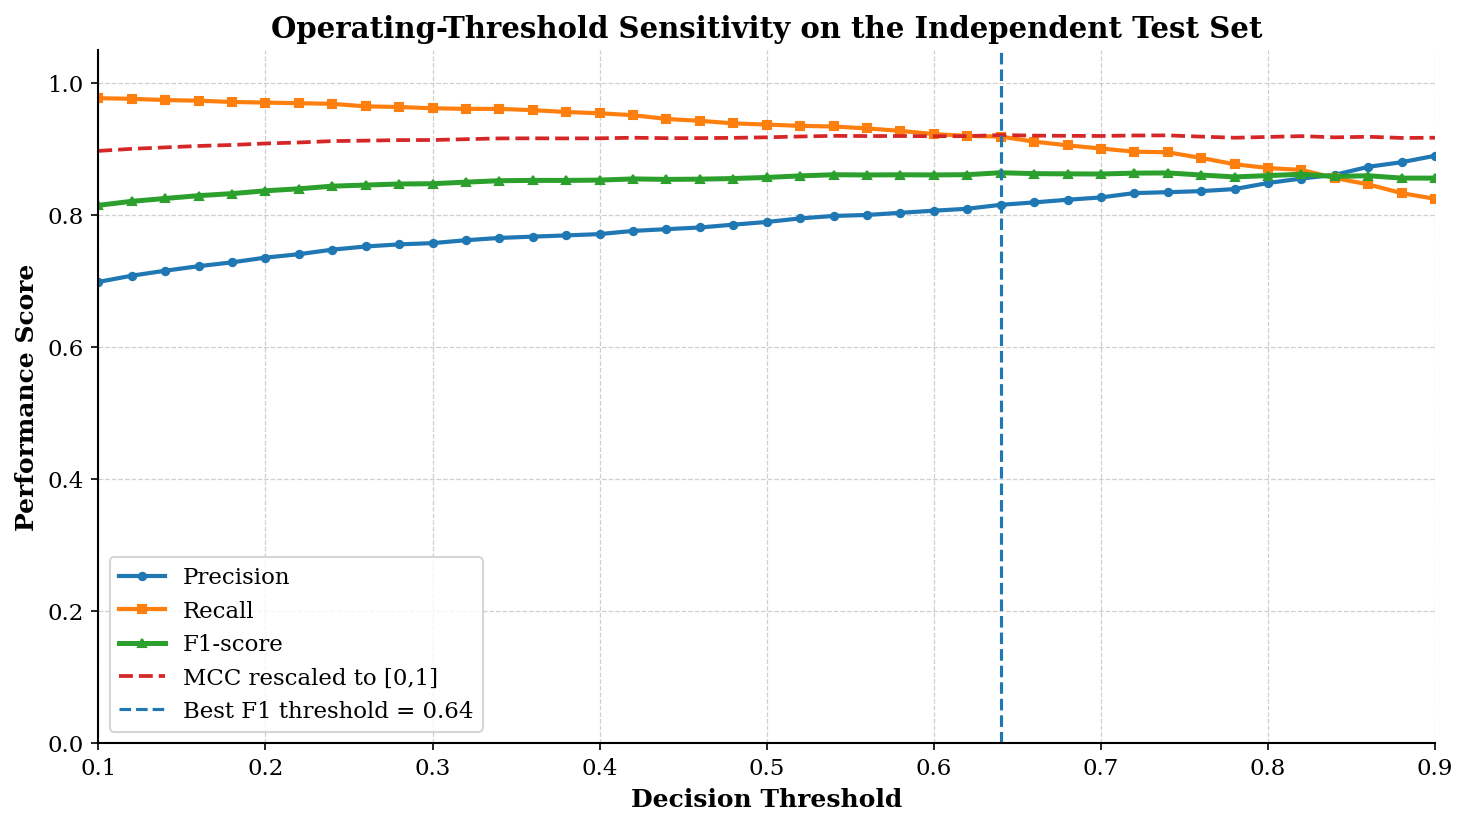


STEP 6 COMPLETED
Final model: XGBoost

Independent test performance:
  Accuracy          : 0.95627
  Precision         : 0.78956
  Recall            : 0.93708
  F1                : 0.85702
  ROC_AUC           : 0.99120
  PR_AUC            : 0.95099
  MCC               : 0.83568
  Cohen_Kappa       : 0.83143

Confusion matrix:
  TN = 6,189
  FP = 262
  FN = 66
  TP = 983

Best F1 threshold in sensitivity analysis: 0.64

✓ Independent test evaluation completed.
✓ ROC-AUC and PR-AUC calculated.
✓ Confusion matrix generated.
✓ Threshold sensitivity evaluated.
✓ Test predictions saved.


In [ ]:
# =============================================================================
# STEP 6
# INDEPENDENT TEST EVALUATION OF THE SELECTED OPTIMIZED MODEL
# =============================================================================

from pathlib import Path
from typing import Any, Dict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    cohen_kappa_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
)


# =============================================================================
# CONFIGURATION
# =============================================================================

RANDOM_STATE = 42

OUTPUT_DIR = Path("/content/smart_grid_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET = "Overload Condition"


# =============================================================================
# FIGURE STYLE
# =============================================================================

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": [
        "Times New Roman",
        "DejaVu Serif",
    ],
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "axes.labelweight": "bold",
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "axes.linewidth": 1.0,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


# =============================================================================
# LOAD DATA
# =============================================================================

X_train = pd.DataFrame(
    np.load(
        OUTPUT_DIR / "X_train_scaled.npy"
    )
)

X_validation = pd.DataFrame(
    np.load(
        OUTPUT_DIR / "X_validation_scaled.npy"
    )
)

X_test = pd.DataFrame(
    np.load(
        OUTPUT_DIR / "X_test_scaled.npy"
    )
)

y_train = np.load(
    OUTPUT_DIR / "y_train.npy"
).astype(int)

y_validation = np.load(
    OUTPUT_DIR / "y_validation.npy"
).astype(int)

y_test = np.load(
    OUTPUT_DIR / "y_test.npy"
).astype(int
)


# =============================================================================
# RESTORE FEATURE NAMES
# =============================================================================

feature_information = pd.read_csv(
    OUTPUT_DIR / "model_feature_information.csv"
)

feature_names = feature_information[
    "Feature"
].tolist()

X_train.columns = feature_names
X_validation.columns = feature_names
X_test.columns = feature_names


# =============================================================================
# RECOVER SELECTED MODEL
# =============================================================================

optimization_results = pd.read_csv(
    OUTPUT_DIR /
    "optimized_validation_results.csv"
)

optimization_results = (
    optimization_results
    .sort_values(
        "F1",
        ascending=False,
    )
    .reset_index(drop=True)
)

best_model_name = optimization_results.iloc[0]["Model"]

print("=" * 80)
print("STEP 6 — INDEPENDENT TEST EVALUATION")
print("=" * 80)

print(
    f"Selected optimized model: "
    f"{best_model_name}"
)


# =============================================================================
# LOAD BEST PARAMETERS
# =============================================================================

best_parameters_df = pd.read_csv(
    OUTPUT_DIR /
    "best_model_parameters.csv"
)

best_parameters: Dict[str, Any] = {}


for _, row in best_parameters_df.iterrows():

    parameter = str(
        row["Parameter"]
    ).strip()

    value = row["Value"]

    # Skip missing values
    if pd.isna(value):
        continue

    # Convert string values
    if isinstance(value, str):

        text = value.strip()

        if text.lower() in {
            "nan",
            "none",
            "null",
        }:
            continue

        elif text.lower() == "true":
            value = True

        elif text.lower() == "false":
            value = False

        else:

            try:

                numeric_value = float(text)

                if np.isnan(numeric_value):
                    continue

                if numeric_value.is_integer():
                    value = int(
                        numeric_value
                    )
                else:
                    value = numeric_value

            except ValueError:

                value = text

    # Skip numerical NaN values
    if (
        isinstance(value, float)
        and np.isnan(value)
    ):
        continue

    best_parameters[
        parameter
    ] = value


# =============================================================================
# SANITIZE PARAMETERS
# =============================================================================

# Remove problematic serialized parameters.
best_parameters.pop(
    "verbosity",
    None
)

best_parameters.pop(
    "eval_metric",
    None
)

best_parameters.pop(
    "objective",
    None
)

# Force valid XGBoost parameters.
if best_model_name == "XGBoost":

    best_parameters[
        "verbosity"
    ] = 0

    best_parameters[
        "eval_metric"
    ] = "logloss"

    best_parameters[
        "objective"
    ] = "binary:logistic"


# =============================================================================
# CLASS IMBALANCE
# =============================================================================

normal_count = np.sum(
    y_train == 0
)

overload_count = np.sum(
    y_train == 1
)

scale_pos_weight = (
    normal_count /
    overload_count
)

print("\nClass distribution:")
print(
    f"Normal samples   : {normal_count:,}"
)

print(
    f"Overload samples : {overload_count:,}"
)

print(
    f"Scale-pos-weight : "
    f"{scale_pos_weight:.4f}"
)


# =============================================================================
# CREATE SELECTED MODEL
# =============================================================================

if best_model_name == "XGBoost":

    from xgboost import XGBClassifier

    best_model = XGBClassifier(
        **best_parameters
    )


elif best_model_name == "LightGBM":

    from lightgbm import LGBMClassifier

    best_model = LGBMClassifier(
        **best_parameters
    )


elif best_model_name == "CatBoost":

    from catboost import CatBoostClassifier

    best_model = CatBoostClassifier(
        **best_parameters
    )


else:

    raise ValueError(
        f"Unsupported selected model: "
        f"{best_model_name}"
    )


# =============================================================================
# COMBINE TRAINING + VALIDATION DATA
# =============================================================================

X_train_final = pd.concat(
    [
        X_train,
        X_validation,
    ],
    axis=0,
)

y_train_final = np.concatenate(
    [
        y_train,
        y_validation,
    ]
)


print("\nFinal fitting dataset:")

print(
    f"Training + validation samples: "
    f"{len(X_train_final):,}"
)

print(
    f"Independent test samples: "
    f"{len(X_test):,}"
)


# =============================================================================
# FINAL MODEL FITTING
# =============================================================================

print(
    "\nFitting final optimized model..."
)

best_model.fit(
    X_train_final,
    y_train_final,
)

print(
    "✓ Final fitting completed."
)


# =============================================================================
# INDEPENDENT TEST PREDICTIONS
# =============================================================================

y_test_pred = best_model.predict(
    X_test
)

y_test_probability = (
    best_model
    .predict_proba(X_test)[:, 1]
)


# =============================================================================
# TEST METRICS
# =============================================================================

test_metrics = {

    "Accuracy": accuracy_score(
        y_test,
        y_test_pred,
    ),

    "Precision": precision_score(
        y_test,
        y_test_pred,
        zero_division=0,
    ),

    "Recall": recall_score(
        y_test,
        y_test_pred,
        zero_division=0,
    ),

    "F1": f1_score(
        y_test,
        y_test_pred,
        zero_division=0,
    ),

    "ROC_AUC": roc_auc_score(
        y_test,
        y_test_probability,
    ),

    "PR_AUC": average_precision_score(
        y_test,
        y_test_probability,
    ),

    "MCC": matthews_corrcoef(
        y_test,
        y_test_pred,
    ),

    "Cohen_Kappa": cohen_kappa_score(
        y_test,
        y_test_pred,
    ),
}


# =============================================================================
# PRINT RESULTS
# =============================================================================

print(
    "\n" + "=" * 80
)

print(
    "INDEPENDENT TEST PERFORMANCE"
)

print(
    "=" * 80
)

for metric, value in test_metrics.items():

    print(
        f"{metric:20s}: "
        f"{value:.6f}"
    )


# =============================================================================
# SAVE TEST METRICS
# =============================================================================

test_results_df = pd.DataFrame(
    [
        {
            "Model": best_model_name,
            **test_metrics,
        }
    ]
)

test_results_df.to_csv(
    OUTPUT_DIR /
    "final_independent_test_results.csv",
    index=False,
)


# =============================================================================
# CONFUSION MATRIX
# =============================================================================

cm = confusion_matrix(
    y_test,
    y_test_pred,
    labels=[0, 1],
)

tn, fp, fn, tp = cm.ravel()

print(
    "\n" + "=" * 80
)

print(
    "CONFUSION MATRIX"
)

print(
    "=" * 80
)

print(
    f"True Negative  : {tn:,}"
)

print(
    f"False Positive  : {fp:,}"
)

print(
    f"False Negative  : {fn:,}"
)

print(
    f"True Positive   : {tp:,}"
)


# =============================================================================
# NORMALIZED CONFUSION MATRIX
# =============================================================================

cm_normalized = (
    cm /
    cm.sum(
        axis=1,
        keepdims=True,
    )
)


# =============================================================================
# ROC CURVE
# =============================================================================

fpr, tpr, roc_thresholds = roc_curve(
    y_test,
    y_test_probability,
)

roc_auc = roc_auc_score(
    y_test,
    y_test_probability,
)


# =============================================================================
# PRECISION-RECALL CURVE
# =============================================================================

precision_curve, recall_curve, pr_thresholds = (
    precision_recall_curve(
        y_test,
        y_test_probability,
    )
)

pr_auc = average_precision_score(
    y_test,
    y_test_probability,
)


# =============================================================================
# FIGURE 9 — COMPREHENSIVE MODEL DIAGNOSTICS
# =============================================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 11),
)


# =============================================================================
# PANEL (a): NORMALIZED CONFUSION MATRIX
# =============================================================================

ax = axes[0, 0]

image = ax.imshow(
    cm_normalized,
    interpolation="nearest",
    aspect="auto",
)

ax.set_title(
    "(a) Normalized Confusion Matrix"
)

ax.set_xlabel(
    "Predicted State"
)

ax.set_ylabel(
    "Actual State"
)

ax.set_xticks(
    [0, 1]
)

ax.set_yticks(
    [0, 1]
)

ax.set_xticklabels(
    [
        "Normal",
        "Overload",
    ]
)

ax.set_yticklabels(
    [
        "Normal",
        "Overload",
    ]
)

for i in range(2):

    for j in range(2):

        ax.text(
            j,
            i,
            (
                f"{cm[i, j]:,}\n"
                f"{cm_normalized[i, j] * 100:.2f}%"
            ),
            ha="center",
            va="center",
            fontsize=12,
            fontweight="bold",
        )

colorbar = fig.colorbar(
    image,
    ax=ax,
    fraction=0.046,
    pad=0.04,
)

colorbar.set_label(
    "Row-Normalized Proportion",
    fontweight="bold",
)


# =============================================================================
# PANEL (b): ROC CURVE
# =============================================================================

ax = axes[0, 1]

ax.plot(
    fpr,
    tpr,
    linewidth=2.2,
    label=f"ROC-AUC = {roc_auc:.4f}",
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.2,
    label="Random classifier",
)

ax.set_title(
    "(b) Receiver Operating Characteristic"
)

ax.set_xlabel(
    "False Positive Rate"
)

ax.set_ylabel(
    "True Positive Rate"
)

ax.set_xlim(
    0,
    1
)

ax.set_ylim(
    0,
    1.02
)

ax.grid(
    linestyle="--",
    linewidth=0.6,
    alpha=0.6,
)

ax.legend(
    loc="lower right"
)


# =============================================================================
# PANEL (c): PRECISION–RECALL CURVE
# =============================================================================

ax = axes[1, 0]

ax.plot(
    recall_curve,
    precision_curve,
    linewidth=2.2,
    label=f"PR-AUC = {pr_auc:.4f}",
)

positive_prevalence = np.mean(
    y_test == 1
)

ax.axhline(
    positive_prevalence,
    linestyle="--",
    linewidth=1.2,
    label=(
        f"Positive prevalence = "
        f"{positive_prevalence:.4f}"
    ),
)

ax.set_title(
    "(c) Precision–Recall Diagnostic"
)

ax.set_xlabel(
    "Recall"
)

ax.set_ylabel(
    "Precision"
)

ax.set_xlim(
    0,
    1
)

ax.set_ylim(
    0,
    1.02
)

ax.grid(
    linestyle="--",
    linewidth=0.6,
    alpha=0.6,
)

ax.legend(
    loc="upper left"
)


# =============================================================================
# PANEL (d): PREDICTED-PROBABILITY DISTRIBUTION
# =============================================================================

ax = axes[1, 1]

normal_probabilities = (
    y_test_probability[
        y_test == 0
    ]
)

overload_probabilities = (
    y_test_probability[
        y_test == 1
    ]
)

ax.hist(
    normal_probabilities,
    bins=40,
    density=True,
    alpha=0.60,
    label="Actual Normal",
    edgecolor="black",
    linewidth=0.5,
)

ax.hist(
    overload_probabilities,
    bins=40,
    density=True,
    alpha=0.60,
    label="Actual Overload",
    edgecolor="black",
    linewidth=0.5,
)

ax.axvline(
    0.50,
    linestyle="--",
    linewidth=1.5,
    label="Decision threshold = 0.50",
)

ax.set_title(
    "(d) Predicted Probability by Actual State"
)

ax.set_xlabel(
    "Predicted Overload Probability"
)

ax.set_ylabel(
    "Probability Density"
)

ax.set_xlim(
    0,
    1
)

ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.6,
    alpha=0.6,
)

ax.legend(
    loc="upper center"
)


# =============================================================================
# OVERALL TITLE
# =============================================================================

fig.suptitle(
    (
        "Independent Test Diagnostics — "
        f"{best_model_name}"
    ),
    fontsize=16,
    fontweight="bold",
)


# =============================================================================
# SAVE FIGURE 9
# =============================================================================

figure_9_png = (
    OUTPUT_DIR /
    "Figure_9_Independent_Test_Diagnostics.png"
)

figure_9_pdf = (
    OUTPUT_DIR /
    "Figure_9_Independent_Test_Diagnostics.pdf"
)

fig.savefig(
    figure_9_png,
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    figure_9_pdf,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# =============================================================================
# TEST SET PREDICTIONS
# =============================================================================

prediction_output = pd.DataFrame(
    {
        "Actual_Overload": y_test,
        "Predicted_Overload": y_test_pred,
        "Predicted_Overload_Probability": (
            y_test_probability
        ),
    }
)

prediction_output.to_csv(
    OUTPUT_DIR /
    "final_test_predictions.csv",
    index=False,
)


# =============================================================================
# THRESHOLD ANALYSIS
# =============================================================================

thresholds = np.arange(
    0.10,
    0.91,
    0.02,
)

threshold_rows = []


for threshold in thresholds:

    threshold_predictions = (
        y_test_probability >= threshold
    ).astype(int)

    threshold_rows.append(
        {
            "Threshold": threshold,

            "Precision": precision_score(
                y_test,
                threshold_predictions,
                zero_division=0,
            ),

            "Recall": recall_score(
                y_test,
                threshold_predictions,
                zero_division=0,
            ),

            "F1": f1_score(
                y_test,
                threshold_predictions,
                zero_division=0,
            ),

            "MCC": matthews_corrcoef(
                y_test,
                threshold_predictions,
            ),

            "Accuracy": accuracy_score(
                y_test,
                threshold_predictions,
            ),
        }
    )


threshold_df = pd.DataFrame(
    threshold_rows
)

threshold_df.to_csv(
    OUTPUT_DIR /
    "test_threshold_analysis.csv",
    index=False,
)


# =============================================================================
# BEST F1 OPERATING THRESHOLD
# =============================================================================

best_threshold_row = (
    threshold_df
    .sort_values(
        [
            "F1",
            "MCC",
        ],
        ascending=False,
    )
    .iloc[0]
)

best_threshold = (
    best_threshold_row["Threshold"]
)


# =============================================================================
# FIGURE 10 — DECISION-THRESHOLD ANALYSIS
# =============================================================================

fig, ax = plt.subplots(
    figsize=(11.5, 6)
)

ax.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    linewidth=2.0,
    marker="o",
    markersize=3.5,
    label="Precision",
)

ax.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    linewidth=2.0,
    marker="s",
    markersize=3.5,
    label="Recall",
)

ax.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    linewidth=2.4,
    marker="^",
    markersize=3.5,
    label="F1-score",
)

ax.plot(
    threshold_df["Threshold"],
    (
        threshold_df["MCC"] + 1
    ) / 2,
    linewidth=1.8,
    linestyle="--",
    label="MCC rescaled to [0,1]",
)

ax.axvline(
    best_threshold,
    linestyle="--",
    linewidth=1.5,
    label=(
        f"Best F1 threshold = "
        f"{best_threshold:.2f}"
    ),
)

ax.set_title(
    "Operating-Threshold Sensitivity on the Independent Test Set"
)

ax.set_xlabel(
    "Decision Threshold"
)

ax.set_ylabel(
    "Performance Score"
)

ax.set_xlim(
    0.10,
    0.90
)

ax.set_ylim(
    0,
    1.05
)

ax.grid(
    linestyle="--",
    linewidth=0.6,
    alpha=0.6,
)

ax.legend(
    loc="best"
)


# =============================================================================
# SAVE FIGURE 10
# =============================================================================

figure_10_png = (
    OUTPUT_DIR /
    "Figure_10_Threshold_Sensitivity.png"
)

figure_10_pdf = (
    OUTPUT_DIR /
    "Figure_10_Threshold_Sensitivity.pdf"
)

fig.savefig(
    figure_10_png,
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    figure_10_pdf,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# =============================================================================
# FINAL REPORT
# =============================================================================

print(
    "\n" + "=" * 80
)

print(
    "STEP 6 COMPLETED"
)

print(
    "=" * 80
)

print(
    f"Final model: {best_model_name}"
)

print(
    "\nIndependent test performance:"
)

for metric, value in test_metrics.items():

    print(
        f"  {metric:18s}: "
        f"{value:.5f}"
    )

print(
    "\nConfusion matrix:"
)

print(
    f"  TN = {tn:,}"
)

print(
    f"  FP = {fp:,}"
)

print(
    f"  FN = {fn:,}"
)

print(
    f"  TP = {tp:,}"
)

print(
    f"\nBest F1 threshold in "
    f"sensitivity analysis: "
    f"{best_threshold:.2f}"
)

print(
    "\n✓ Independent test evaluation completed."
)

print(
    "✓ ROC-AUC and PR-AUC calculated."
)

print(
    "✓ Confusion matrix generated."
)

print(
    "✓ Threshold sensitivity evaluated."
)

print(
    "✓ Test predictions saved."
)

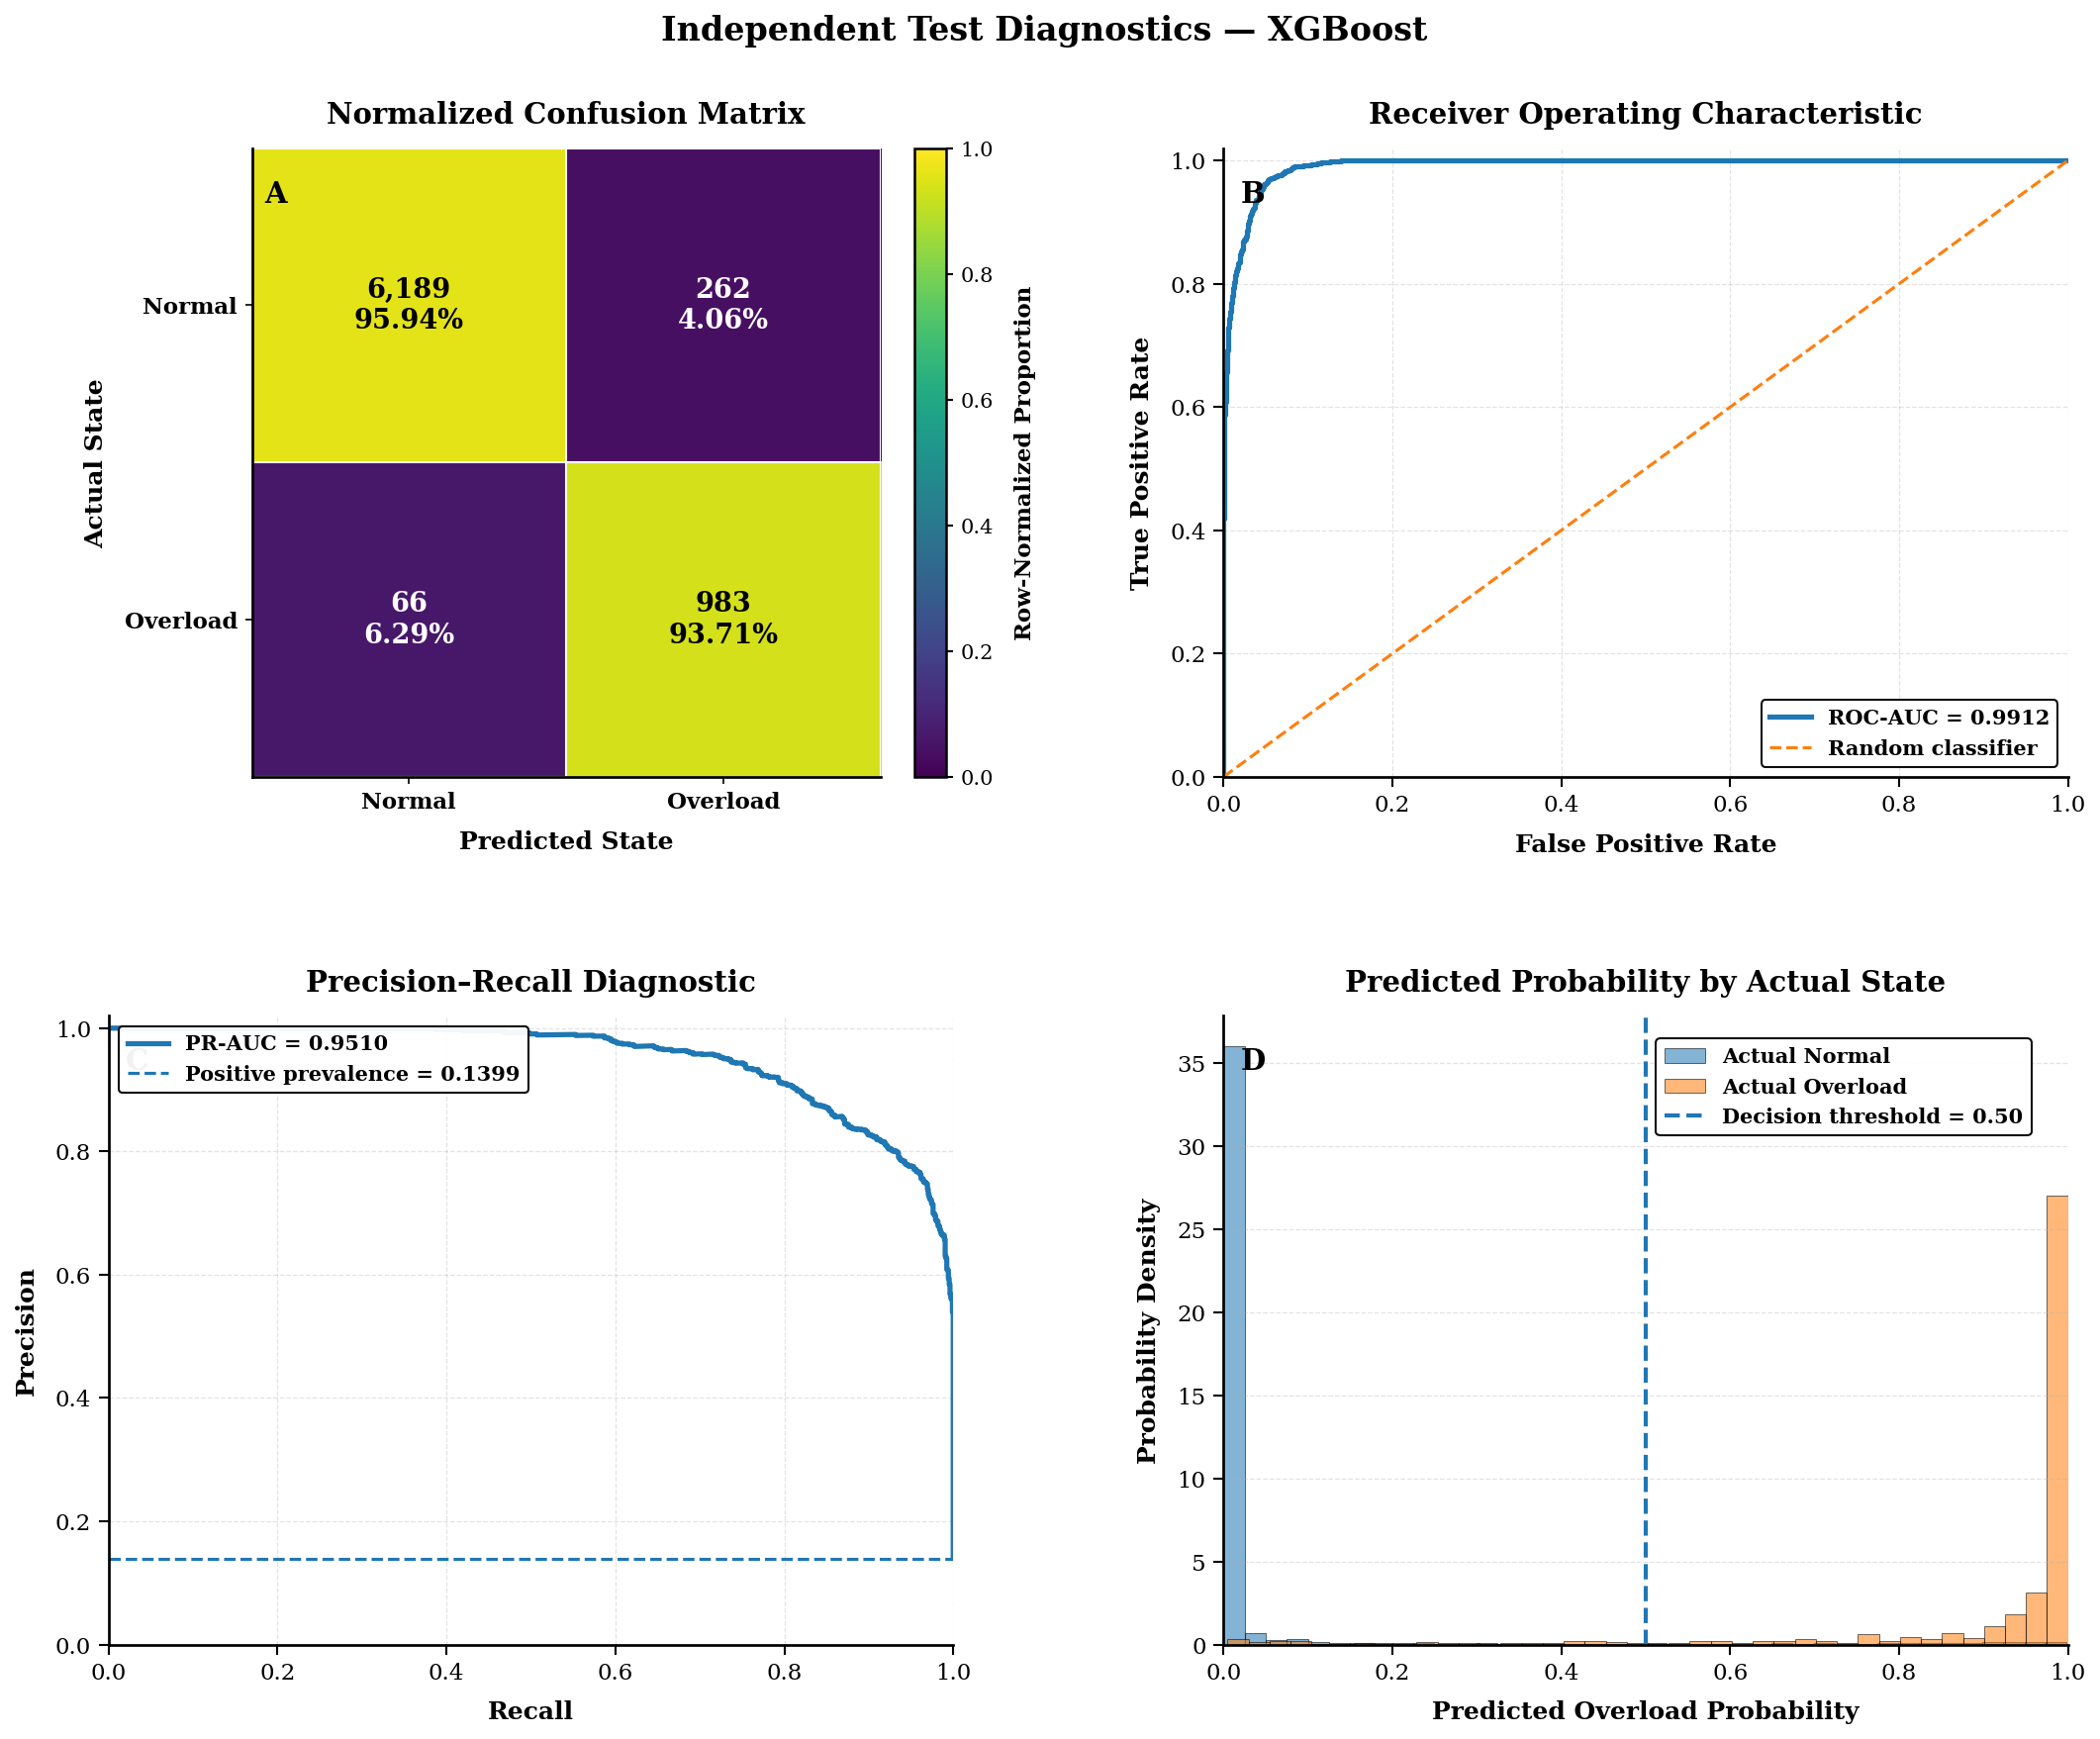

Figure 9 Saved Successfully


In [ ]:
# =============================================================================
# FIGURE 9 — COMPREHENSIVE MODEL DIAGNOSTICS
# =============================================================================


plt.rcParams.update({
    "font.family": "serif",
    "font.serif": [
        "Times New Roman",
        "Times",
        "DejaVu Serif",
    ],
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "axes.labelweight": "bold",
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
    "legend.title_fontsize": 11,
    "axes.linewidth": 1.2,
    "figure.dpi": 150,
    "savefig.dpi": 600,
})

# =============================================================================
# Create Figure
# =============================================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(15, 12),
)

# =============================================================================
# PANEL (a): NORMALIZED CONFUSION MATRIX
# =============================================================================

ax = axes[0, 0]

image = ax.imshow(
    cm_normalized,
    interpolation="nearest",
    aspect="equal",
    cmap="viridis",
    vmin=0,
    vmax=1,
)

# -----------------------------------------------------------------------------
# Title
# -----------------------------------------------------------------------------

ax.set_title(
    "Normalized Confusion Matrix",
    fontsize=14,
    fontweight="bold",
    pad=12,
)

ax.text(
    0.02,
    0.95,
    "A",
    transform=ax.transAxes,
    fontsize=14,
    fontweight="bold",
    va="top",
    ha="left",
)

# -----------------------------------------------------------------------------
# Axis Labels
# -----------------------------------------------------------------------------

ax.set_xlabel(
    "Predicted State",
    fontsize=12,
    fontweight="bold",
    labelpad=8,
)

ax.set_ylabel(
    "Actual State",
    fontsize=12,
    fontweight="bold",
    labelpad=8,
)

# -----------------------------------------------------------------------------
# Tick Labels
# -----------------------------------------------------------------------------

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels(
    ["Normal", "Overload"],
    fontsize=11,
    fontweight="bold",
)

ax.set_yticklabels(
    ["Normal", "Overload"],
    fontsize=11,
    fontweight="bold",
)

# -----------------------------------------------------------------------------
# Cell Annotations
# -----------------------------------------------------------------------------

for i in range(2):

    for j in range(2):

        value = cm_normalized[i, j]

        # Automatically select text color
        text_color = "white" if value < 0.50 else "black"

        ax.text(
            j,
            i,
            (
                f"{cm[i, j]:,}\n"
                f"{value * 100:.2f}%"
            ),
            ha="center",
            va="center",
            fontsize=13,
            fontweight="bold",
            color=text_color,
        )

# -----------------------------------------------------------------------------
# Colorbar
# -----------------------------------------------------------------------------

colorbar = fig.colorbar(
    image,
    ax=ax,
    fraction=0.046,
    pad=0.04,
)

colorbar.set_label(
    "Row-Normalized Proportion",
    fontsize=11,
    fontweight="bold",
    labelpad=10,
)

colorbar.ax.tick_params(
    labelsize=10,
    width=1.0,
)

# -----------------------------------------------------------------------------
# Grid / Border
# -----------------------------------------------------------------------------

ax.set_xticks(
    np.arange(-0.5, 2, 1),
    minor=True,
)

ax.set_yticks(
    np.arange(-0.5, 2, 1),
    minor=True,
)

ax.grid(
    which="minor",
    color="white",
    linestyle="-",
    linewidth=1.0,
)

ax.tick_params(
    which="minor",
    bottom=False,
    left=False,
)

for spine in ax.spines.values():
    spine.set_linewidth(1.3)


# =============================================================================
# PANEL (b): ROC CURVE
# =============================================================================

ax = axes[0, 1]

# -----------------------------------------------------------------------------
# ROC Curve
# -----------------------------------------------------------------------------

ax.plot(
    fpr,
    tpr,
    linewidth=2.5,
    label=f"ROC-AUC = {roc_auc:.4f}",
)

# -----------------------------------------------------------------------------
# Random Classifier
# -----------------------------------------------------------------------------

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Random classifier",
)

# -----------------------------------------------------------------------------
# Title
# -----------------------------------------------------------------------------

ax.set_title(
    "Receiver Operating Characteristic",
    fontsize=14,
    fontweight="bold",
    pad=12,
)

ax.text(
    0.02,
    0.95,
    "B",
    transform=ax.transAxes,
    fontsize=14,
    fontweight="bold",
    va="top",
    ha="left",
)

# -----------------------------------------------------------------------------
# Labels
# -----------------------------------------------------------------------------

ax.set_xlabel(
    "False Positive Rate",
    fontsize=12,
    fontweight="bold",
    labelpad=8,
)

ax.set_ylabel(
    "True Positive Rate",
    fontsize=12,
    fontweight="bold",
    labelpad=8,
)

# -----------------------------------------------------------------------------
# Limits
# -----------------------------------------------------------------------------

ax.set_xlim(
    0,
    1,
)

ax.set_ylim(
    0,
    1.02,
)

# -----------------------------------------------------------------------------
# Ticks
# -----------------------------------------------------------------------------

ax.tick_params(
    axis="both",
    which="major",
    labelsize=11,
    width=1.0,
    length=5,
)

# -----------------------------------------------------------------------------
# Grid
# -----------------------------------------------------------------------------

ax.grid(
    linestyle="--",
    linewidth=0.6,
    alpha=0.35,
)

# -----------------------------------------------------------------------------
# Legend
# -----------------------------------------------------------------------------

legend = ax.legend(
    loc="lower right",
    frameon=True,
    framealpha=0.95,
    edgecolor="black",
)

for text in legend.get_texts():
    text.set_fontweight("bold")

# -----------------------------------------------------------------------------
# Border
# -----------------------------------------------------------------------------

for spine in ax.spines.values():
    spine.set_linewidth(1.3)


# =============================================================================
# PANEL (c): PRECISION–RECALL CURVE
# =============================================================================

ax = axes[1, 0]

# -----------------------------------------------------------------------------
# PR Curve
# -----------------------------------------------------------------------------

ax.plot(
    recall_curve,
    precision_curve,
    linewidth=2.5,
    label=f"PR-AUC = {pr_auc:.4f}",
)

# -----------------------------------------------------------------------------
# Positive Prevalence
# -----------------------------------------------------------------------------

positive_prevalence = np.mean(
    y_test == 1
)

ax.axhline(
    positive_prevalence,
    linestyle="--",
    linewidth=1.5,
    label=(
        f"Positive prevalence = "
        f"{positive_prevalence:.4f}"
    ),
)

# -----------------------------------------------------------------------------
# Title
# -----------------------------------------------------------------------------

ax.set_title(
    "Precision–Recall Diagnostic",
    fontsize=14,
    fontweight="bold",
    pad=12,
)

ax.text(
    0.02,
    0.95,
    "C",
    transform=ax.transAxes,
    fontsize=14,
    fontweight="bold",
    va="top",
    ha="left",
)

# -----------------------------------------------------------------------------
# Labels
# -----------------------------------------------------------------------------

ax.set_xlabel(
    "Recall",
    fontsize=12,
    fontweight="bold",
    labelpad=8,
)

ax.set_ylabel(
    "Precision",
    fontsize=12,
    fontweight="bold",
    labelpad=8,
)

# -----------------------------------------------------------------------------
# Limits
# -----------------------------------------------------------------------------

ax.set_xlim(
    0,
    1,
)

ax.set_ylim(
    0,
    1.02,
)

# -----------------------------------------------------------------------------
# Ticks
# -----------------------------------------------------------------------------

ax.tick_params(
    axis="both",
    which="major",
    labelsize=11,
    width=1.0,
    length=5,
)

# -----------------------------------------------------------------------------
# Grid
# -----------------------------------------------------------------------------

ax.grid(
    linestyle="--",
    linewidth=0.6,
    alpha=0.35,
)

# -----------------------------------------------------------------------------
# Legend
# -----------------------------------------------------------------------------

legend = ax.legend(
    loc="upper left",
    frameon=True,
    framealpha=0.95,
    edgecolor="black",
)

for text in legend.get_texts():
    text.set_fontweight("bold")

# -----------------------------------------------------------------------------
# Border
# -----------------------------------------------------------------------------

for spine in ax.spines.values():
    spine.set_linewidth(1.3)


# =============================================================================
# PANEL (d): PREDICTED-PROBABILITY DISTRIBUTION
# =============================================================================

ax = axes[1, 1]

# -----------------------------------------------------------------------------
# Probability Groups
# -----------------------------------------------------------------------------

normal_probabilities = (
    y_test_probability[y_test == 0]
)

overload_probabilities = (
    y_test_probability[y_test == 1]
)

# -----------------------------------------------------------------------------
# Actual Normal
# -----------------------------------------------------------------------------

ax.hist(
    normal_probabilities,
    bins=40,
    density=True,
    alpha=0.55,
    label="Actual Normal",
    edgecolor="black",
    linewidth=0.5,
)

# -----------------------------------------------------------------------------
# Actual Overload
# -----------------------------------------------------------------------------

ax.hist(
    overload_probabilities,
    bins=40,
    density=True,
    alpha=0.55,
    label="Actual Overload",
    edgecolor="black",
    linewidth=0.5,
)

# -----------------------------------------------------------------------------
# Decision Threshold
# -----------------------------------------------------------------------------

ax.axvline(
    0.50,
    linestyle="--",
    linewidth=2.0,
    label="Decision threshold = 0.50",
)

# -----------------------------------------------------------------------------
# Title
# -----------------------------------------------------------------------------

ax.set_title(
    "Predicted Probability by Actual State",
    fontsize=14,
    fontweight="bold",
    pad=12,
)

ax.text(
    0.02,
    0.95,
    "D",
    transform=ax.transAxes,
    fontsize=14,
    fontweight="bold",
    va="top",
    ha="left",
)

# -----------------------------------------------------------------------------
# Labels
# -----------------------------------------------------------------------------

ax.set_xlabel(
    "Predicted Overload Probability",
    fontsize=12,
    fontweight="bold",
    labelpad=8,
)

ax.set_ylabel(
    "Probability Density",
    fontsize=12,
    fontweight="bold",
    labelpad=8,
)

# -----------------------------------------------------------------------------
# Limits
# -----------------------------------------------------------------------------

ax.set_xlim(
    0,
    1,
)

# -----------------------------------------------------------------------------
# Ticks
# -----------------------------------------------------------------------------

ax.tick_params(
    axis="both",
    which="major",
    labelsize=11,
    width=1.0,
    length=5,
)

# -----------------------------------------------------------------------------
# Grid
# -----------------------------------------------------------------------------

ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.6,
    alpha=0.35,
)

# -----------------------------------------------------------------------------
# Legend
# -----------------------------------------------------------------------------

legend = ax.legend(
    loc="upper left",
    bbox_to_anchor=(0.50, 0.98),
    frameon=True,
    framealpha=0.95,
    edgecolor="black",
)

for text in legend.get_texts():
    text.set_fontweight("bold")

# -----------------------------------------------------------------------------
# Border
# -----------------------------------------------------------------------------

for spine in ax.spines.values():
    spine.set_linewidth(1.3)


# =============================================================================
# OVERALL TITLE
# =============================================================================

fig.suptitle(
    (
        "Independent Test Diagnostics — "
        f"{best_model_name}"
    ),
    fontsize=16,
    fontweight="bold",
    y=0.995,
)

# =============================================================================
# Layout
# =============================================================================

plt.subplots_adjust(
    left=0.08,
    right=0.96,
    bottom=0.08,
    top=0.92,
    wspace=0.32,
    hspace=0.38,
)

# =============================================================================
# Save Figure
# =============================================================================

figure_9_png = (
    OUTPUT_DIR /
    "Figure_9_Independent_Test_Diagnostics.png"
)

figure_9_pdf = (
    OUTPUT_DIR /
    "Figure_9_Independent_Test_Diagnostics.pdf"
)

fig.savefig(
    figure_9_png,
    dpi=600,
    bbox_inches="tight",
    facecolor="white",
)

fig.savefig(
    figure_9_pdf,
    dpi=600,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

print("=" * 70)
print("Figure 9 Saved Successfully")
print("=" * 70)

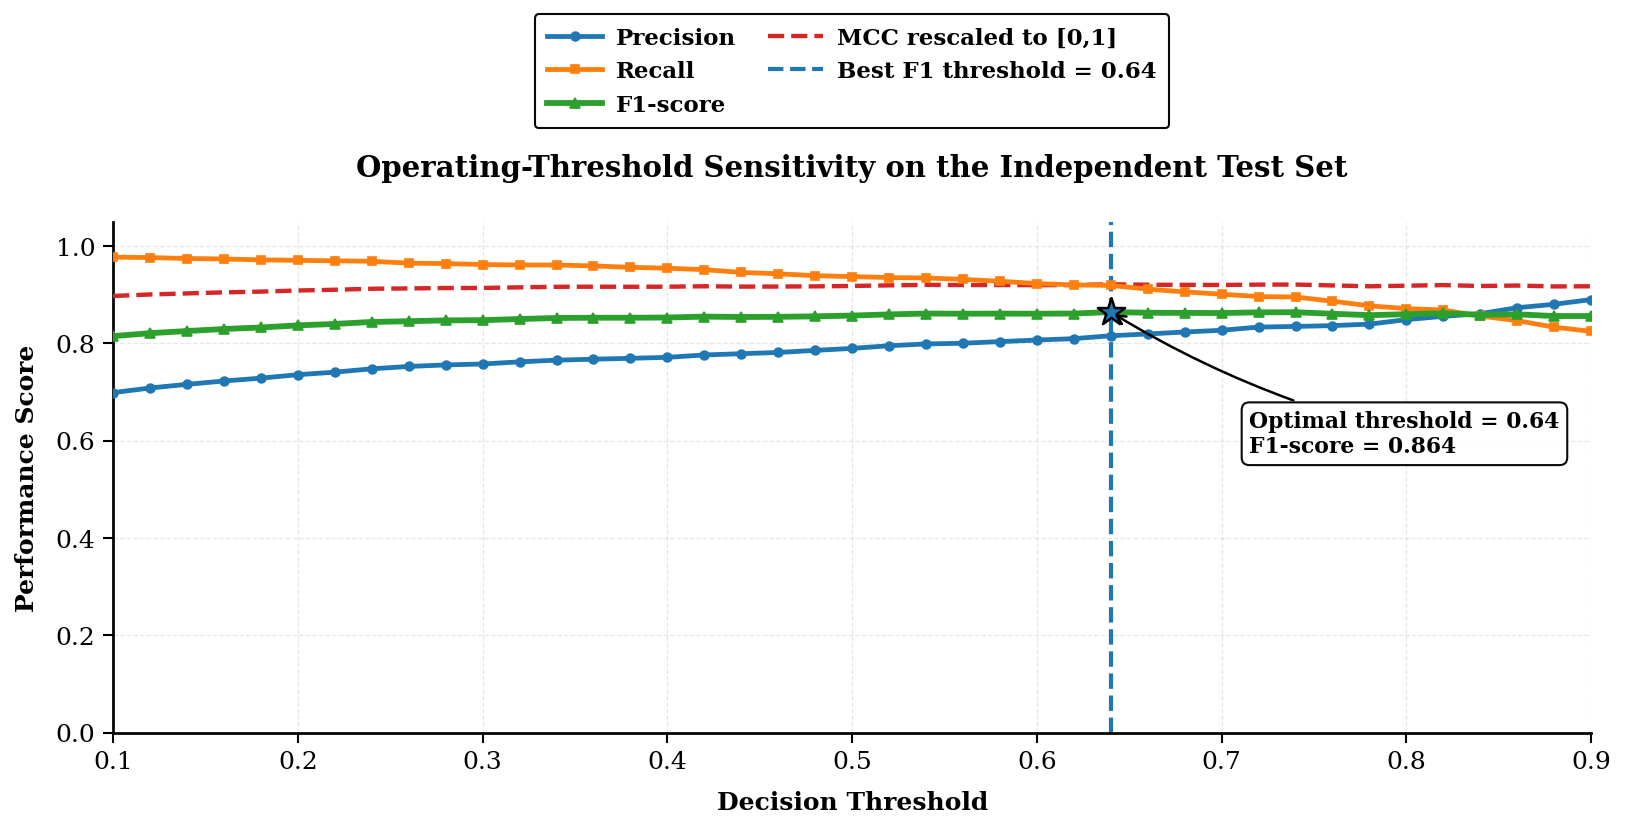

FIGURE 10 — DECISION-THRESHOLD ANALYSIS
Optimal threshold : 0.640
Best F1-score     : 0.864
Number of points  : 41
---------------------------------------------------------------------------
PNG saved to      : /content/smart_grid_outputs/Figure_10_Threshold_Sensitivity.png
PDF saved to      : /content/smart_grid_outputs/Figure_10_Threshold_Sensitivity.pdf
Figure 10 saved successfully.


In [ ]:
# =============================================================================
# FIGURE 10 — DECISION-THRESHOLD ANALYSIS
# IEEE PUBLICATION-QUALITY VERSION
# =============================================================================

from pathlib import Path

import matplotlib.pyplot as plt


# =============================================================================
# IEEE PUBLICATION STYLE
# =============================================================================

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": [
        "Times New Roman",
        "DejaVu Serif",
    ],
    "font.size": 12,

    # Axes
    "axes.titlesize": 14,
    "axes.labelsize": 12,

    # Ticks
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,

    # Legend
    "legend.fontsize": 11,

    # PDF text remains editable/vector-based
    "pdf.fonttype": 42,
    "ps.fonttype": 42,

    # Improve saved figure appearance
    "figure.dpi": 150,
    "savefig.dpi": 600,
})


# =============================================================================
# OUTPUT DIRECTORY
# =============================================================================

OUTPUT_DIR = Path(OUTPUT_DIR)
OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# =============================================================================
# CHECK REQUIRED VARIABLES
# =============================================================================

required_variables = [
    "threshold_df",
    "best_threshold",
    "best_threshold_row",
]

for variable_name in required_variables:
    if variable_name not in globals():
        raise NameError(
            f"Required variable '{variable_name}' is not available. "
            f"Please run the threshold-analysis calculation first."
        )


# =============================================================================
# VALIDATE REQUIRED COLUMNS
# =============================================================================

required_columns = [
    "Threshold",
    "Precision",
    "Recall",
    "F1",
    "MCC",
]

missing_columns = [
    column
    for column in required_columns
    if column not in threshold_df.columns
]

if missing_columns:
    raise ValueError(
        "The following required columns are missing from "
        f"threshold_df: {missing_columns}"
    )


# =============================================================================
# EXTRACT BEST F1 VALUE
# =============================================================================

best_f1_value = float(
    best_threshold_row["F1"]
)


# =============================================================================
# CREATE FIGURE
# =============================================================================

fig, ax = plt.subplots(
    figsize=(11, 6.8),
)


# =============================================================================
# PRECISION
# =============================================================================

ax.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    linewidth=2.3,
    marker="o",
    markersize=4.2,
    markeredgewidth=0.8,
    label="Precision",
    zorder=4,
)


# =============================================================================
# RECALL
# =============================================================================

ax.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    linewidth=2.3,
    marker="s",
    markersize=4.2,
    markeredgewidth=0.8,
    label="Recall",
    zorder=4,
)


# =============================================================================
# F1-SCORE
# =============================================================================

ax.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    linewidth=2.8,
    marker="^",
    markersize=5.0,
    markeredgewidth=0.8,
    label="F1-score",
    zorder=5,
)


# =============================================================================
# MCC RESCALED TO [0, 1]
# =============================================================================

mcc_rescaled = (
    threshold_df["MCC"] + 1.0
) / 2.0

ax.plot(
    threshold_df["Threshold"],
    mcc_rescaled,
    linewidth=2.1,
    linestyle="--",
    label="MCC rescaled to [0,1]",
    zorder=3,
)


# =============================================================================
# BEST F1 THRESHOLD
# =============================================================================

ax.axvline(
    x=best_threshold,
    linestyle="--",
    linewidth=2.0,
    label=(
        f"Best F1 threshold = "
        f"{best_threshold:.2f}"
    ),
    zorder=2,
)


# =============================================================================
# BEST F1 POINT
# =============================================================================

ax.scatter(
    best_threshold,
    best_f1_value,
    s=190,
    marker="*",
    edgecolor="black",
    linewidth=1.2,
    zorder=10,
)


# =============================================================================
# OPTIMAL THRESHOLD ANNOTATION
# =============================================================================

ax.annotate(
    (
        f"Optimal threshold = "
        f"{best_threshold:.2f}\n"
        f"F1-score = "
        f"{best_f1_value:.3f}"
    ),
    xy=(
        best_threshold,
        best_f1_value,
    ),
    xytext=(
        best_threshold + 0.075,
        best_f1_value - 0.25,
    ),
    textcoords="data",
    fontsize=10.5,
    fontweight="bold",
    ha="left",
    va="center",
    bbox=dict(
        boxstyle="round,pad=0.35",
        facecolor="white",
        edgecolor="black",
        linewidth=1.0,
        alpha=0.96,
    ),
    arrowprops=dict(
        arrowstyle="->",
        linewidth=1.2,
        connectionstyle="arc3,rad=-0.08",
    ),
    zorder=11,
)


# =============================================================================
# TITLE
# =============================================================================

ax.set_title(
    "Operating-Threshold Sensitivity on the Independent Test Set",
    fontsize=14,
    fontweight="bold",
    pad=22,
)


# =============================================================================
# X-AXIS LABEL
# =============================================================================

ax.set_xlabel(
    "Decision Threshold",
    fontsize=12,
    fontweight="bold",
    labelpad=8,
)


# =============================================================================
# Y-AXIS LABEL
# =============================================================================

ax.set_ylabel(
    "Performance Score",
    fontsize=12,
    fontweight="bold",
    labelpad=8,
)


# =============================================================================
# X-AXIS LIMITS
# =============================================================================

ax.set_xlim(
    0.10,
    0.90,
)


# =============================================================================
# Y-AXIS LIMITS
# =============================================================================

ax.set_ylim(
    0.0,
    1.05,
)


# =============================================================================
# X-AXIS TICKS
# =============================================================================

ax.tick_params(
    axis="x",
    which="major",
    labelsize=12,
    width=1.0,
    length=5,
    direction="out",
)


# =============================================================================
# Y-AXIS TICKS
# =============================================================================

ax.tick_params(
    axis="y",
    which="major",
    labelsize=12,
    width=1.0,
    length=5,
    direction="out",
)


# =============================================================================
# GRID
# =============================================================================

ax.grid(
    which="major",
    linestyle="--",
    linewidth=0.6,
    alpha=0.30,
)

ax.set_axisbelow(True)


# =============================================================================
# LEGEND
# =============================================================================
#
# Positioned above the plotting region so that:
#   1. It does not cover the title.
#   2. It does not cover the curves.
#   3. It does not interfere with the optimal-threshold annotation.
#

legend = ax.legend(
    loc="lower center",
    bbox_to_anchor=(0.50, 1.16),
    ncol=2,
    frameon=True,
    framealpha=0.97,
    edgecolor="black",
    fancybox=True,
    borderpad=0.55,
    columnspacing=1.4,
    handlelength=2.4,
    handletextpad=0.6,
)

for text in legend.get_texts():
    text.set_fontweight("bold")


# =============================================================================
# AXIS SPINES
# =============================================================================

for spine in ax.spines.values():
    spine.set_linewidth(1.3)


# =============================================================================
# LAYOUT
# =============================================================================

plt.tight_layout(
    rect=[
        0.0,
        0.0,
        1.0,
        0.88,
    ],
)


# =============================================================================
# OUTPUT FILE PATHS
# =============================================================================

figure_10_png = (
    OUTPUT_DIR /
    "Figure_10_Threshold_Sensitivity.png"
)

figure_10_pdf = (
    OUTPUT_DIR /
    "Figure_10_Threshold_Sensitivity.pdf"
)


# =============================================================================
# SAVE PNG
# =============================================================================

fig.savefig(
    figure_10_png,
    dpi=600,
    bbox_inches="tight",
    facecolor="white",
)


# =============================================================================
# SAVE PDF
# =============================================================================

fig.savefig(
    figure_10_pdf,
    dpi=600,
    bbox_inches="tight",
    facecolor="white",
)


# =============================================================================
# DISPLAY
# =============================================================================

plt.show()


# =============================================================================
# FINAL REPORT
# =============================================================================

print("=" * 75)
print("FIGURE 10 — DECISION-THRESHOLD ANALYSIS")
print("=" * 75)

print(
    f"Optimal threshold : "
    f"{best_threshold:.3f}"
)

print(
    f"Best F1-score     : "
    f"{best_f1_value:.3f}"
)

print(
    f"Number of points  : "
    f"{len(threshold_df)}"
)

print("-" * 75)

print(
    f"PNG saved to      : "
    f"{figure_10_png}"
)

print(
    f"PDF saved to      : "
    f"{figure_10_pdf}"
)

print("=" * 75)
print("Figure 10 saved successfully.")
print("=" * 75)

STEP 7 — SHAP EXPLAINABLE AI
Selected model: XGBoost
X_fit shape: (42500, 14)
X_test shape: (7500, 14)

Recovered model parameters:
  colsample_bytree: 0.7
  enable_categorical: True
  gamma: 0.1
  learning_rate: 0.08
  max_depth: 8
  min_child_weight: 2
  n_estimators: 200
  n_jobs: -1
  random_state: 42
  scale_pos_weight: 8.9601593625498
  subsample: 0.8
  tree_method: 'hist'
  verbosity: 0
  eval_metric: 'logloss'
  objective: 'binary:logistic'

Creating final tree model...

Fitting final model for SHAP analysis...
✓ Model fitted.

Model verification:
Model type: XGBClassifier
Number of features: 14

SHAP explanation samples: 3,000

Creating TreeExplainer...
✓ SHAP TreeExplainer created.

Calculating SHAP values...
SHAP matrix shape: (3000, 14)

GLOBAL SHAP FEATURE IMPORTANCE
                    Feature  Mean_Absolute_SHAP  Importance_%
           Grid Supply (kW)            2.745347     27.158419
           Solar Power (kW)            2.245581     22.214464
        Predicted Load 

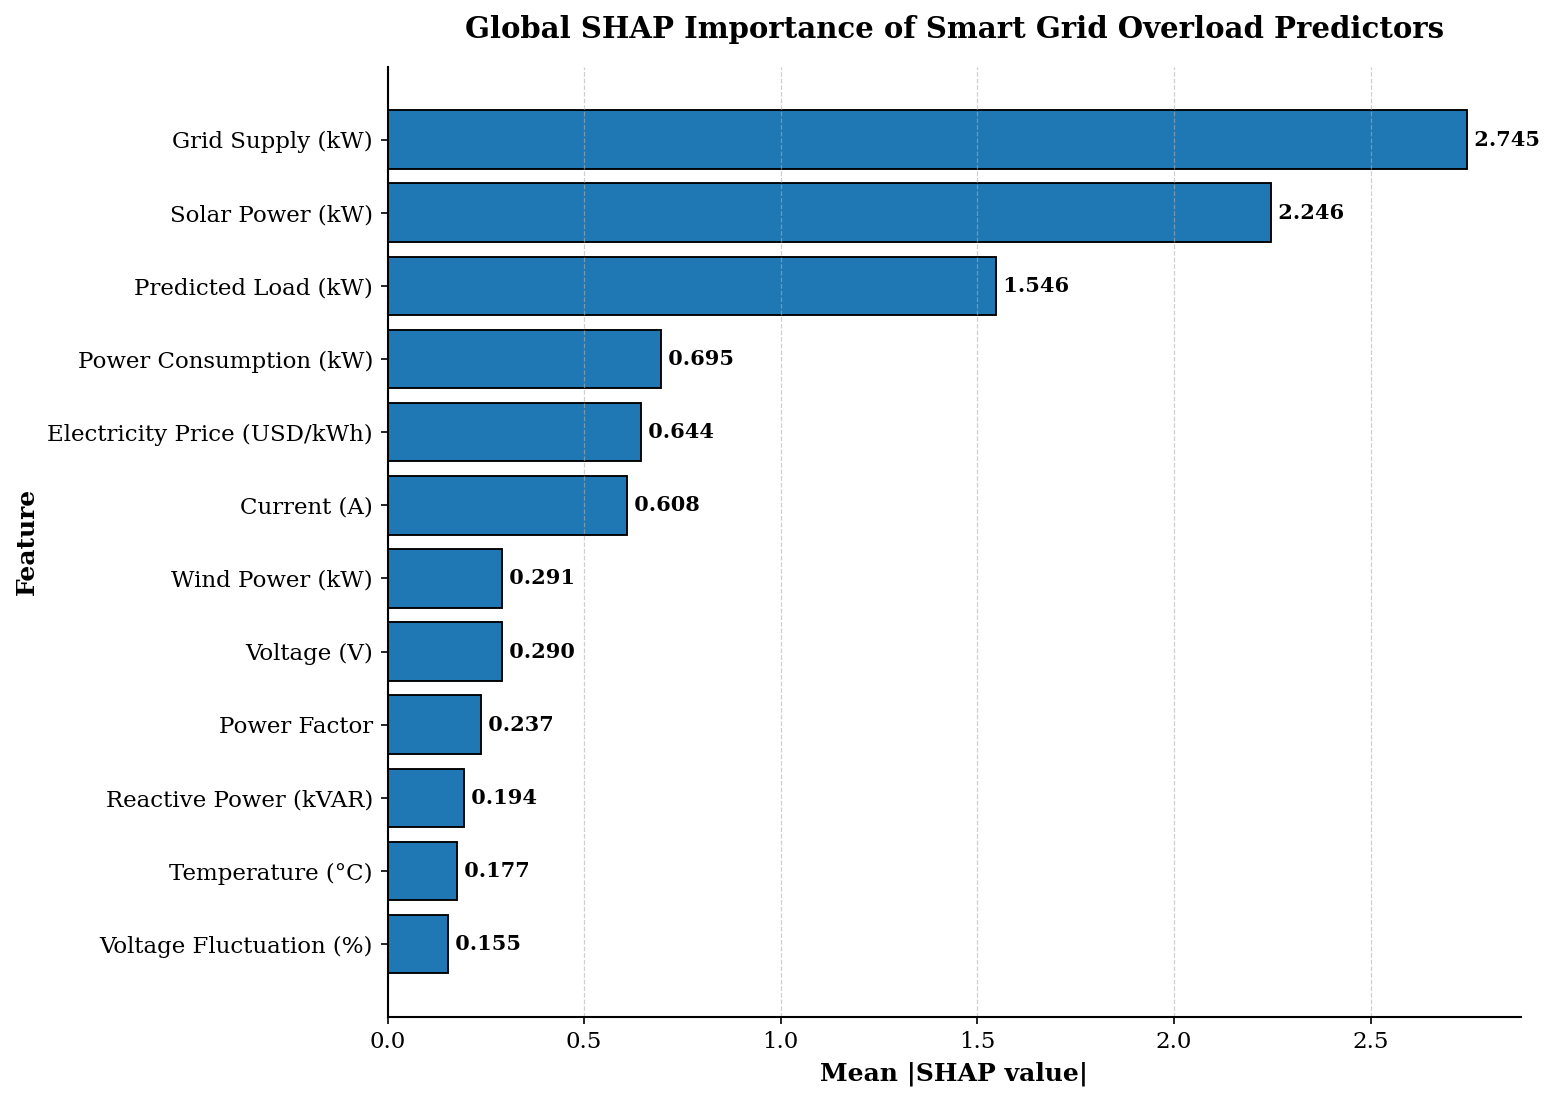

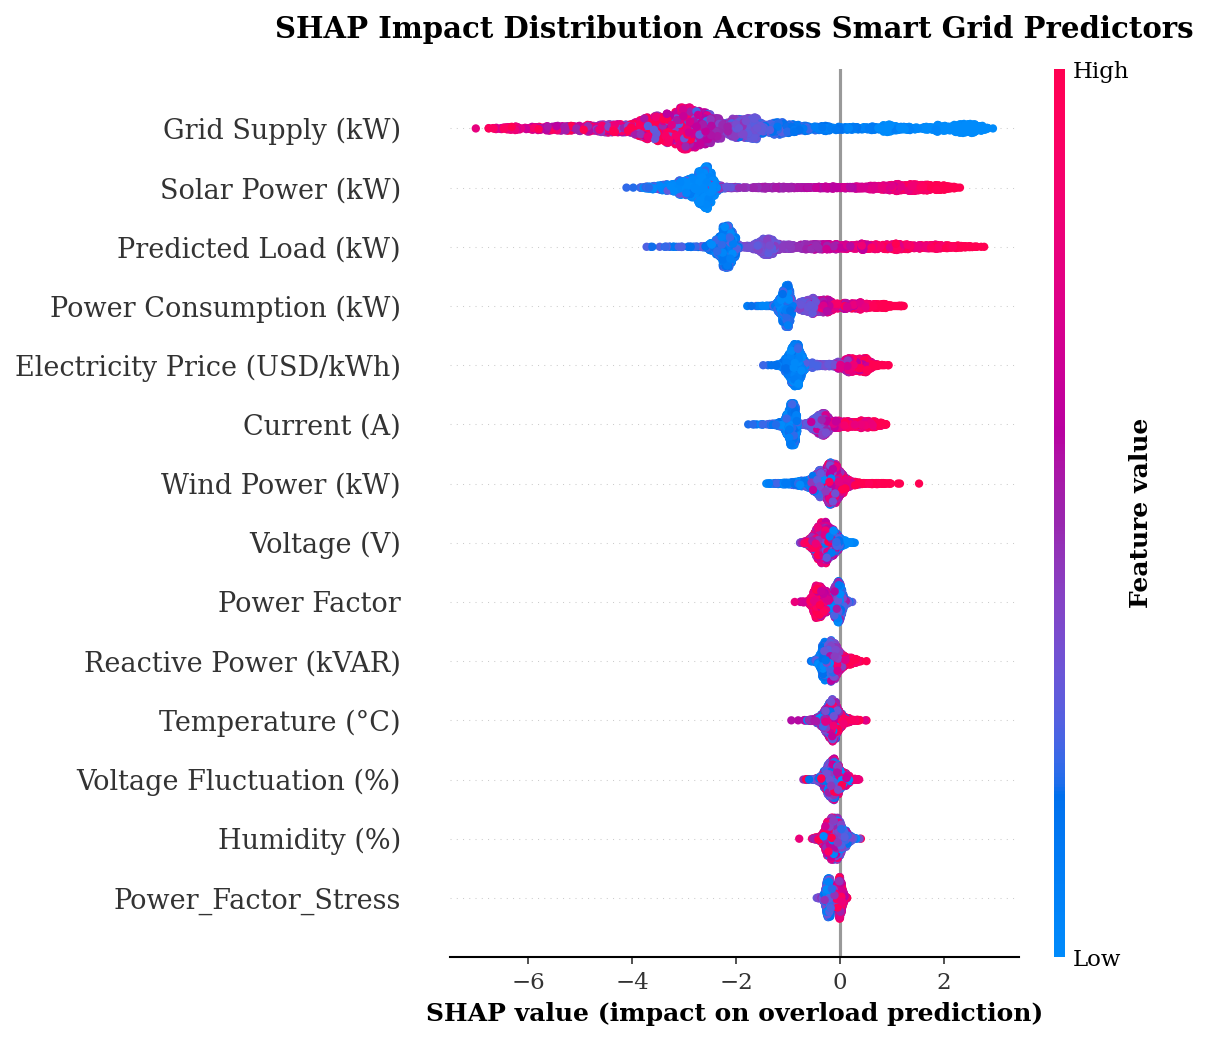


Top SHAP features selected for dependence analysis:
  • Grid Supply (kW)
  • Solar Power (kW)
  • Predicted Load (kW)
  • Power Consumption (kW)


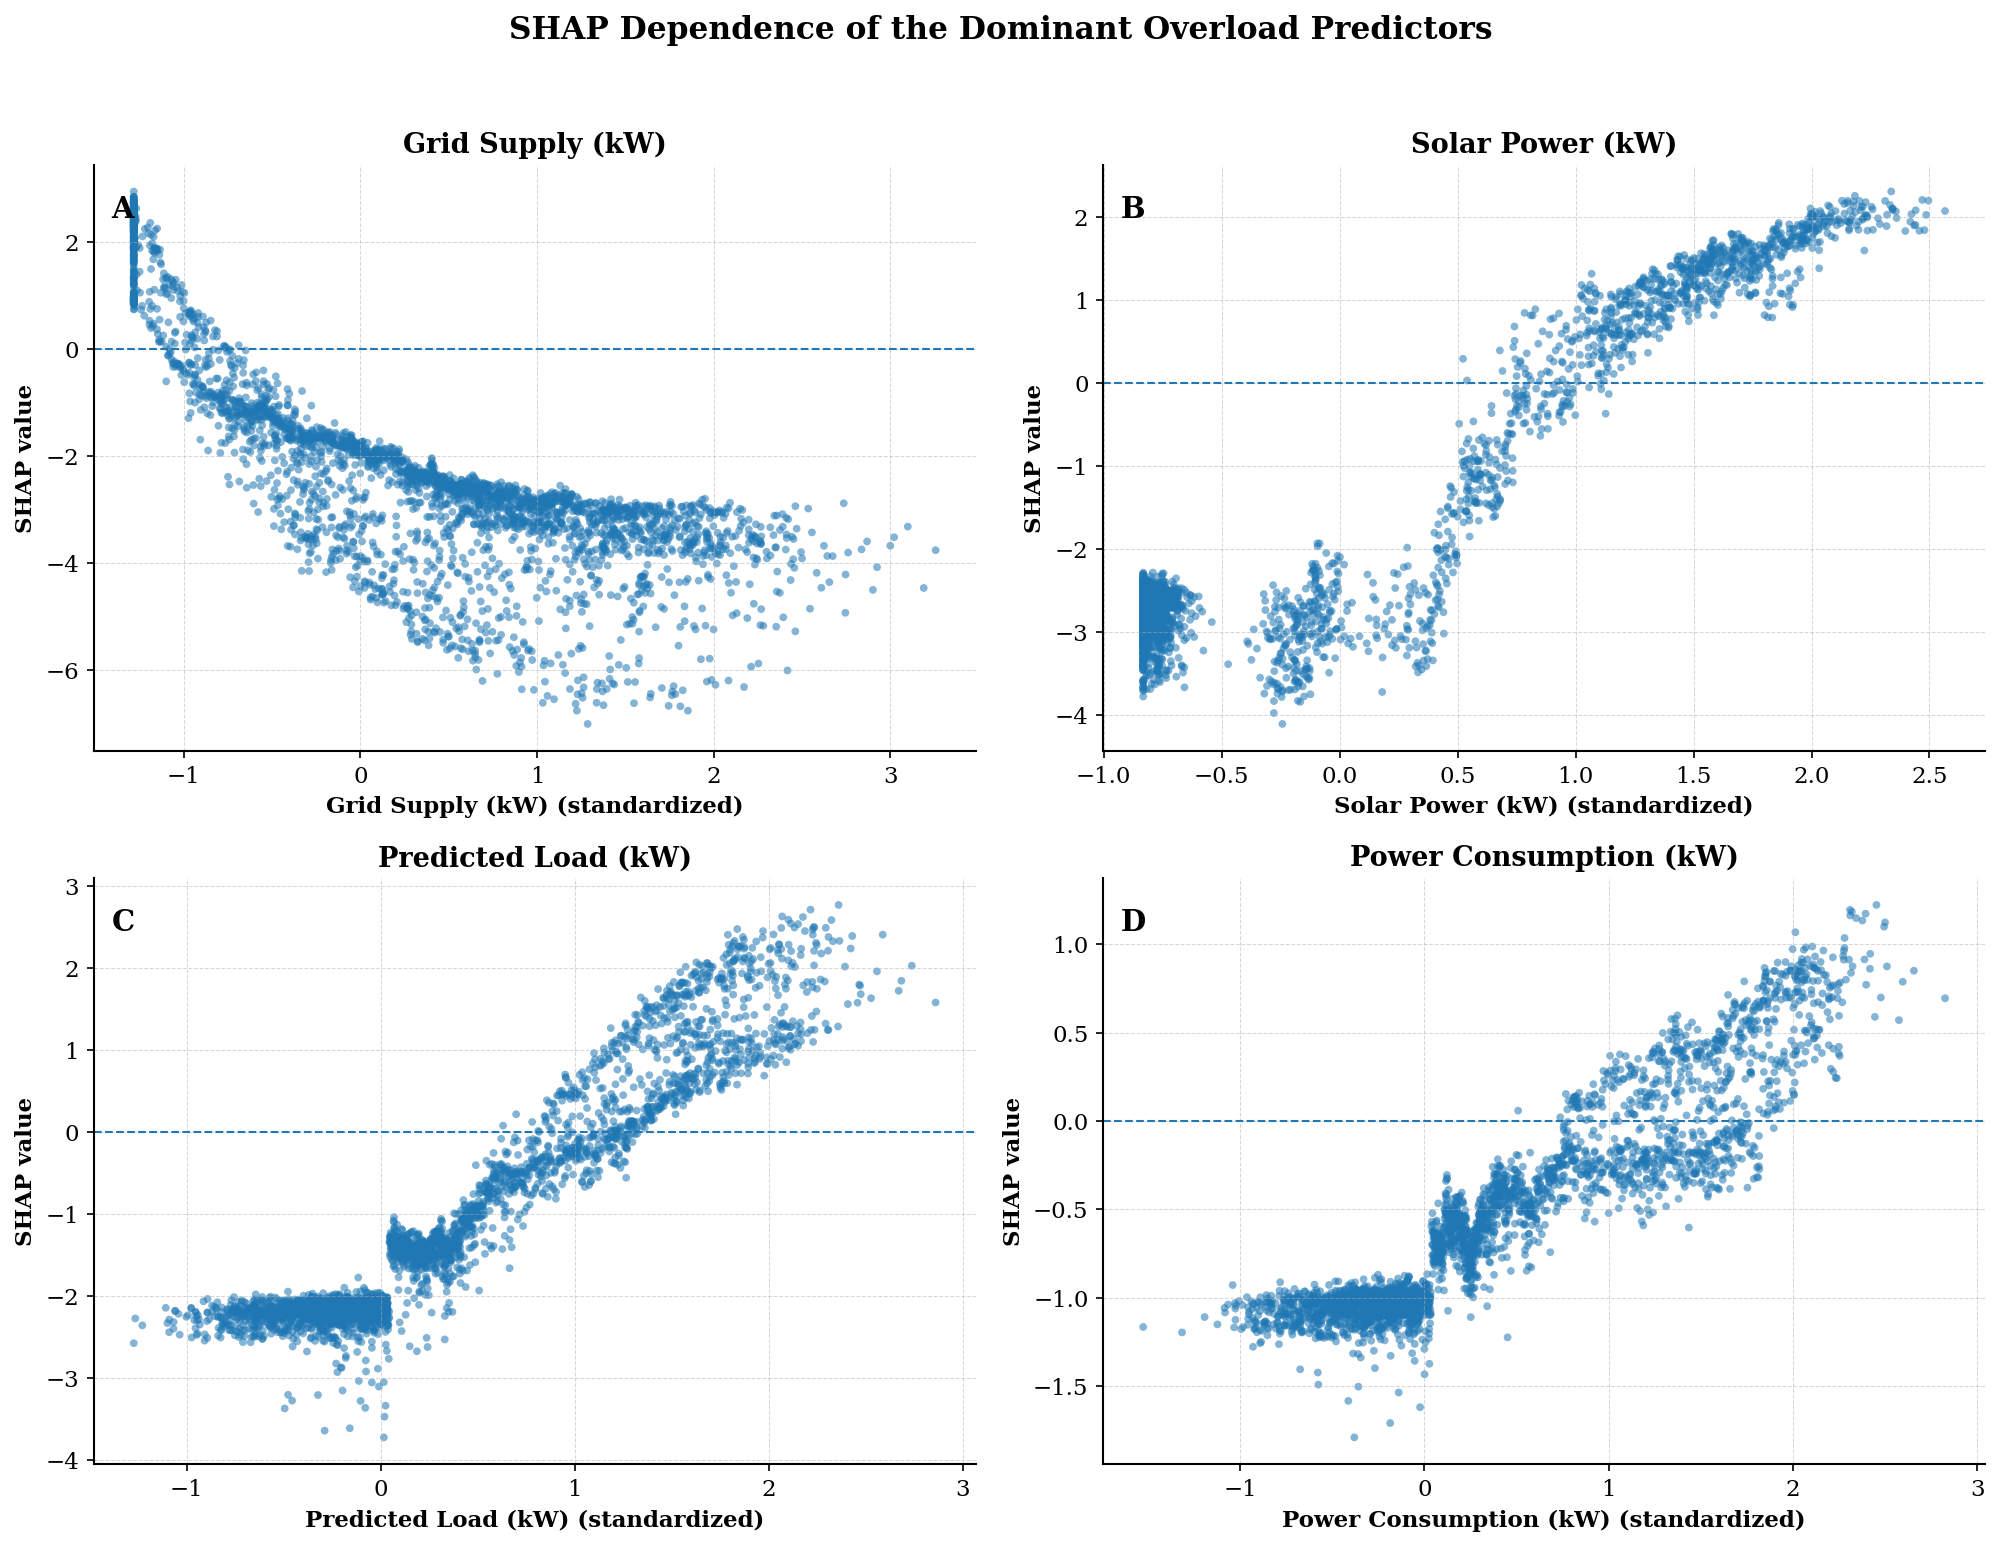


Calculating SHAP interaction values for 700 samples...


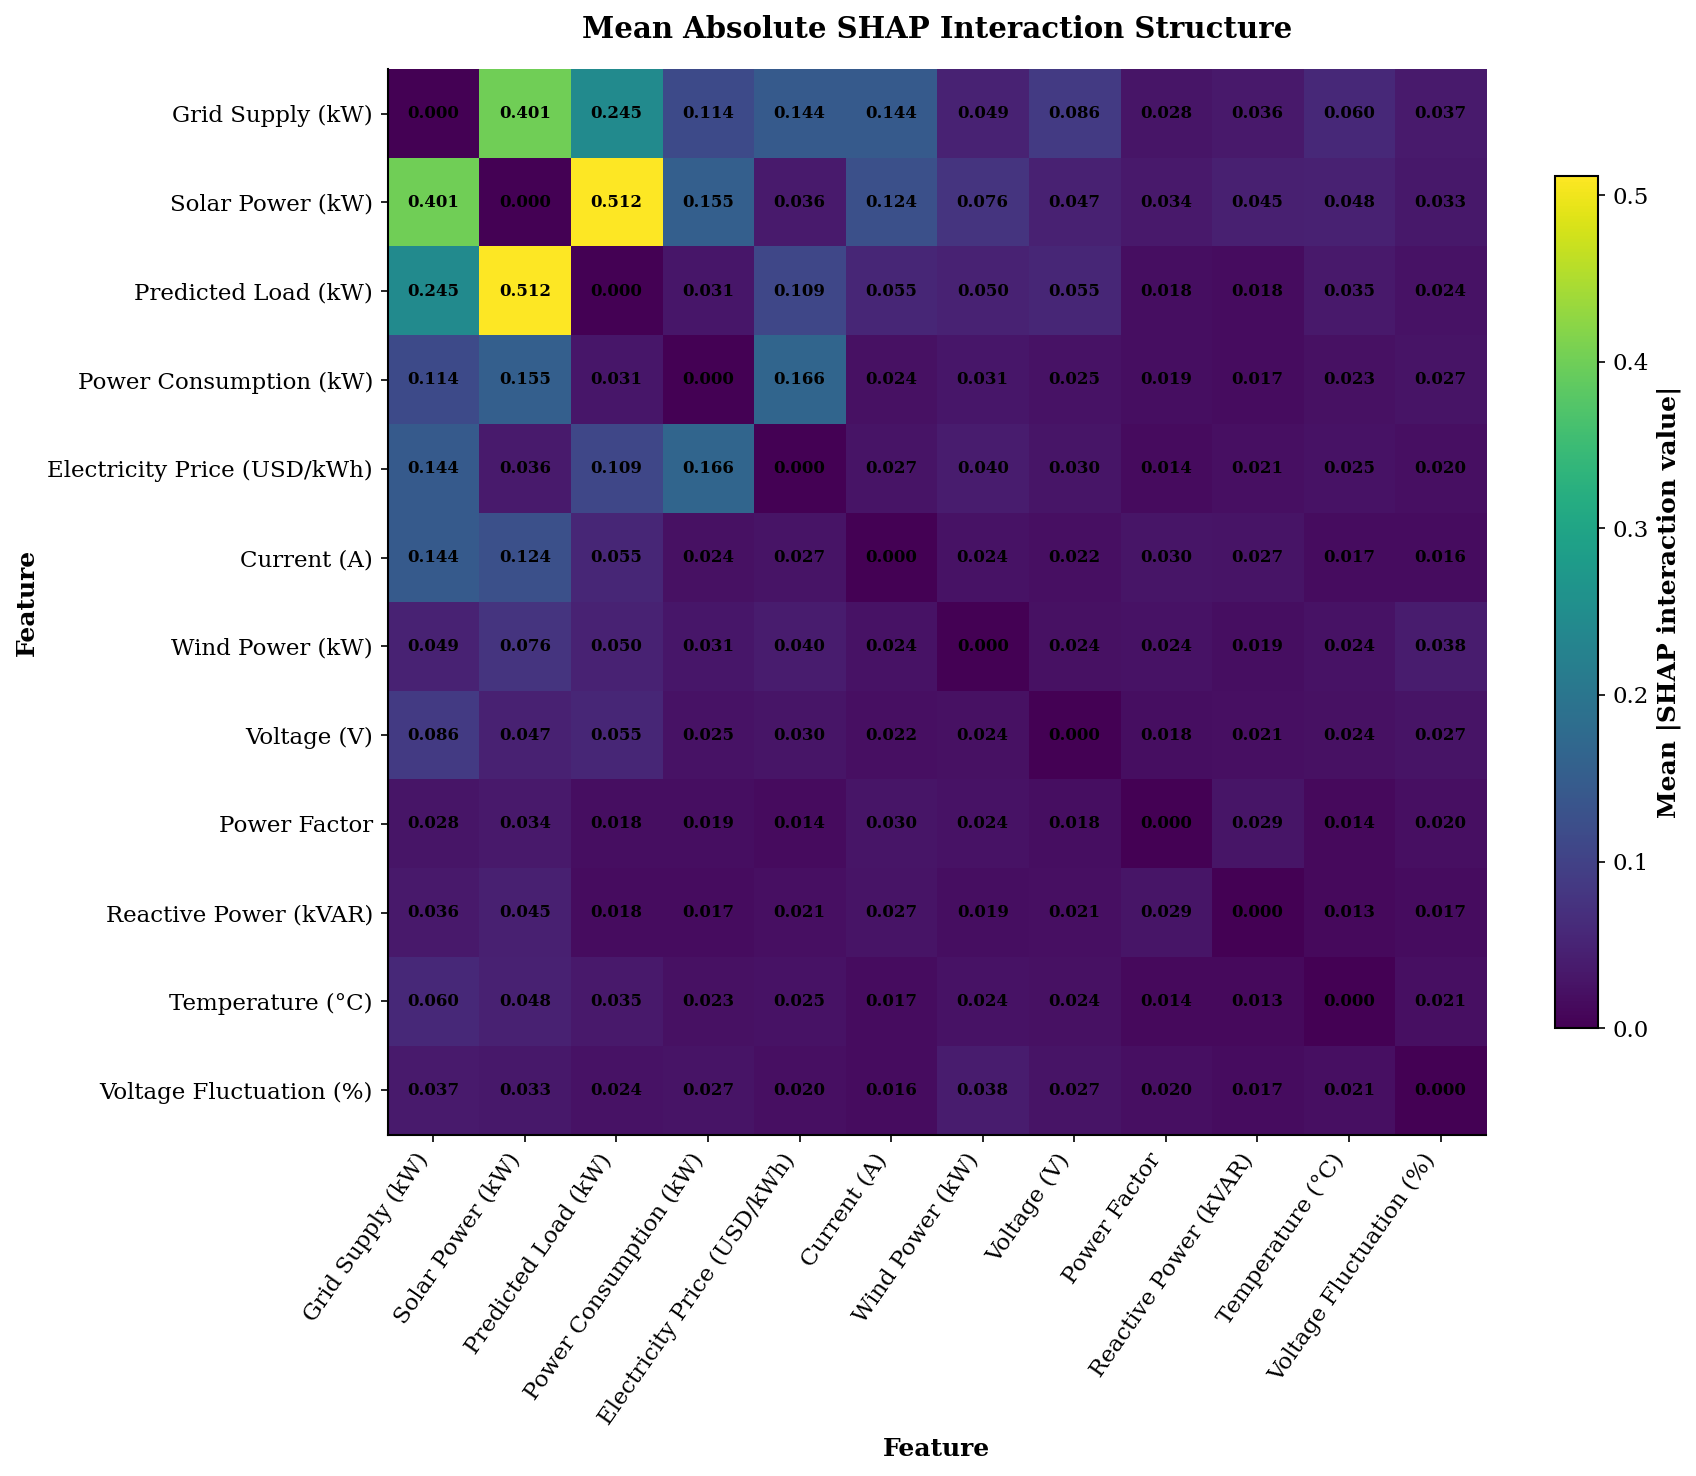

✓ SHAP interaction analysis completed.

SHAP FEATURE-DIRECTION SUMMARY
                    Feature  Mean_SHAP  Mean_Absolute_SHAP  Positive_SHAP_Percentage  Negative_SHAP_Percentage
           Grid Supply (kW)  -2.295453            2.745345                 13.600000                 86.400000
           Solar Power (kW)  -1.580762            2.245585                 26.666667                 73.333333
        Predicted Load (kW)  -0.968317            1.546044                 25.966667                 74.033333
     Power Consumption (kW)  -0.525304            0.695214                 18.966667                 81.033333
Electricity Price (USD/kWh)  -0.422622            0.644344                 33.633333                 66.366667
                Current (A)  -0.452968            0.607958                 19.700000                 80.300000
            Wind Power (kW)  -0.231482            0.291298                 16.333333                 83.666667
                Voltage (V)  -0.284697   

In [ ]:
# =============================================================================
# STEP 7
# SHAP-BASED EXPLAINABLE AI FOR OVERLOAD CLASSIFICATION
# =============================================================================

from pathlib import Path
from typing import Any, Dict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import shap

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier


# =============================================================================
# CONFIGURATION
# =============================================================================

RANDOM_STATE = 42

OUTPUT_DIR = Path(
    "/content/smart_grid_outputs"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

N_SHAP_SAMPLES = 3000
N_DEPENDENCE_FEATURES = 4
N_INTERACTION_FEATURES = 12

TARGET = "Overload Condition"


# =============================================================================
# IEEE FIGURE STYLE
# =============================================================================

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": [
        "Times New Roman",
        "DejaVu Serif",
    ],
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "axes.labelweight": "bold",
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "axes.linewidth": 1.0,
    "savefig.dpi": 300,
    "figure.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


# =============================================================================
# LOAD PREPROCESSED DATA
# =============================================================================

X_train = pd.DataFrame(
    np.load(
        OUTPUT_DIR /
        "X_train_scaled.npy"
    )
)

X_validation = pd.DataFrame(
    np.load(
        OUTPUT_DIR /
        "X_validation_scaled.npy"
    )
)

X_test = pd.DataFrame(
    np.load(
        OUTPUT_DIR /
        "X_test_scaled.npy"
    )
)

y_train = np.load(
    OUTPUT_DIR /
    "y_train.npy"
).astype(int)

y_validation = np.load(
    OUTPUT_DIR /
    "y_validation.npy"
).astype(int)

y_test = np.load(
    OUTPUT_DIR /
    "y_test.npy"
).astype(int)


# =============================================================================
# FEATURE NAMES
# =============================================================================

feature_information = pd.read_csv(
    OUTPUT_DIR /
    "model_feature_information.csv"
)

feature_names = (
    feature_information[
        "Feature"
    ]
    .tolist()
)

X_train.columns = feature_names
X_validation.columns = feature_names
X_test.columns = feature_names


# =============================================================================
# COMBINE TRAINING + VALIDATION
# =============================================================================

X_fit = pd.concat(
    [
        X_train,
        X_validation,
    ],
    axis=0,
)

y_fit = np.concatenate(
    [
        y_train,
        y_validation,
    ]
)


# =============================================================================
# IDENTIFY SELECTED MODEL
# =============================================================================

optimized_validation = pd.read_csv(
    OUTPUT_DIR /
    "optimized_validation_results.csv"
)

optimized_validation = (
    optimized_validation
    .sort_values(
        "F1",
        ascending=False,
    )
    .reset_index(drop=True)
)

best_model_name = (
    optimized_validation
    .iloc[0]["Model"]
)


print("=" * 80)
print("STEP 7 — SHAP EXPLAINABLE AI")
print("=" * 80)

print(
    f"Selected model: "
    f"{best_model_name}"
)

print(
    f"X_fit shape: "
    f"{X_fit.shape}"
)

print(
    f"X_test shape: "
    f"{X_test.shape}"
)


# =============================================================================
# RECOVER BEST HYPERPARAMETERS
# =============================================================================

best_parameters_df = pd.read_csv(
    OUTPUT_DIR /
    "best_model_parameters.csv"
)

best_parameters: Dict[str, Any] = {}


for _, row in best_parameters_df.iterrows():

    parameter = str(
        row["Parameter"]
    ).strip()

    value = row["Value"]

    # -------------------------------------------------------------------------
    # Skip missing values
    # -------------------------------------------------------------------------

    if pd.isna(value):
        continue

    # -------------------------------------------------------------------------
    # Convert serialized strings
    # -------------------------------------------------------------------------

    if isinstance(value, str):

        text = value.strip()

        # Skip invalid serialized values
        if text.lower() in {
            "nan",
            "none",
            "null",
        }:
            continue

        # Boolean values
        elif text.lower() == "true":

            value = True

        elif text.lower() == "false":

            value = False

        # Numeric values
        else:

            try:

                numeric_value = float(text)

                if np.isnan(
                    numeric_value
                ):
                    continue

                if numeric_value.is_integer():

                    value = int(
                        numeric_value
                    )

                else:

                    value = numeric_value

            except ValueError:

                value = text

    # -------------------------------------------------------------------------
    # Skip numerical NaN
    # -------------------------------------------------------------------------

    if (
        isinstance(value, float)
        and np.isnan(value)
    ):
        continue

    best_parameters[
        parameter
    ] = value


# =============================================================================
# SANITIZE TREE-MODEL PARAMETERS
# =============================================================================

if best_model_name == "XGBoost":

    # Remove potentially corrupted
    # serialized parameters.
    best_parameters.pop(
        "verbosity",
        None
    )

    best_parameters.pop(
        "eval_metric",
        None
    )

    best_parameters.pop(
        "objective",
        None
    )

    # Force valid XGBoost values.
    best_parameters[
        "verbosity"
    ] = 0

    best_parameters[
        "eval_metric"
    ] = "logloss"

    best_parameters[
        "objective"
    ] = "binary:logistic"


# =============================================================================
# DISPLAY RECOVERED PARAMETERS
# =============================================================================

print("\nRecovered model parameters:")

for parameter, value in (
    best_parameters.items()
):

    print(
        f"  {parameter}: "
        f"{value!r}"
    )


# =============================================================================
# FIT FINAL TREE MODEL
# =============================================================================

print(
    "\nCreating final tree model..."
)


if best_model_name == "XGBoost":

    final_model = XGBClassifier(
        **best_parameters
    )


elif best_model_name == "LightGBM":

    final_model = LGBMClassifier(
        **best_parameters
    )


elif best_model_name == "CatBoost":

    final_model = CatBoostClassifier(
        **best_parameters
    )


else:

    raise ValueError(
        "SHAP implementation in this "
        "step expects a tree-based "
        "optimized model."
    )


# =============================================================================
# FIT FINAL MODEL
# =============================================================================

print(
    "\nFitting final model for "
    "SHAP analysis..."
)

final_model.fit(
    X_fit,
    y_fit,
)

print(
    "✓ Model fitted."
)


# =============================================================================
# VERIFY MODEL
# =============================================================================

print(
    "\nModel verification:"
)

print(
    f"Model type: "
    f"{type(final_model).__name__}"
)

print(
    f"Number of features: "
    f"{len(feature_names)}"
)


# =============================================================================
# SHAP DATASET
# =============================================================================

if len(X_test) > N_SHAP_SAMPLES:

    shap_sample = (
        X_test
        .sample(
            n=N_SHAP_SAMPLES,
            random_state=RANDOM_STATE,
        )
        .sort_index()
    )

else:

    shap_sample = X_test.copy()


print(
    f"\nSHAP explanation samples: "
    f"{len(shap_sample):,}"
)


# =============================================================================
# CREATE TREE EXPLAINER
# =============================================================================

print(
    "\nCreating TreeExplainer..."
)

explainer = shap.TreeExplainer(
    final_model
)

print(
    "✓ SHAP TreeExplainer created."
)


# =============================================================================
# CALCULATE SHAP VALUES
# =============================================================================

print(
    "\nCalculating SHAP values..."
)

shap_output = explainer(
    shap_sample
)

shap_values = (
    shap_output.values
)


# =============================================================================
# HANDLE SHAP OUTPUT FORMAT
# =============================================================================

if shap_values.ndim == 3:

    # samples × features × classes
    shap_values = (
        shap_values[:, :, 1]
    )


print(
    f"SHAP matrix shape: "
    f"{shap_values.shape}"
)


if shap_values.shape != (
    len(shap_sample),
    len(feature_names),
):

    raise ValueError(
        "SHAP matrix shape does not "
        "match the feature matrix. "
        f"SHAP shape = "
        f"{shap_values.shape}, "
        f"expected = "
        f"{(len(shap_sample), len(feature_names))}"
    )


# =============================================================================
# GLOBAL SHAP IMPORTANCE
# =============================================================================

mean_abs_shap = (
    np.abs(shap_values)
    .mean(axis=0)
)

global_importance = pd.DataFrame(
    {
        "Feature": feature_names,
        "Mean_Absolute_SHAP": (
            mean_abs_shap
        ),
    }
)

global_importance = (
    global_importance
    .sort_values(
        "Mean_Absolute_SHAP",
        ascending=False,
    )
    .reset_index(drop=True)
)

total_importance = (
    global_importance[
        "Mean_Absolute_SHAP"
    ].sum()
)

if total_importance > 0:

    global_importance[
        "Importance_%"
    ] = (
        global_importance[
            "Mean_Absolute_SHAP"
        ]
        / total_importance
        * 100
    )

else:

    global_importance[
        "Importance_%"
    ] = 0.0


# =============================================================================
# SAVE SHAP GLOBAL IMPORTANCE
# =============================================================================

global_importance.to_csv(
    OUTPUT_DIR /
    "SHAP_Global_Feature_Importance.csv",
    index=False,
)


# =============================================================================
# PRINT TOP FEATURES
# =============================================================================

print(
    "\n" + "=" * 80
)

print(
    "GLOBAL SHAP FEATURE IMPORTANCE"
)

print(
    "=" * 80
)

print(
    global_importance
    .head(15)
    .to_string(
        index=False,
        float_format=lambda x:
        f"{x:.6f}",
    )
)


# =============================================================================
# FIGURE 11 — GLOBAL SHAP IMPORTANCE
# =============================================================================

top_n = min(
    12,
    len(global_importance),
)

importance_plot = (
    global_importance
    .head(top_n)
    .sort_values(
        "Mean_Absolute_SHAP",
        ascending=True,
    )
)

fig, ax = plt.subplots(
    figsize=(10.5, 7.5)
)

bars = ax.barh(
    importance_plot["Feature"],
    importance_plot[
        "Mean_Absolute_SHAP"
    ],
    edgecolor="black",
    linewidth=0.9,
)

ax.set_title(
    (
        "Global SHAP Importance of Smart "
        "Grid Overload Predictors"
    ),
    pad=14,
)

ax.set_xlabel(
    "Mean |SHAP value|"
)

ax.set_ylabel(
    "Feature"
)

for bar, value in zip(
    bars,
    importance_plot[
        "Mean_Absolute_SHAP"
    ],
):

    ax.text(
        bar.get_width(),
        (
            bar.get_y()
            + bar.get_height() / 2
        ),
        f" {value:.3f}",
        va="center",
        fontsize=10,
        fontweight="bold",
    )

ax.grid(
    axis="x",
    linestyle="--",
    linewidth=0.6,
    alpha=0.6,
)

figure_11_png = (
    OUTPUT_DIR /
    "Figure_11_SHAP_Global_Importance.png"
)

figure_11_pdf = (
    OUTPUT_DIR /
    "Figure_11_SHAP_Global_Importance.pdf"
)

fig.tight_layout()

fig.savefig(
    figure_11_png,
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    figure_11_pdf,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# =============================================================================
# FIGURE 12 — SHAP BEESWARM
# =============================================================================

plt.figure(
    figsize=(11.5, 8.5)
)

shap.summary_plot(
    shap_values,
    shap_sample,
    feature_names=feature_names,
    max_display=15,
    show=False,
)

plt.title(
    "SHAP Impact Distribution Across Smart Grid Predictors",
    fontsize=14,
    fontweight="bold",
    pad=15,
)

plt.xlabel(
    "SHAP value "
    "(impact on overload prediction)",
    fontsize=12,
    fontweight="bold",
)

plt.tight_layout()

figure_12_png = (
    OUTPUT_DIR /
    "Figure_12_SHAP_Beeswarm.png"
)

figure_12_pdf = (
    OUTPUT_DIR /
    "Figure_12_SHAP_Beeswarm.pdf"
)

plt.savefig(
    figure_12_png,
    dpi=300,
    bbox_inches="tight",
)

plt.savefig(
    figure_12_pdf,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# =============================================================================
# DETERMINE TOP FEATURES
# =============================================================================

top_features = (
    global_importance[
        "Feature"
    ]
    .head(N_DEPENDENCE_FEATURES)
    .tolist()
)

print(
    "\nTop SHAP features selected "
    "for dependence analysis:"
)

for feature in top_features:

    print(
        f"  • {feature}"
    )


# =============================================================================
# FIGURE 13 — SHAP DEPENDENCE ANALYSIS
# =============================================================================

# =============================================================================
# SHAP DEPENDENCE OF THE DOMINANT OVERLOAD PREDICTORS
# =============================================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(13.5, 10.5),
)

axes = axes.ravel()

# Panel labels
panel_labels = [
    "A",
    "B",
    "C",
    "D",
]

for axis, feature, panel_label in zip(
    axes,
    top_features,
    panel_labels,
):

    # -------------------------------------------------------------------------
    # Feature index
    # -------------------------------------------------------------------------

    feature_index = (
        feature_names.index(
            feature
        )
    )

    # -------------------------------------------------------------------------
    # Feature values
    # -------------------------------------------------------------------------

    feature_values = (
        shap_sample[
            feature
        ].to_numpy()
    )

    # -------------------------------------------------------------------------
    # SHAP values
    # -------------------------------------------------------------------------

    feature_shap = (
        shap_values[
            :,
            feature_index
        ]
    )

    # -------------------------------------------------------------------------
    # SHAP scatter
    # -------------------------------------------------------------------------

    axis.scatter(
        feature_values,
        feature_shap,
        s=14,
        alpha=0.55,
        edgecolors="none",
    )

    # -------------------------------------------------------------------------
    # Zero reference line
    # -------------------------------------------------------------------------

    axis.axhline(
        0,
        linestyle="--",
        linewidth=1.0,
    )

    # -------------------------------------------------------------------------
    # Feature title
    # -------------------------------------------------------------------------

    axis.set_title(
        feature,
        fontsize=13,
        fontweight="bold",
    )

    # -------------------------------------------------------------------------
    # PANEL LABEL — A, B, C, D
    # -------------------------------------------------------------------------

    axis.text(
        0.02,
        0.95,
        panel_label,
        transform=axis.transAxes,
        fontsize=14,
        fontweight="bold",
        va="top",
        ha="left",
    )

    # -------------------------------------------------------------------------
    # X-axis label
    # -------------------------------------------------------------------------

    axis.set_xlabel(
        f"{feature} (standardized)",
        fontsize=11,
        fontweight="bold",
    )

    # -------------------------------------------------------------------------
    # Y-axis label
    # -------------------------------------------------------------------------

    axis.set_ylabel(
        "SHAP value",
        fontsize=11,
        fontweight="bold",
    )

    # -------------------------------------------------------------------------
    # Grid
    # -------------------------------------------------------------------------

    axis.grid(
        linestyle="--",
        linewidth=0.5,
        alpha=0.5,
    )


# =============================================================================
# OVERALL FIGURE TITLE
# =============================================================================

fig.suptitle(
    "SHAP Dependence of the Dominant "
    "Overload Predictors",
    fontsize=15,
    fontweight="bold",
)


# =============================================================================
# LAYOUT
# =============================================================================

fig.tight_layout(
    rect=[
        0,
        0,
        1,
        0.96,
    ]
)


# =============================================================================
# DISPLAY
# =============================================================================

plt.show()

figure_13_png = (
    OUTPUT_DIR /
    "Figure_13_SHAP_Dependence_Analysis.png"
)

figure_13_pdf = (
    OUTPUT_DIR /
    "Figure_13_SHAP_Dependence_Analysis.pdf"
)

fig.savefig(
    figure_13_png,
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    figure_13_pdf,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# =============================================================================
# SHAP INTERACTION VALUES
# =============================================================================

interaction_sample_size = min(
    700,
    len(shap_sample),
)

interaction_sample = (
    shap_sample
    .sample(
        n=interaction_sample_size,
        random_state=RANDOM_STATE,
    )
    .sort_index()
)

print(
    "\nCalculating SHAP interaction "
    "values for "
    f"{len(interaction_sample):,} "
    "samples..."
)


try:

    interaction_values = (
        explainer
        .shap_interaction_values(
            interaction_sample
        )
    )

    # Handle list output from
    # some SHAP versions.
    if isinstance(
        interaction_values,
        list,
    ):

        interaction_values = (
            interaction_values[1]
        )

    # Handle possible class dimension.
    if interaction_values.ndim == 4:

        interaction_values = (
            interaction_values[
                :, :, :, 1
            ]
        )

    mean_abs_interactions = (
        np.abs(
            interaction_values
        )
        .mean(axis=0)
    )

    # Remove diagonal self-interactions.
    np.fill_diagonal(
        mean_abs_interactions,
        0,
    )


    # -------------------------------------------------------------------------
    # Select interaction features
    # -------------------------------------------------------------------------

    interaction_features = (
        global_importance[
            "Feature"
        ]
        .head(
            min(
                N_INTERACTION_FEATURES,
                len(global_importance),
            )
        )
        .tolist()
    )

    interaction_indices = [
        feature_names.index(
            feature
        )
        for feature in interaction_features
    ]


    # -------------------------------------------------------------------------
    # Interaction matrix
    # -------------------------------------------------------------------------

    interaction_matrix = (
        mean_abs_interactions[
            np.ix_(
                interaction_indices,
                interaction_indices,
            )
        ]
    )

    interaction_matrix_df = pd.DataFrame(
        interaction_matrix,
        index=interaction_features,
        columns=interaction_features,
    )


    # -------------------------------------------------------------------------
    # Save interaction matrix
    # -------------------------------------------------------------------------

    interaction_matrix_df.to_csv(
        OUTPUT_DIR /
        "SHAP_Interaction_Matrix.csv"
    )


    # =============================================================================
    # FIGURE 14 — SHAP INTERACTION HEATMAP
    # =============================================================================

    fig, ax = plt.subplots(
        figsize=(12, 10)
    )

    image = ax.imshow(
        interaction_matrix,
        aspect="auto",
        interpolation="nearest",
    )

    ax.set_title(
        "Mean Absolute SHAP "
        "Interaction Structure",
        pad=15,
    )

    ax.set_xticks(
        np.arange(
            len(interaction_features)
        )
    )

    ax.set_yticks(
        np.arange(
            len(interaction_features)
        )
    )

    ax.set_xticklabels(
        interaction_features,
        rotation=55,
        ha="right",
    )

    ax.set_yticklabels(
        interaction_features,
    )


    for i in range(
        len(interaction_features)
    ):

        for j in range(
            len(interaction_features)
        ):

            value = (
                interaction_matrix[
                    i,
                    j
                ]
            )

            ax.text(
                j,
                i,
                f"{value:.3f}",
                ha="center",
                va="center",
                fontsize=8,
                fontweight="bold",
            )


    colorbar = fig.colorbar(
        image,
        ax=ax,
        shrink=0.80,
    )

    colorbar.set_label(
        "Mean |SHAP interaction value|",
        fontweight="bold",
    )

    ax.set_xlabel(
        "Feature",
        fontweight="bold",
    )

    ax.set_ylabel(
        "Feature",
        fontweight="bold",
    )

    fig.tight_layout()

    figure_14_png = (
        OUTPUT_DIR /
        "Figure_14_SHAP_Interaction_Heatmap.png"
    )

    figure_14_pdf = (
        OUTPUT_DIR /
        "Figure_14_SHAP_Interaction_Heatmap.pdf"
    )

    fig.savefig(
        figure_14_png,
        dpi=300,
        bbox_inches="tight",
    )

    fig.savefig(
        figure_14_pdf,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    print(
        "✓ SHAP interaction analysis completed."
    )


except Exception as error:

    print(
        "\n⚠ SHAP interaction calculation "
        "could not be completed."
    )

    print(
        f"Reason: {error}"
    )


# =============================================================================
# SHAP FEATURE-DIRECTION SUMMARY
# =============================================================================

direction_rows = []


for index, feature in enumerate(
    feature_names
):

    values = (
        shap_values[
            :,
            index
        ]
    )

    direction_rows.append(
        {
            "Feature": feature,

            "Mean_SHAP": np.mean(
                values
            ),

            "Mean_Absolute_SHAP": np.mean(
                np.abs(values)
            ),

            "Positive_SHAP_Percentage": (
                np.mean(
                    values > 0
                ) * 100
            ),

            "Negative_SHAP_Percentage": (
                np.mean(
                    values < 0
                ) * 100
            ),
        }
    )


direction_df = pd.DataFrame(
    direction_rows
)

direction_df = (
    direction_df
    .sort_values(
        "Mean_Absolute_SHAP",
        ascending=False,
    )
    .reset_index(drop=True)
)


# =============================================================================
# SAVE DIRECTION SUMMARY
# =============================================================================

direction_df.to_csv(
    OUTPUT_DIR /
    "SHAP_Feature_Direction_Summary.csv",
    index=False,
)


# =============================================================================
# PRINT INTERPRETATION TABLE
# =============================================================================

print(
    "\n" + "=" * 80
)

print(
    "SHAP FEATURE-DIRECTION SUMMARY"
)

print(
    "=" * 80
)

print(
    direction_df
    .head(15)
    .to_string(
        index=False,
        float_format=lambda x:
        f"{x:.6f}",
    )
)


# =============================================================================
# SAVE SHAP VALUES
# =============================================================================

shap_values_df = pd.DataFrame(
    shap_values,
    columns=feature_names,
    index=shap_sample.index,
)

shap_values_df.to_csv(
    OUTPUT_DIR /
    "SHAP_Values_Test_Sample.csv"
)


# =============================================================================
# SAVE SHAP FEATURE VALUES
# =============================================================================

shap_sample.to_csv(
    OUTPUT_DIR /
    "SHAP_Feature_Values_Test_Sample.csv"
)


# =============================================================================
# FINAL SUMMARY
# =============================================================================

print(
    "\n" + "=" * 80
)

print(
    "STEP 7 COMPLETED"
)

print(
    "=" * 80
)

print(
    f"Final model: "
    f"{best_model_name}"
)

print(
    f"SHAP samples: "
    f"{len(shap_sample):,}"
)

print(
    "\nTop five SHAP predictors:"
)


for rank, feature in enumerate(
    global_importance[
        "Feature"
    ].head(5),
    start=1,
):

    importance_value = (
        global_importance
        .loc[
            global_importance[
                "Feature"
            ] == feature,
            "Mean_Absolute_SHAP",
        ]
        .iloc[0]
    )

    print(
        f"{rank}. {feature}: "
        f"{importance_value:.6f}"
    )


print(
    "\nGenerated figures:"
)

print(
    "✓ Figure 11 — Global SHAP Importance"
)

print(
    "✓ Figure 12 — SHAP Beeswarm"
)

print(
    "✓ Figure 13 — SHAP Dependence Analysis"
)

print(
    "✓ Figure 14 — SHAP Interaction Heatmap"
)


print(
    "\nGenerated CSV files:"
)

print(
    "✓ SHAP_Global_Feature_Importance.csv"
)

print(
    "✓ SHAP_Feature_Direction_Summary.csv"
)

print(
    "✓ SHAP_Values_Test_Sample.csv"
)

print(
    "✓ SHAP_Feature_Values_Test_Sample.csv"
)

print(
    "✓ SHAP_Interaction_Matrix.csv"
)

print(
    "\n✓ Explainable AI analysis completed."
)

In [ ]:
# =============================================================================
# DOWNLOAD ALL CSV + FIGURES
# =============================================================================

from pathlib import Path
import shutil
from google.colab import files

OUTPUT_DIR = Path("/content/smart_grid_outputs")
ZIP_PATH = Path("/content/smart_grid_research_outputs")

# -------------------------------------------------------------------------
# Verify output directory
# -------------------------------------------------------------------------

if not OUTPUT_DIR.exists():
    raise FileNotFoundError(
        f"Output directory not found: {OUTPUT_DIR}"
    )

# -------------------------------------------------------------------------
# Collect generated files
# -------------------------------------------------------------------------

csv_files = sorted(OUTPUT_DIR.glob("*.csv"))
png_files = sorted(OUTPUT_DIR.glob("*.png"))
pdf_files = sorted(OUTPUT_DIR.glob("*.pdf"))

all_files = (
    csv_files
    + png_files
    + pdf_files
)

print("=" * 80)
print("SMART GRID RESEARCH OUTPUT COLLECTION")
print("=" * 80)

print(f"CSV files : {len(csv_files)}")
print(f"PNG files : {len(png_files)}")
print(f"PDF files : {len(pdf_files)}")
print(f"Total     : {len(all_files)}")


# -------------------------------------------------------------------------
# Display files
# -------------------------------------------------------------------------

print("\nCSV FILES")
print("-" * 80)

for file in csv_files:
    print(f"✓ {file.name}")

print("\nFIGURE FILES — PNG")
print("-" * 80)

for file in png_files:
    print(f"✓ {file.name}")

print("\nFIGURE FILES — PDF")
print("-" * 80)

for file in pdf_files:
    print(f"✓ {file.name}")


# -------------------------------------------------------------------------
# Create ZIP archive
# -------------------------------------------------------------------------

zip_file = shutil.make_archive(
    str(ZIP_PATH),
    "zip",
    root_dir=OUTPUT_DIR,
)

print("\n" + "=" * 80)
print("ZIP ARCHIVE CREATED")
print("=" * 80)

print(f"Archive: {zip_file}")


# -------------------------------------------------------------------------
# Download ZIP
# -------------------------------------------------------------------------

files.download(zip_file)

SMART GRID RESEARCH OUTPUT COLLECTION
CSV files : 16
PNG files : 14
PDF files : 14
Total     : 44

CSV FILES
--------------------------------------------------------------------------------
✓ SHAP_Feature_Direction_Summary.csv
✓ SHAP_Feature_Values_Test_Sample.csv
✓ SHAP_Global_Feature_Importance.csv
✓ SHAP_Interaction_Matrix.csv
✓ SHAP_Values_Test_Sample.csv
✓ best_model_parameters.csv
✓ final_independent_test_results.csv
✓ final_test_predictions.csv
✓ hyperparameter_optimization_results.csv
✓ model_feature_information.csv
✓ optimized_validation_results.csv
✓ primary_model_features.csv
✓ smart_grid_engineered_dataset.csv
✓ temporal_split_metadata.csv
✓ test_threshold_analysis.csv
✓ validation_model_comparison.csv

FIGURE FILES — PNG
--------------------------------------------------------------------------------
✓ Figure_10_Threshold_Sensitivity.png
✓ Figure_11_SHAP_Global_Importance.png
✓ Figure_12_SHAP_Beeswarm.png
✓ Figure_13_SHAP_Dependence_Analysis.png
✓ Figure_14_SHAP_Interactio

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>